# Распределение диагностических работ ИТЦ

### ООО «Газпром ПХГ» — модель оптимального распределения

<a id='задачи'></a>

<b><h2>Навигация:</h2></b>

[1. Загрузка данных (Т1, Т2, Т3, Т5)](#1-знакомство)
   
[2. Построение матриц допустимости (a_ij, b_iq)](#2-матрицы-допустимости)
   
[3. Анализ нагрузки](#3-анализ-нагрузки)

[4. Базовая модель](#4-баз-модель)

[5. Календарная модель](#5-календарная-модель)

[6. Анализ результатов и экономический эффект](#7-анализ-результатов)

0. Настройки и параметры модели
1. Загрузка исходных таблиц
2. Подготовка справочников
3. Проверка фактических данных
4. Модель 1: сезонная оптимизация с агрегированными командировками
5. Результаты модели 1
6. Запасная календаризация решения модели 1
7. Настоящая календарная кандидатная модель CP-SAT
8. Экспорт результатов


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

<a id='1-знакомство'></a>
<div style="background-color: pink; padding: 15px; border-radius: 5px;">
<h1 style="color: black;">1. Загрузка данных (Т1, Т2, Т3, Т5)</h1>
</div>

[Вернуться к содержанию](#задачи)

In [2]:
FILE = Path('каркасы таблиц данных.xlsx')
OUT_DIR = Path('prepared_itc')
OUT_DIR.mkdir(exist_ok=True)

WORK_HOURS_PER_DAY = 8

In [3]:
def norm_text(x):
    if pd.isna(x):
        return np.nan
    x = str(x).replace('\n', ' ').replace('\xa0', ' ')
    x = ' '.join(x.split())
    x = x.strip()
    x = x.replace('УМТС и К', 'УМТСиК')
    return x

In [4]:
t1_raw = pd.read_excel(FILE, sheet_name='Т1')
t2_raw = pd.read_excel(FILE, sheet_name='Т2')
t3_raw = pd.read_excel(FILE, sheet_name='Т3')
t5_raw = pd.read_excel(FILE, sheet_name='Т5')

In [5]:
print(f'Т1 — типы работ: {t1_raw.shape[0]} строка, {t1_raw.shape[1]} столбцов')
print(f'Т2 — подразделения: {t2_raw.shape[0]} строк')
print(f'Т3 — командировки: {t3_raw.shape[0]} строки')
print(f'Т5 — план работ: {t5_raw.shape[0]} строк')

Т1 — типы работ: 51 строка, 7 столбцов
Т2 — подразделения: 7 строк
Т3 — командировки: 22 строки
Т5 — план работ: 1290 строк


## Очистка и подготовка данных

### Подготовка Т1

In [6]:
# 1. Убираем итоговые строки и строки без кода работы
t1 = t1_raw.loc[t1_raw['Код'].notna() & (t1_raw['Код'] != '')].copy()
t1

,Работа,Код,Сколько раз встречается в плане,"Суммарная трудоемкость, чел-час","Трудоемкость, чел-час",Сезонная доступность,Нужная аттестация
0,Операции по периодическому техническому диагно...,101.0,38,932.40,24.536842,нельзя зимой,СЦР ЛООиТКС
1,Операции по периодическому техническому диагно...,102.0,29,815.30,28.113793,нельзя зимой,СЦР ЛООиТКС
2,Операции по периодическому техническому диагно...,103.0,16,493.10,30.818750,нельзя зимой,СЦР ЛООиТКС
3,Операции по периодическому техническому диагно...,104.0,25,451.40,18.056000,да,СЦР ЛООиТКС
4,Операции по периодическому техническому диагно...,105.0,18,575.50,31.972222,да,СЦР ЛООиТКС
5,Операции по параметрическому диагностированию...,106.0,15,503.00,33.533333,нельзя зимой,СЦР ЛООиТКС
6,Операции по периодическому техническому диагно...,107.0,27,938.90,34.774074,нельзя зимой,СЦР ЛООиТКС
7,Операции по периодическому техническому диагно...,108.0,10,283.20,28.320000,нельзя зимой,СЦР ЛООиТКС
8,Операции по периодическому техническому диагно...,109.0,8,230.90,28.862500,нельзя зимой,СЦР ЛООиТКС
9,Операции по периодическому техническому диагно...,110.0,23,743.10,32.308696,нельзя зимой,СЦР ЛООиТКС


In [7]:
# 2. Переименовываем столбцы
t1.columns = [
    'название',
    'код',
    'кол_раз',
    'трудоемкость_сумм',
    'трудоемкость_ед',
    'сезонность',
    'лаборатория'
]

In [8]:
# 3. Чистим текст
t1['название'] = t1['название'].apply(norm_text)
t1['лаборатория'] = t1['лаборатория'].apply(norm_text)
t1['сезонность'] = t1['сезонность'].apply(norm_text)

In [9]:
# 4. Приводим типы
t1['код'] = pd.to_numeric(t1['код'], errors='coerce').astype('Int64')
t1['кол_раз'] = pd.to_numeric(t1['кол_раз'], errors='coerce')
t1['трудоемкость_сумм'] = pd.to_numeric(t1['трудоемкость_сумм'], errors='coerce')
t1['трудоемкость_ед'] = pd.to_numeric(t1['трудоемкость_ед'], errors='coerce')

t1 = t1.dropna(subset=['код']).copy()
t1['код'] = t1['код'].astype(int)

In [10]:
# 5. Нормализуем сезонность поля
t1['сезонность_поля_текст'] = t1['сезонность'].str.lower().str.strip()
t1['поле_зимой_разрешено'] = t1['сезонность_поля_текст'].eq('да').astype(int)

In [11]:
t1.sample(2)

,название,код,кол_раз,трудоемкость_сумм,трудоемкость_ед,сезонность,лаборатория,сезонность_поля_текст,поле_зимой_разрешено
48,Обследование зданий и сооружений 1,501,62,5768.85,93.045968,да,ДОЗиС,да,1
33,Операции по базовому техническому диагностиров...,305,3,111.00,37.000000,нельзя зимой,СЦР ЛНК,нельзя зимой,0


In [12]:
# 6. Разбиваем список лабораторий
t1['лаборатории_список'] = t1['лаборатория'].apply(
    lambda s: [norm_text(x) for x in str(s).split(',') if str(x).strip() != '']
)
t1['число_допустимых_лабораторий'] = t1['лаборатории_список'].apply(len)

In [13]:
# 7. Переименовываем нормативную трудоемкость
t1 = t1.rename(columns={'трудоемкость_ед': 'трудоемкость_норматив_ч'})

### Полевые & Камеральные работы
- СЦР ЛООиТКС / КС: полевая 0.344859, камеральная 0.655141
- СЦР ЛНК: полевая 0.445596, камеральная 0.554404
- СЦР ЛОЭОиВ: полевая 0.879478, камеральная 0.120522
- СЦР ЛЭХЗ: полевая 0.495172, камеральная 0.504828
- СЦР ДОЗиС: полевая 0.495172, камеральная 0.504828 (допустим пока так)

In [14]:
# 8. Доли полевой/камеральной части по лабораториям
lab_share_map = {
    'СЦР ЛООиТКС': {'field_share': 0.344859, 'cam_share': 0.655141},
    'СЦР ЛНК': {'field_share': 0.445596, 'cam_share': 0.554404},
    'СЦР ЛОЭОиВ': {'field_share': 0.879478, 'cam_share': 0.120522},
    'СЦР ЛЭХЗ': {'field_share': 0.495172, 'cam_share': 0.504828},
    'ДОЗиС': {'field_share': 0.344859, 'cam_share': 0.655141}
}
lab_share_map

{'СЦР ЛООиТКС': {'field_share': 0.344859, 'cam_share': 0.655141},
 'СЦР ЛНК': {'field_share': 0.445596, 'cam_share': 0.554404},
 'СЦР ЛОЭОиВ': {'field_share': 0.879478, 'cam_share': 0.120522},
 'СЦР ЛЭХЗ': {'field_share': 0.495172, 'cam_share': 0.504828},
 'ДОЗиС': {'field_share': 0.344859, 'cam_share': 0.655141}}

In [15]:
def avg_share(labs, key):
    vals = [lab_share_map[lab][key] for lab in labs]
    return sum(vals) / len(vals)

In [16]:
t1['field_share'] = t1['лаборатории_список'].apply(lambda labs: avg_share(labs, 'field_share'))
t1['cam_share'] = t1['лаборатории_список'].apply(lambda labs: avg_share(labs, 'cam_share'))

In [17]:
t1.sample(2)

,название,код,кол_раз,трудоемкость_сумм,трудоемкость_норматив_ч,сезонность,лаборатория,сезонность_поля_текст,поле_зимой_разрешено,лаборатории_список,число_допустимых_лабораторий,field_share,cam_share
3,Операции по периодическому техническому диагно...,104,25,451.4,18.056,да,СЦР ЛООиТКС,да,1,[СЦР ЛООиТКС],1,0.344859,0.655141
42,Операции по техническому диагностированию СППК...,314,45,1397.7,31.060,да,СЦР ЛНК,да,1,[СЦР ЛНК],1,0.445596,0.554404


In [18]:
# 9. Часы по частям работы
t1['полевые_часы'] = (t1['трудоемкость_норматив_ч'] * t1['field_share']).round(6)
t1['камеральные_часы'] = (t1['трудоемкость_норматив_ч'] * t1['cam_share']).round(6)

In [19]:
# 10. Контрольная сумма
t1['check_sum'] = (t1['полевые_часы'] + t1['камеральные_часы']).round(6)

t1 = t1.reset_index(drop=True)

t1.sample(3)

,название,код,кол_раз,трудоемкость_сумм,трудоемкость_норматив_ч,сезонность,лаборатория,сезонность_поля_текст,поле_зимой_разрешено,лаборатории_список,число_допустимых_лабораторий,field_share,cam_share,полевые_часы,камеральные_часы,check_sum
42,Операции по техническому диагностированию СППК...,314,45,1397.7,31.060000,да,СЦР ЛНК,да,1,[СЦР ЛНК],1,0.445596,0.554404,13.840212,17.219788,31.060000
27,Испытания средств электрозащиты,214,8,32.2,4.025000,да,СЦР ЛОЭОиВ,да,1,[СЦР ЛОЭОиВ],1,0.879478,0.120522,3.539899,0.485101,4.025000
6,Операции по периодическому техническому диагно...,107,27,938.9,34.774074,нельзя зимой,СЦР ЛООиТКС,нельзя зимой,0,[СЦР ЛООиТКС],1,0.344859,0.655141,11.992152,22.781922,34.774074


Сколько работ разрешено зимой по полевой части

In [20]:
pd.DataFrame({
    'показатель': [
        'число_кодов',
        'кодов_поле_разрешено_зимой',
        'кодов_поле_запрещено_зимой'
    ],
    'значение': [
        t1['код'].nunique(),
        (t1['поле_зимой_разрешено'] == 1).sum(),
        (t1['поле_зимой_разрешено'] == 0).sum()
    ]
})

,показатель,значение
0,число_кодов,50
1,кодов_поле_разрешено_зимой,17
2,кодов_поле_запрещено_зимой,33


Сколько кодов имеют больше одной допустимой лаборатории

In [21]:
pd.DataFrame({
    'показатель': [
        'кодов_с_1_лабораторией',
        'кодов_с_2_и_более_лабораториями'
    ],
    'значение': [
        (t1['число_допустимых_лабораторий'] == 1).sum(),
        (t1['число_допустимых_лабораторий'] >= 2).sum()
    ]
})

,показатель,значение
0,кодов_с_1_лабораторией,48
1,кодов_с_2_и_более_лабораториями,2


Сводка по лабораториям внутри Т1

In [22]:
# t1_exploded = t1.explode('лаборатории_список')

# t1_lab_summary = (
#     t1_exploded
#     .groupby('лаборатории_список', as_index=False)
#     .agg(
#         число_кодов=('код', 'count'),
#         суммарная_нормативная_трудоемкость=('трудоемкость_норматив_ч', 'sum'),
#         суммарные_полевые_часы=('полевые_часы', 'sum'),
#         суммарные_камеральные_часы=('камеральные_часы', 'sum')
#     )
#     .rename(columns={'лаборатории_список': 'лаборатория'})
# )

# t1_lab_summary

In [23]:
t1_model = t1[[
    'код',
    'название',
    'трудоемкость_норматив_ч',
    'поле_зимой_разрешено',
    'лаборатории_список',
    'число_допустимых_лабораторий',
    'field_share',
    'cam_share',
    'полевые_часы',
    'камеральные_часы'
]].copy()

### Подготовка Т2

In [24]:
# Убираем строки без данных (примечание и пустые)
t2 = t2_raw.loc[t2_raw['Сокращенное название'].notna()].copy()
t2

,Подразделение,Сокращенное название,"Кол-во штатной численности, ед.","Лимит часов,\nчел.час**","Стоимость чел.часа на 2025 г., руб/час"
0,Служба диагностики оборудования и сооружений Ц...,СЦР ЛООиТКС,5.0,8844.0,1740.021322
1,Служба диагностики оборудования и сооружений Ц...,СЦР ЛОЭОиВ,7.0,12388.0,1565.423474
2,Служба диагностики оборудования и сооружений Ц...,СЦР ЛНК,5.0,8844.0,2165.710173
3,Служба диагностики оборудования и сооружений Ц...,СЦР ЛЭХЗ,3.0,5308.0,1799.078246
4,Отдел по диагностическому обследованию зданий ...,ДОЗиС,4.0,7080.0,2069.141757


In [25]:
t2.columns = ['название_полное', 'аббр', 'численность', 'лимит_часов', 'стоимость_часа']
t2['название_полное'] = t2['название_полное'].apply(norm_text)
t2['аббр'] = t2['аббр'].apply(norm_text)
t2['численность'] = pd.to_numeric(t2['численность'], errors='coerce')
t2['лимит_часов'] = pd.to_numeric(t2['лимит_часов'], errors='coerce')
t2['стоимость_часа'] = pd.to_numeric(t2['стоимость_часа'], errors='coerce')
t2 = t2.dropna(subset=['аббр']).reset_index(drop=True)

# нормализуем типы
t2['численность'] = t2['численность'].astype(int)
t2['лимит_часов'] = t2['лимит_часов'].astype(int)
t2['стоимость_часа'] = t2['стоимость_часа'].astype(float)

# производные показатели
t2['часы_на_1_сотрудника_в_год'] = (t2['лимит_часов'] / t2['численность']).round(2)
t2['человеко_дни_в_год'] = (t2['лимит_часов'] / 8).round(2)

t2 = t2.reset_index(drop=True)

t2

,название_полное,аббр,численность,лимит_часов,стоимость_часа,часы_на_1_сотрудника_в_год,человеко_дни_в_год
0,Служба диагностики оборудования и сооружений Ц...,СЦР ЛООиТКС,5,8844,1740.021322,1768.80,1105.5
1,Служба диагностики оборудования и сооружений Ц...,СЦР ЛОЭОиВ,7,12388,1565.423474,1769.71,1548.5
2,Служба диагностики оборудования и сооружений Ц...,СЦР ЛНК,5,8844,2165.710173,1768.80,1105.5
3,Служба диагностики оборудования и сооружений Ц...,СЦР ЛЭХЗ,3,5308,1799.078246,1769.33,663.5
4,Отдел по диагностическому обследованию зданий ...,ДОЗиС,4,7080,2069.141757,1770.00,885.0


#### Сколько подразделений и общий фонд

In [26]:
pd.DataFrame({
    'показатель': [
        'число_подразделений',
        'суммарная_численность',
        'суммарный_лимит_часов',
        'средняя_стоимость_часа'
    ],
    'значение': [
        t2['аббр'].nunique(),
        t2['численность'].sum(),
        t2['лимит_часов'].sum(),
        round(t2['стоимость_часа'].mean(), 2)
    ]
})

,показатель,значение
0,число_подразделений,5.00
1,суммарная_численность,24.00
2,суммарный_лимит_часов,42464.00
3,средняя_стоимость_часа,1867.87


#### Краткая сводка по Т2

In [27]:
t2[['аббр', 'численность', 'лимит_часов', 'стоимость_часа', 'часы_на_1_сотрудника_в_год', 'человеко_дни_в_год']]

,аббр,численность,лимит_часов,стоимость_часа,часы_на_1_сотрудника_в_год,человеко_дни_в_год
0,СЦР ЛООиТКС,5,8844,1740.021322,1768.80,1105.5
1,СЦР ЛОЭОиВ,7,12388,1565.423474,1769.71,1548.5
2,СЦР ЛНК,5,8844,2165.710173,1768.80,1105.5
3,СЦР ЛЭХЗ,3,5308,1799.078246,1769.33,663.5
4,ДОЗиС,4,7080,2069.141757,1770.00,885.0


In [28]:
t2_model = t2[[
    'аббр',
    'численность',
    'лимит_часов',
    'стоимость_часа'
]].copy()

In [29]:
print(f'Итого лимит часов по всем лабораториям: {t2["лимит_часов"].sum():.0f} чел.-час')
print(f'Суммарная трудоёмкость из Т1: {t1["трудоемкость_сумм"].sum():.0f} чел.-час')
# брать из T5: print(f'Запас по фонду времени: {t2["лимит_часов"].sum() - t1["трудоемкость_сумм"].sum():.0f} чел.-час')

Итого лимит часов по всем лабораториям: 42464 чел.-час
Суммарная трудоёмкость из Т1: 36672 чел.-час


### Подготовка Т3

In [30]:
t3 = t3_raw.copy()
t3

,Пункт назначения,Число командировок по направлению (факт),Средние суточные в день,Среднее проживание за ночь,Средний проезд (в обе стороны)
0,Башкирское УАВР и КРС,2,500.000000,3500.000000,36761.830000
1,Волгоградское УПХГ,7,500.000000,3409.090909,25940.311429
2,Калининградское УПХГ,32,500.000000,4218.750000,20174.750000
3,Калужское УПХГ,28,500.000000,3398.214286,12390.666071
4,Канчуринское УПХГ,2,500.000000,3500.000000,24712.880000
5,Карашурское УПХГ,4,500.000000,2943.181818,24693.740000
6,Касимовское УПХГ,76,500.000000,3022.368421,13561.262763
7,Касимовское УПХГ имени Виктора Ивановича Парфе...,3,500.000000,3000.000000,14517.316667
8,"Касимовское УПХГ, Московское УПХГ",2,616.666667,4000.000000,12816.920000
9,Краснодарское УПХГ,2,500.000000,3000.000000,23557.000000


In [31]:
# переименовываем столбцы
t3.columns = [
    'направление',
    'кол_командировок',
    'суточные',
    'проживание',
    'проезд'
]

In [32]:
nevskoe = t3.loc[t3['направление'] == 'Невское УПХГ'].iloc[0].to_dict()
leningrad_row = nevskoe.copy()
leningrad_row['направление'] = 'Ленинградское УПХГ'

In [33]:
leningrad_row['суточные'] = 0
leningrad_row['проживание'] = 0
leningrad_row['проезд'] = 0
leningrad_row['кол_командировок'] = 0 #

In [34]:
# Ставропольское УПХГ — отдельная строка отсутствует в Т3

stavr = t3.loc[t3['направление'] == 'Ставропольское УАВР и КРС'].iloc[0].to_dict()
stavr_row = stavr.copy()
stavr_row['направление'] = 'Ставропольское УПХГ'
stavr_row['кол_командировок'] = 0

t3 = pd.concat([t3, pd.DataFrame([leningrad_row, stavr_row])], ignore_index=True)

In [35]:
t3.sample(5)

,направление,кол_командировок,суточные,проживание,проезд
2,Калининградское УПХГ,32,500.0,4218.750000,20174.750000
15,Невское УПХГ,25,500.0,3088.160000,9558.783600
16,Песчано-Уметское УПХГ,2,500.0,3500.000000,23709.805000
23,Ставропольское УПХГ,0,500.0,3618.181818,30570.573333
20,"Ставропольское УПХГ, Ставропольское УАВР и КРС",2,500.0,3840.000000,34907.150000


In [36]:
# чистим текст
t3['направление'] = t3['направление'].apply(norm_text)

# приводим типы
for col in ['кол_командировок', 'суточные', 'проживание', 'проезд']:
    t3[col] = pd.to_numeric(t3[col], errors='coerce')

# убираем пустые строки по направлению
t3 = t3.dropna(subset=['направление']).copy()

# явные названия ставок
t3['ставка_суточных_в_день'] = t3['суточные']
t3['ставка_проживания_за_ночь'] = t3['проживание']

t3 = t3.reset_index(drop=True)

t3

,направление,кол_командировок,суточные,проживание,проезд,ставка_суточных_в_день,ставка_проживания_за_ночь
0,Башкирское УАВР и КРС,2,500.000000,3500.000000,36761.830000,500.000000,3500.000000
1,Волгоградское УПХГ,7,500.000000,3409.090909,25940.311429,500.000000,3409.090909
2,Калининградское УПХГ,32,500.000000,4218.750000,20174.750000,500.000000,4218.750000
3,Калужское УПХГ,28,500.000000,3398.214286,12390.666071,500.000000,3398.214286
4,Канчуринское УПХГ,2,500.000000,3500.000000,24712.880000,500.000000,3500.000000
5,Карашурское УПХГ,4,500.000000,2943.181818,24693.740000,500.000000,2943.181818
6,Касимовское УПХГ,76,500.000000,3022.368421,13561.262763,500.000000,3022.368421
7,Касимовское УПХГ имени Виктора Ивановича Парфе...,3,500.000000,3000.000000,14517.316667,500.000000,3000.000000
8,"Касимовское УПХГ, Московское УПХГ",2,616.666667,4000.000000,12816.920000,616.666667,4000.000000
9,Краснодарское УПХГ,2,500.000000,3000.000000,23557.000000,500.000000,3000.000000


#### Дальше добавляем часы в пути

In [37]:
# дорога туда - обратно
travel_hours_map = {
    'Невское УПХГ': 6,
    'Ленинградское УПХГ': 2,
    'УМТСиК': 8, # Мск
    'УМТС и К': 3,

    'Московское УПХГ': 8,
    'Московское УАВР и КРС': 8,
    'Калужское УПХГ': 11,
    'Касимовское УПХГ': 12,
    'Касимовское УПХГ имени Виктора Ивановича Парфенова': 12,
    'Касимовское УПХГ, Московское УПХГ': 12,
    'Московское УАВР и КРС (Щелковский цех)': 12,
    'Московское УАВР и КРС, Московское УПХГ': 12,

    'Калининградское УПХГ': 5,
    'Волгоградское УПХГ': 7,
    'Канчуринское УПХГ': 12,
    'Карашурское УПХГ': 12,
    'Краснодарское УПХГ': 16,
    'Кущевское УПХГ': 12,
    'Песчано-Уметское УПХГ': 6,
    'Похвистневское УПХГ': 12,
    'Саратовское УАВР и КРС': 10,
    'Ставропольское УАВР и КРС': 12,
    'Ставропольское УПХГ': 12,
    'Ставропольское УПХГ, Ставропольское УАВР и КРС': 14,
    'Башкирское УАВР и КРС': 12,
}

t3['проезд_часы'] = t3['направление'].map(travel_hours_map)
t3['дорога_дни_raw'] = t3['проезд_часы'] / 24

t3[['направление', 'проезд', 'ставка_суточных_в_день', 'ставка_проживания_за_ночь', 'проезд_часы', 'дорога_дни_raw']]

,направление,проезд,ставка_суточных_в_день,ставка_проживания_за_ночь,проезд_часы,дорога_дни_raw
0,Башкирское УАВР и КРС,36761.830000,500.000000,3500.000000,12,0.500000
1,Волгоградское УПХГ,25940.311429,500.000000,3409.090909,7,0.291667
2,Калининградское УПХГ,20174.750000,500.000000,4218.750000,5,0.208333
3,Калужское УПХГ,12390.666071,500.000000,3398.214286,11,0.458333
4,Канчуринское УПХГ,24712.880000,500.000000,3500.000000,12,0.500000
5,Карашурское УПХГ,24693.740000,500.000000,2943.181818,12,0.500000
6,Касимовское УПХГ,13561.262763,500.000000,3022.368421,12,0.500000
7,Касимовское УПХГ имени Виктора Ивановича Парфе...,14517.316667,500.000000,3000.000000,12,0.500000
8,"Касимовское УПХГ, Московское УПХГ",12816.920000,616.666667,4000.000000,12,0.500000
9,Краснодарское УПХГ,23557.000000,500.000000,3000.000000,16,0.666667


In [38]:
# есть ли направления без часов дороги
t3[t3['проезд_часы'].isna()][['направление']]

,направление


In [39]:
# краткая сводка
pd.DataFrame({
    'показатель': [
        'число_направлений',
        'средний_проезд_руб',
        'средние_суточные',
        'среднее_проживание',
        'средние_часы_дороги'
    ],
    'значение': [
        t3['направление'].nunique(),
        round(t3['проезд'].mean(), 2),
        round(t3['ставка_суточных_в_день'].mean(), 2),
        round(t3['ставка_проживания_за_ночь'].mean(), 2),
        round(t3['проезд_часы'].mean(), 2)
    ]
})

,показатель,значение
0,число_направлений,24.00
1,средний_проезд_руб,20349.48
2,средние_суточные,517.36
3,среднее_проживание,3331.51
4,средние_часы_дороги,10.21


### Подготовка Т5

In [40]:
t5 = t5_raw.copy()
t5

,ID работы,Наименование филиала,Код работы
0,1,Касимовское УПХГ,501
1,2,Касимовское УПХГ,501
2,3,Касимовское УПХГ,501
3,4,Касимовское УПХГ,501
4,5,Касимовское УПХГ,501
...,...,...,...
1285,1286,Московское УПХГ,404
1286,1287,Московское УПХГ,404
1287,1288,Невское УПХГ,404
1288,1289,Невское УПХГ,404


In [41]:
t5.columns = ['id_работы', 'филиал', 'код_работы']

t5['филиал'] = t5['филиал'].apply(norm_text)

t5['id_работы'] = pd.to_numeric(t5['id_работы'], errors='coerce').astype('Int64')
t5['код_работы'] = pd.to_numeric(t5['код_работы'], errors='coerce').astype('Int64')

t5 = t5.dropna(subset=['id_работы', 'код_работы', 'филиал']).copy()

t5['id_работы'] = t5['id_работы'].astype(int)
t5['код_работы'] = t5['код_работы'].astype(int)

t5

,id_работы,филиал,код_работы
0,1,Касимовское УПХГ,501
1,2,Касимовское УПХГ,501
2,3,Касимовское УПХГ,501
3,4,Касимовское УПХГ,501
4,5,Касимовское УПХГ,501
...,...,...,...
1285,1286,Московское УПХГ,404
1286,1287,Московское УПХГ,404
1287,1288,Невское УПХГ,404
1288,1289,Невское УПХГ,404


### Добавляем в Т5 данные из Т1 и Т3 недостающие

In [42]:
t5 = t5.merge(
    t1[[
        'код',
        'название',
        'трудоемкость_норматив_ч',
        'поле_зимой_разрешено',
        'лаборатории_список',
        'число_допустимых_лабораторий',
        'field_share',
        'cam_share',
        'полевые_часы',
        'камеральные_часы'
    ]],
    left_on='код_работы',
    right_on='код',
    how='left'
).drop(columns='код')

t5.head()

,id_работы,филиал,код_работы,название,трудоемкость_норматив_ч,поле_зимой_разрешено,лаборатории_список,число_допустимых_лабораторий,field_share,cam_share,полевые_часы,камеральные_часы
0,1,Касимовское УПХГ,501,Обследование зданий и сооружений 1,93.045968,1,[ДОЗиС],1,0.344859,0.655141,32.087739,60.958228
1,2,Касимовское УПХГ,501,Обследование зданий и сооружений 1,93.045968,1,[ДОЗиС],1,0.344859,0.655141,32.087739,60.958228
2,3,Касимовское УПХГ,501,Обследование зданий и сооружений 1,93.045968,1,[ДОЗиС],1,0.344859,0.655141,32.087739,60.958228
3,4,Касимовское УПХГ,501,Обследование зданий и сооружений 1,93.045968,1,[ДОЗиС],1,0.344859,0.655141,32.087739,60.958228
4,5,Касимовское УПХГ,501,Обследование зданий и сооружений 1,93.045968,1,[ДОЗиС],1,0.344859,0.655141,32.087739,60.958228


In [43]:
t5 = t5.merge(
    t3[[
        'направление',
        'проезд',
        'ставка_суточных_в_день',
        'ставка_проживания_за_ночь',
        'проезд_часы',
        'дорога_дни_raw'
    ]],
    left_on='филиал',
    right_on='направление',
    how='left'
).drop(columns='направление')

t5.head()

,id_работы,филиал,код_работы,название,трудоемкость_норматив_ч,поле_зимой_разрешено,лаборатории_список,число_допустимых_лабораторий,field_share,cam_share,полевые_часы,камеральные_часы,проезд,ставка_суточных_в_день,ставка_проживания_за_ночь,проезд_часы,дорога_дни_raw
0,1,Касимовское УПХГ,501,Обследование зданий и сооружений 1,93.045968,1,[ДОЗиС],1,0.344859,0.655141,32.087739,60.958228,13561.262763,500.0,3022.368421,12,0.5
1,2,Касимовское УПХГ,501,Обследование зданий и сооружений 1,93.045968,1,[ДОЗиС],1,0.344859,0.655141,32.087739,60.958228,13561.262763,500.0,3022.368421,12,0.5
2,3,Касимовское УПХГ,501,Обследование зданий и сооружений 1,93.045968,1,[ДОЗиС],1,0.344859,0.655141,32.087739,60.958228,13561.262763,500.0,3022.368421,12,0.5
3,4,Касимовское УПХГ,501,Обследование зданий и сооружений 1,93.045968,1,[ДОЗиС],1,0.344859,0.655141,32.087739,60.958228,13561.262763,500.0,3022.368421,12,0.5
4,5,Касимовское УПХГ,501,Обследование зданий и сооружений 1,93.045968,1,[ДОЗиС],1,0.344859,0.655141,32.087739,60.958228,13561.262763,500.0,3022.368421,12,0.5


In [44]:
# пропуски по описанию работ
t5[t5['название'].isna()][['id_работы', 'код_работы', 'филиал']].head(20)

,id_работы,код_работы,филиал


In [45]:
# пропуски по командировочным данным
t5[t5['проезд'].isna()][['id_работы', 'филиал', 'код_работы']].head(20)

,id_работы,филиал,код_работы


НЕТ пропусков, т к заполнили Ленинградское и Саратовское

### ИТОГИ:

In [46]:
pd.DataFrame({
    'показатель': [
        'число_работ_в_плане',
        'число_уникальных_кодов',
        'число_уникальных_филиалов',
        'пропусков_по_описанию_работы',
        'пропусков_по_командировочным_данным'
    ],
    'значение': [
        len(t5),
        t5['код_работы'].nunique(),
        t5['филиал'].nunique(),
        t5['название'].isna().sum(),
        t5['проезд'].isna().sum()
    ]
})

,показатель,значение
0,число_работ_в_плане,1290
1,число_уникальных_кодов,50
2,число_уникальных_филиалов,19
3,пропусков_по_описанию_работы,0
4,пропусков_по_командировочным_данным,0


#### Фиксируем полную и модельную версии

In [47]:
t5_full = t5.copy()

t5_model = t5[[
    'id_работы',
    'филиал',
    'код_работы',
    'название',
    'трудоемкость_норматив_ч',
    'поле_зимой_разрешено',
    'лаборатории_список',
    'число_допустимых_лабораторий',
    'field_share',
    'cam_share',
    'полевые_часы',
    'камеральные_часы',
    'проезд',
    'ставка_суточных_в_день',
    'ставка_проживания_за_ночь',
    'проезд_часы',
    'дорога_дни_raw'
]].copy()

И после этого отфильтруем t3_model

In [48]:
used_directions = sorted(t5_model['филиал'].dropna().unique())

t3_model = t3[
    t3['направление'].isin(used_directions)
].copy().reset_index(drop=True)

t3_model[['направление', 'проезд', 'ставка_суточных_в_день', 'ставка_проживания_за_ночь', 'проезд_часы', 'дорога_дни_raw']]

,направление,проезд,ставка_суточных_в_день,ставка_проживания_за_ночь,проезд_часы,дорога_дни_raw
0,Башкирское УАВР и КРС,36761.830000,500.0,3500.000000,12,0.500000
1,Волгоградское УПХГ,25940.311429,500.0,3409.090909,7,0.291667
2,Калининградское УПХГ,20174.750000,500.0,4218.750000,5,0.208333
3,Калужское УПХГ,12390.666071,500.0,3398.214286,11,0.458333
4,Канчуринское УПХГ,24712.880000,500.0,3500.000000,12,0.500000
5,Карашурское УПХГ,24693.740000,500.0,2943.181818,12,0.500000
6,Касимовское УПХГ,13561.262763,500.0,3022.368421,12,0.500000
7,Краснодарское УПХГ,23557.000000,500.0,3000.000000,16,0.666667
8,Кущевское УПХГ,36744.740000,500.0,3000.000000,12,0.500000
9,Московское УАВР и КРС,12024.730000,500.0,3000.000000,8,0.333333


<a id='2-матрицы-допустимости'></a>
<div style="background-color: pink; padding: 15px; border-radius: 5px;">
<h1 style="color: black;">2. Построение матриц допустимости (a_ij, b_iq)</h1>
</div>

[Вернуться к содержанию](#задачи)

## a_ij - допустимость лаборатории по коду работы

In [49]:
codes = sorted(t1_model['код'].astype(int).tolist())

In [50]:
labs = t2_model['аббр'].tolist()

In [51]:
a_ij = pd.DataFrame(0, index=labs, columns=codes)
a_ij

,101,102,103,104,105,106,107,108,109,110,...,312,313,314,315,401,402,403,404,501,502
СЦР ЛООиТКС,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
СЦР ЛОЭОиВ,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
СЦР ЛНК,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
СЦР ЛЭХЗ,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ДОЗиС,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
for _, row in t1_model.iterrows():
    code = int(row['код'])
    labs_for_code = row['лаборатории_список']

    if isinstance(labs_for_code, str):
        import ast
        labs_for_code = ast.literal_eval(labs_for_code)

    for lab in labs_for_code:
        a_ij.loc[lab, code] = 1

a_ij

,101,102,103,104,105,106,107,108,109,110,...,312,313,314,315,401,402,403,404,501,502
СЦР ЛООиТКС,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
СЦР ЛОЭОиВ,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
СЦР ЛНК,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,0,0,0,0,0,0
СЦР ЛЭХЗ,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,1,1,0,0
ДОЗиС,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1


## b_iq - допустимость полевой части по сезонам

In [53]:
periods = ['Зима', 'Весна', 'Лето', 'Осень']

b_iq = pd.DataFrame(1, index=codes, columns=periods)
b_iq

,Зима,Весна,Лето,Осень
101,1,1,1,1
102,1,1,1,1
103,1,1,1,1
104,1,1,1,1
105,1,1,1,1
106,1,1,1,1
107,1,1,1,1
108,1,1,1,1
109,1,1,1,1
110,1,1,1,1


In [54]:
for _, row in t1_model.iterrows():
    code = int(row['код'])
    if int(row['поле_зимой_разрешено']) == 0:
        b_iq.loc[code, 'Зима'] = 0

b_iq

,Зима,Весна,Лето,Осень
101,0,1,1,1
102,0,1,1,1
103,0,1,1,1
104,1,1,1,1
105,1,1,1,1
106,0,1,1,1
107,0,1,1,1
108,0,1,1,1
109,0,1,1,1
110,0,1,1,1


Проверки матриц

In [55]:
pd.DataFrame({
    'показатель': [
        'число_кодов',
        'число_лабораторий',
        'единиц_в_a_ij',
        'кодов_с_запретом_зимой'
    ],
    'значение': [
        a_ij.shape[1],
        a_ij.shape[0],
        int(a_ij.values.sum()),
        int((b_iq['Зима'] == 0).sum())
    ]
})

,показатель,значение
0,число_кодов,50
1,число_лабораторий,5
2,единиц_в_a_ij,52
3,кодов_с_запретом_зимой,33


# Сохраняем все в отдельный файл

In [56]:
t3_full = t3.copy()

In [57]:
OUT_PREPARED = 'itc_prepared_final_v1.xlsx'

with pd.ExcelWriter(OUT_PREPARED, engine='openpyxl') as writer:
    t1.to_excel(writer, sheet_name='t1_full', index=False)
    t1_model.to_excel(writer, sheet_name='t1_model', index=False)

    t2.to_excel(writer, sheet_name='t2_full', index=False)
    t2_model.to_excel(writer, sheet_name='t2_model', index=False)

    t3_full.to_excel(writer, sheet_name='t3_full', index=False)
    t3_model.to_excel(writer, sheet_name='t3_model', index=False)

    t5_full.to_excel(writer, sheet_name='t5_full', index=False)
    t5_model.to_excel(writer, sheet_name='t5_model', index=False)

    a_ij.to_excel(writer, sheet_name='a_ij')
    b_iq.to_excel(writer, sheet_name='b_iq')

print(OUT_PREPARED)

itc_prepared_final_v1.xlsx


# Попробуем загрузить все из наших файлов

In [58]:
BASE_PREP = 'itc_prepared_final_v1.xlsx'

t1_full = pd.read_excel(BASE_PREP, sheet_name='t1_full')
t1_model = pd.read_excel(BASE_PREP, sheet_name='t1_model')

t2_full = pd.read_excel(BASE_PREP, sheet_name='t2_full')
t2_model = pd.read_excel(BASE_PREP, sheet_name='t2_model')

t3_full = pd.read_excel(BASE_PREP, sheet_name='t3_full')
t3_model = pd.read_excel(BASE_PREP, sheet_name='t3_model')

t5_full = pd.read_excel(BASE_PREP, sheet_name='t5_full')
t5_model = pd.read_excel(BASE_PREP, sheet_name='t5_model')

a_ij = pd.read_excel(BASE_PREP, sheet_name='a_ij', index_col=0)
b_iq = pd.read_excel(BASE_PREP, sheet_name='b_iq', index_col=0)

a_ij.columns = a_ij.columns.astype(int)
b_iq.index = b_iq.index.astype(int)

print(t1_model.shape)
print(t2_model.shape)
print(t3_model.shape)
print(t5_model.shape)
print(a_ij.shape)
print(b_iq.shape)

(50, 10)
(5, 4)
(19, 9)
(1290, 17)
(5, 50)
(50, 4)


In [59]:
t3_model

,направление,кол_командировок,суточные,проживание,проезд,ставка_суточных_в_день,ставка_проживания_за_ночь,проезд_часы,дорога_дни_raw
0,Башкирское УАВР и КРС,2,500,3500.000000,36761.830000,500,3500.000000,12,0.500000
1,Волгоградское УПХГ,7,500,3409.090909,25940.311429,500,3409.090909,7,0.291667
2,Калининградское УПХГ,32,500,4218.750000,20174.750000,500,4218.750000,5,0.208333
3,Калужское УПХГ,28,500,3398.214286,12390.666071,500,3398.214286,11,0.458333
4,Канчуринское УПХГ,2,500,3500.000000,24712.880000,500,3500.000000,12,0.500000
5,Карашурское УПХГ,4,500,2943.181818,24693.740000,500,2943.181818,12,0.500000
6,Касимовское УПХГ,76,500,3022.368421,13561.262763,500,3022.368421,12,0.500000
7,Краснодарское УПХГ,2,500,3000.000000,23557.000000,500,3000.000000,16,0.666667
8,Кущевское УПХГ,2,500,3000.000000,36744.740000,500,3000.000000,12,0.500000
9,Московское УАВР и КРС,4,500,3000.000000,12024.730000,500,3000.000000,8,0.333333


In [60]:
t2_model

,аббр,численность,лимит_часов,стоимость_часа
0,СЦР ЛООиТКС,5,8844,1740.021322
1,СЦР ЛОЭОиВ,7,12388,1565.423474
2,СЦР ЛНК,5,8844,2165.710173
3,СЦР ЛЭХЗ,3,5308,1799.078246
4,ДОЗиС,4,7080,2069.141757


<a id='3-анализ-нагрузки'></a>
<div style="background-color: pink; padding: 15px; border-radius: 5px;">
<h1 style="color: black;">3. Анализ</h1>
</div>

[Вернуться к содержанию](#задачи)

<div style="background-color: pink; padding: 15px; border-radius: 5px;">
<h1 style="color: black;">МОДЕЛИ: подготовка</h1>
</div>

[Вернуться к содержанию](#задачи)

In [61]:
# %pip install pulp

In [62]:
import ast
import math
from pulp import LpProblem, LpMinimize, LpVariable, lpSum, LpBinary, PULP_CBC_CMD, LpStatus, value

In [63]:
WORK_HOURS_PER_DAY = 8
PERIODS = ['Зима', 'Весна', 'Лето', 'Осень']

In [64]:
def parse_list_cell(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        try:
            val = ast.literal_eval(x)
            if isinstance(val, list):
                return val
        except Exception:
            pass
        return [s.strip() for s in x.split(',') if s.strip()]
    return [x]

In [65]:
t1_model['лаборатории_список'] = t1_model['лаборатории_список'].apply(parse_list_cell)
t5_model['лаборатории_список'] = t5_model['лаборатории_список'].apply(parse_list_cell)

In [66]:
t5_work = t5_model.copy()
t5_work.sample(2)

,id_работы,филиал,код_работы,название,трудоемкость_норматив_ч,поле_зимой_разрешено,лаборатории_список,число_допустимых_лабораторий,field_share,cam_share,полевые_часы,камеральные_часы,проезд,ставка_суточных_в_день,ставка_проживания_за_ночь,проезд_часы,дорога_дни_raw
479,480,Касимовское УПХГ,304,Операции по периодическому техническому диагно...,21.864173,0,[СЦР ЛНК],1,0.445596,0.554404,9.742588,12.121585,13561.262763,500,3022.368421,12,0.5
519,520,Касимовское УПХГ,310,Операции по периодическому техническому диагно...,9.509434,0,[СЦР ЛНК],1,0.445596,0.554404,4.237366,5.272068,13561.262763,500,3022.368421,12,0.5


In [67]:
t5_work = t5_model.copy()

required_cols = [
    'id_работы',
    'филиал',
    'код_работы',
    'название',
    'трудоемкость_норматив_ч',
    'поле_зимой_разрешено',
    'лаборатории_список',
    'число_допустимых_лабораторий',
    'field_share',
    'cam_share',
    'полевые_часы',
    'камеральные_часы',
    'проезд',
    'ставка_суточных_в_день',
    'ставка_проживания_за_ночь',
    'проезд_часы',
    'дорога_дни_raw'
]

missing_cols = [col for col in required_cols if col not in t5_work.columns]

if missing_cols:
    raise ValueError(f'Не хватает столбцов в t5_work: {missing_cols}')

num_cols = [
    'id_работы',
    'код_работы',
    'трудоемкость_норматив_ч',
    'поле_зимой_разрешено',
    'число_допустимых_лабораторий',
    'field_share',
    'cam_share',
    'полевые_часы',
    'камеральные_часы',
    'проезд',
    'ставка_суточных_в_день',
    'ставка_проживания_за_ночь',
    'проезд_часы',
    'дорога_дни_raw'
]

for col in num_cols:
    t5_work[col] = pd.to_numeric(t5_work[col], errors='coerce')

na_check = t5_work[num_cols].isna().sum()
na_check = na_check[na_check > 0]

if len(na_check) > 0:
    raise ValueError(f'Есть пропуски после приведения числовых столбцов:\n{na_check}')

t5_work['id_работы'] = t5_work['id_работы'].astype(int)
t5_work['код_работы'] = t5_work['код_работы'].astype(int)
t5_work['поле_зимой_разрешено'] = t5_work['поле_зимой_разрешено'].astype(int)
t5_work['число_допустимых_лабораторий'] = t5_work['число_допустимых_лабораторий'].astype(int)

hours_diff = (
    t5_work['полевые_часы']
    + t5_work['камеральные_часы']
    - t5_work['трудоемкость_норматив_ч']
).abs().max()

if hours_diff > 1e-6:
    raise ValueError(f'Полевые и камеральные часы не сходятся с общей трудоемкостью. Максимальное расхождение: {hours_diff}')

model_input_check = pd.DataFrame({
    'показатель': [
        'работ в годовом плане',
        'филиалов / направлений',
        'суммарная трудоемкость, чел.-час',
        'полевые часы, чел.-час',
        'камеральные часы, чел.-час',
        'полевые рабочие дни справочно',
        'камеральные рабочие дни справочно',
        'работы без допустимых лабораторий',
        'работы без ставок командировочных'
    ],
    'значение': [
        t5_work['id_работы'].nunique(),
        t5_work['филиал'].nunique(),
        t5_work['трудоемкость_норматив_ч'].sum(),
        t5_work['полевые_часы'].sum(),
        t5_work['камеральные_часы'].sum(),
        t5_work['полевые_часы'].sum() / WORK_HOURS_PER_DAY,
        t5_work['камеральные_часы'].sum() / WORK_HOURS_PER_DAY,
        (t5_work['число_допустимых_лабораторий'] == 0).sum(),
        t5_work[['проезд', 'ставка_суточных_в_день', 'ставка_проживания_за_ночь']].isna().any(axis=1).sum()
    ]
})

display(model_input_check)

display_cols = [
    'id_работы',
    'филиал',
    'код_работы',
    'название',
    'трудоемкость_норматив_ч',
    'полевые_часы',
    'камеральные_часы',
    'дорога_дни_raw',
    'проезд',
    'ставка_суточных_в_день',
    'ставка_проживания_за_ночь',
    'лаборатории_список'
]

display(t5_work[display_cols].sample(2, random_state=42))

,показатель,значение
0,работ в годовом плане,1290.000000
1,филиалов / направлений,19.000000
2,"суммарная трудоемкость, чел.-час",36671.720000
3,"полевые часы, чел.-час",19829.621511
4,"камеральные часы, чел.-час",16842.098540
5,полевые рабочие дни справочно,2478.702689
6,камеральные рабочие дни справочно,2105.262317
7,работы без допустимых лабораторий,0.000000
8,работы без ставок командировочных,0.000000


,id_работы,филиал,код_работы,название,трудоемкость_норматив_ч,полевые_часы,камеральные_часы,дорога_дни_raw,проезд,ставка_суточных_в_день,ставка_проживания_за_ночь,лаборатории_список
1121,1122,Калининградское УПХГ,206,Обследование вентиляцилнных систем,4.694915,4.129075,0.565841,0.208333,20174.75,500,4218.75,[СЦР ЛОЭОиВ]
1187,1188,Ленинградское УПХГ,210,Базовая диагностика систем электроснабжения и ...,21.562879,18.964078,2.598801,0.083333,0.00,0,0.00,[СЦР ЛОЭОиВ]


### СЕЗОННЫЕ ЛИМИТЫ F_jq

Из производственного календаря за 2025 год: доступные часы по месяцам:

In [68]:
def season_from_month(m):
    if m in [12, 1, 2]:
        return 'Зима'
    if m in [3, 4, 5]:
        return 'Весна'
    if m in [6, 7, 8]:
        return 'Лето'
    return 'Осень'

In [69]:
production_calendar_2025 = pd.DataFrame({
    'месяц': list(range(1, 13)),
    'месяц_название': [
        'январь', 'февраль', 'март', 'апрель',
        'май', 'июнь', 'июль', 'август',
        'сентябрь', 'октябрь', 'ноябрь', 'декабрь'
    ],
    'рабочие_дни': [17, 20, 22, 22, 22, 19, 23, 21, 23, 24, 23, 22],
    'рабочие_часы_40ч': [136, 160, 176, 176, 176, 151, 184, 168, 184, 192, 184, 176]
})

    # 'рабочие_дни': [17, 20, 22, 22, 22, 19, 23, 21, 22, 23, 22, 22],
    # 'рабочие_часы_40ч': [136, 160, 176, 176, 176, 151, 184, 168, 176, 184, 176, 176]

In [70]:
production_calendar_2025

,месяц,месяц_название,рабочие_дни,рабочие_часы_40ч
0,1,январь,17,136
1,2,февраль,20,160
2,3,март,22,176
3,4,апрель,22,176
4,5,май,22,176
5,6,июнь,19,151
6,7,июль,23,184
7,8,август,21,168
8,9,сентябрь,23,184
9,10,октябрь,24,192


In [71]:
production_calendar_2025['сезон'] = production_calendar_2025['месяц'].map(season_from_month)
production_calendar_2025

,месяц,месяц_название,рабочие_дни,рабочие_часы_40ч,сезон
0,1,январь,17,136,Зима
1,2,февраль,20,160,Зима
2,3,март,22,176,Весна
3,4,апрель,22,176,Весна
4,5,май,22,176,Весна
5,6,июнь,19,151,Лето
6,7,июль,23,184,Лето
7,8,август,21,168,Лето
8,9,сентябрь,23,184,Осень
9,10,октябрь,24,192,Осень


In [72]:
season_calendar = (
    production_calendar_2025
    .groupby('сезон', as_index=True)
    .agg(
        рабочие_дни=('рабочие_дни', 'sum'),
        рабочие_часы_40ч=('рабочие_часы_40ч', 'sum')
    )
    .reindex(PERIODS)
)
season_calendar

,рабочие_дни,рабочие_часы_40ч
сезон,,
Зима,59,472
Весна,66,528
Лето,63,503
Осень,70,560


In [73]:
season_calendar['доля_по_дням'] = season_calendar['рабочие_дни'] / season_calendar['рабочие_дни'].sum()
season_calendar['доля_по_часам'] = season_calendar['рабочие_часы_40ч'] / season_calendar['рабочие_часы_40ч'].sum()

display(season_calendar)

season_shares = season_calendar['доля_по_часам']

,рабочие_дни,рабочие_часы_40ч,доля_по_дням,доля_по_часам
сезон,,,,
Зима,59,472,0.228682,0.228793
Весна,66,528,0.255814,0.255938
Лето,63,503,0.244186,0.243820
Осень,70,560,0.271318,0.271449


### расчет F_jq

In [74]:
def split_limit_by_shares(total, shares):
    total = int(round(total))
    raw = shares * total
    base = np.floor(raw).astype(int)

    rest = total - base.sum()

    if rest > 0:
        order = (raw - base).sort_values(ascending=False).index
        for q in order[:rest]:
            base[q] += 1

    elif rest < 0:
        order = (raw - base).sort_values(ascending=True).index
        for q in order[:abs(rest)]:
            base[q] -= 1

    return base

In [75]:
F_jq = t2_model[['аббр', 'лимит_часов']].copy()
F_jq

,аббр,лимит_часов
0,СЦР ЛООиТКС,8844
1,СЦР ЛОЭОиВ,12388
2,СЦР ЛНК,8844
3,СЦР ЛЭХЗ,5308
4,ДОЗиС,7080


In [76]:
season_shares = season_calendar['рабочие_часы_40ч'] / season_calendar['рабочие_часы_40ч'].sum()

#### Посмотрим лимит часов по сезонам

In [77]:
season_limits = F_jq['лимит_часов'].apply(
    lambda x: split_limit_by_shares(x, season_shares)
)
season_limits = pd.DataFrame(season_limits)
season_limits

сезон,Зима,Весна,Лето,Осень
0,2023,2264,2156,2401
1,2834,3171,3020,3363
2,2023,2264,2156,2401
3,1214,1359,1294,1441
4,1620,1812,1726,1922


In [78]:
F_jq = pd.concat([F_jq, season_limits[PERIODS]], axis=1)

F_jq['проверка_суммы'] = F_jq[PERIODS].sum(axis=1)
F_jq['расхождение'] = F_jq['лимит_часов'] - F_jq['проверка_суммы']

display(F_jq)

,аббр,лимит_часов,Зима,Весна,Лето,Осень,проверка_суммы,расхождение
0,СЦР ЛООиТКС,8844,2023,2264,2156,2401,8844,0
1,СЦР ЛОЭОиВ,12388,2834,3171,3020,3363,12388,0
2,СЦР ЛНК,8844,2023,2264,2156,2401,8844,0
3,СЦР ЛЭХЗ,5308,1214,1359,1294,1441,5308,0
4,ДОЗиС,7080,1620,1812,1726,1922,7080,0


Получили сезонные ограничения мощности в таблице F_jq

Немного изменим таблицу для дальнейшего удобства

In [79]:
F_jq_long = F_jq.melt(
    id_vars='аббр',
    value_vars=PERIODS,
    var_name='сезон',
    value_name='лимит_часов_сезон'
)

F = {
    (row['аббр'], row['сезон']): float(row['лимит_часов_сезон'])
    for _, row in F_jq_long.iterrows()
}

display(F_jq_long)
F

,аббр,сезон,лимит_часов_сезон
0,СЦР ЛООиТКС,Зима,2023
1,СЦР ЛОЭОиВ,Зима,2834
2,СЦР ЛНК,Зима,2023
3,СЦР ЛЭХЗ,Зима,1214
4,ДОЗиС,Зима,1620
5,СЦР ЛООиТКС,Весна,2264
6,СЦР ЛОЭОиВ,Весна,3171
7,СЦР ЛНК,Весна,2264
8,СЦР ЛЭХЗ,Весна,1359
9,ДОЗиС,Весна,1812


{('СЦР ЛООиТКС', 'Зима'): 2023.0,
 ('СЦР ЛОЭОиВ', 'Зима'): 2834.0,
 ('СЦР ЛНК', 'Зима'): 2023.0,
 ('СЦР ЛЭХЗ', 'Зима'): 1214.0,
 ('ДОЗиС', 'Зима'): 1620.0,
 ('СЦР ЛООиТКС', 'Весна'): 2264.0,
 ('СЦР ЛОЭОиВ', 'Весна'): 3171.0,
 ('СЦР ЛНК', 'Весна'): 2264.0,
 ('СЦР ЛЭХЗ', 'Весна'): 1359.0,
 ('ДОЗиС', 'Весна'): 1812.0,
 ('СЦР ЛООиТКС', 'Лето'): 2156.0,
 ('СЦР ЛОЭОиВ', 'Лето'): 3020.0,
 ('СЦР ЛНК', 'Лето'): 2156.0,
 ('СЦР ЛЭХЗ', 'Лето'): 1294.0,
 ('ДОЗиС', 'Лето'): 1726.0,
 ('СЦР ЛООиТКС', 'Осень'): 2401.0,
 ('СЦР ЛОЭОиВ', 'Осень'): 3363.0,
 ('СЦР ЛНК', 'Осень'): 2401.0,
 ('СЦР ЛЭХЗ', 'Осень'): 1441.0,
 ('ДОЗиС', 'Осень'): 1922.0}

Будет удобно писать в ограничениях <= F[(j, q)]

<a id='4-баз-модель'></a>
<div style="background-color: pink; padding: 15px; border-radius: 5px;">
<h1 style="color: black;">4. Базовая модель - сезонная модель с агрегированными командировками</h1>
</div>

[Вернуться к содержанию](#задачи)

ищет самое дешевое допустимое решение - задача бинарного линейного программирования (MILP / BILP)

используем библиотеку PuLP

- I - множество работ
- J - множество лабораторий
- Q - множество сезонов

Главная идея: командировки считаются не по каждой группе, а по связке: лаборатория + сезон + филиал

То есть solver может выбрать много групп по одному филиалу, но командировка будет считаться укрупненно:
- сколько всего полевых дней по этому филиалу
- сколько командировок нужно, чтобы эти дни закрыть

Например, если по связке получилось 226 полевых дней, а максимум в одной командировке 29 полевых дней, то: 226 / 29 = 7,79. А значит нужно 8 командировок. А не 78 командировок, как у нас было раньше.

In [80]:
from itertools import combinations
from pulp import value
import re
from pulp import LpProblem, LpMinimize, LpVariable, lpSum, LpBinary, LpInteger, LpStatus, value, PULP_CBC_CMD

In [81]:
# значения для сравнения с фактом компании
COMPANY_TOTAL = 90_646_000
COMPANY_TRIP = 12_607_000
FACT_TRIPS = 264

MAX_TRIP_DAYS = 30 # одна командировка максимум 30 календарных дней
ROAD_DAYS_PER_TRIP = 1 # на каждую командировку добавляем 1 день не на полевые работы, а на дорогу/организацию
MAX_FIELD_DAYS_PER_TRIP = MAX_TRIP_DAYS - ROAD_DAYS_PER_TRIP # в одной командировке максимум 29 полевых дней

Получим ограничение, которое уменьшает число поездок: суммарные полевые дни по направлению <= 29 * число командировок

### Переменные выбора групп
- y - выбрана ли полевая группа работ: y[g, j, q] = 1 -> значит группа g выполняется лабораторией j в сезон q.
- z_group - выбрана ли камеральная часть работы: z_group[i, j, q] = 1 -> значит камеральная часть работы i выполняется лабораторией j в сезон q.

In [82]:
# Подготовка множеств, словарей и кандидатных полевых групп для модели 1.
# Модель 1 - сезонная MILP-модель с агрегированными командировками.
# В ней командировки считаются не по каждой полевой группе отдельно, а по связке:
# лаборатория + сезон + филиал.

import pulp
from collections import defaultdict

HOURS_PER_WORK_DAY = 8
PERIODS = ["Зима", "Весна", "Лето", "Осень"]
Q = PERIODS
I = sorted(t5_work["id_работы"].astype(int).unique().tolist())
J = t2_model["аббр"].astype(str).tolist()

### Словарь себестоимостей

In [83]:
s = (
    t2_model
    .set_index("аббр")["стоимость_часа"]
    .astype(float)
    .to_dict()
)
s

{'СЦР ЛООиТКС': 1740.02132180009,
 'СЦР ЛОЭОиВ': 1565.423474329997,
 'СЦР ЛНК': 2165.710172998643,
 'СЦР ЛЭХЗ': 1799.078246043708,
 'ДОЗиС': 2069.141757062147}

### Словарь всех кодов из плана

In [84]:
code_map = (
    t5_work
    .set_index("id_работы")["код_работы"]
    .astype(int)
    .to_dict()
)

code_map[301]

107

### Словарь трудоемкостей по каждой работе (камеральная часть)

In [85]:
cam_hours = (
    t5_work
    .set_index("id_работы")["камеральные_часы"]
    .astype(float)
    .to_dict()
)
cam_hours[10]

60.958228

### Словарь трудоемкостей по каждой работе (полевая часть)

In [86]:
field_hours_by_work = (
    t5_work
    .set_index("id_работы")["полевые_часы"]
    .astype(float)
    .to_dict()
)
field_hours_by_work[10]

32.087739

### Таблица командировочных расходов

In [87]:
branch_rates = (
    t3_model[[
        "направление",
        "ставка_суточных_в_день",
        "ставка_проживания_за_ночь",
        "проезд"
    ]]
    .drop_duplicates("направление")
    .rename(columns={"направление": "филиал"})
    .set_index("филиал")
    .astype(float)
)
branch_rates

,ставка_суточных_в_день,ставка_проживания_за_ночь,проезд
филиал,,,
Башкирское УАВР и КРС,500.0,3500.000000,36761.830000
Волгоградское УПХГ,500.0,3409.090909,25940.311429
Калининградское УПХГ,500.0,4218.750000,20174.750000
Калужское УПХГ,500.0,3398.214286,12390.666071
Канчуринское УПХГ,500.0,3500.000000,24712.880000
Карашурское УПХГ,500.0,2943.181818,24693.740000
Касимовское УПХГ,500.0,3022.368421,13561.262763
Краснодарское УПХГ,500.0,3000.000000,23557.000000
Кущевское УПХГ,500.0,3000.000000,36744.740000


### Матрицы допустимости

In [88]:
a_ij.columns = a_ij.columns.astype(int)
b_iq.index = b_iq.index.astype(int)

### Функции нужные для:
- получения лабы по коду работы (по матр доп)
- получения сезона по коду (по матр доп)
- подсчета стоимости ВСЕЙ поездки по кол-ву дней...
- создания групп кандидатов

In [89]:
def get_labs_for_code(code):
    code = int(code)
    return {j for j in J if a_ij.loc[j, code] == 1}

def get_seasons_for_code(code):
    code = int(code)
    return {q for q in Q if b_iq.loc[code, q] == 1}

def calc_single_trip_cost(row, trip_days):
    nights = max(int(trip_days) - ROAD_DAYS_PER_TRIP, 0)
    return (
        float(row["проезд"])
        + float(row["ставка_суточных_в_день"]) * int(trip_days)
        + float(row["ставка_проживания_за_ночь"]) * nights
    )

def make_group_candidate(work_ids, rec_map):
    work_ids = tuple(sorted(int(x) for x in work_ids))
    rows = [rec_map[i] for i in work_ids]

    common_labs = get_labs_for_code(rows[0]["код_работы"])
    common_seasons = get_seasons_for_code(rows[0]["код_работы"])

    for r in rows[1:]:
        common_labs &= get_labs_for_code(r["код_работы"])
        common_seasons &= get_seasons_for_code(r["код_работы"])

    if len(common_labs) == 0 or len(common_seasons) == 0:
        return None

    total_field_hours = float(sum(r["полевые_часы"] for r in rows))
    total_field_days = int(math.ceil(total_field_hours / HOURS_PER_WORK_DAY))

    if total_field_days > MAX_FIELD_DAYS_PER_TRIP:
        return None

    total_trip_days = total_field_days + ROAD_DAYS_PER_TRIP

    group_trip_cost = calc_single_trip_cost(rows[0], total_trip_days)

    separate_trip_cost = 0.0
    for r in rows:
        single_field_days = int(math.ceil(float(r["полевые_часы"]) / HOURS_PER_WORK_DAY))
        single_trip_days = single_field_days + ROAD_DAYS_PER_TRIP
        separate_trip_cost += calc_single_trip_cost(r, single_trip_days)

    saving = separate_trip_cost - group_trip_cost

    return {
        "work_ids": work_ids,
        "group_size": len(work_ids),
        "allowed_labs": sorted(common_labs),
        "allowed_seasons": sorted(common_seasons),
        "полевые_часы_группы": total_field_hours,
        "полевые_дни_группы": total_field_days,
        "дней_командировки_группы": total_trip_days,
        "командировочные_полевые_группы": group_trip_cost,
        "экономия_на_группировке": saving
    }

### Ограничения на размер перебора:
- Одна кандидатная группа может содержать максимум 8 работ
- Для каждой работы берем не всех возможных “соседей”, а только 60 лучших работ для объединения
- Когда строим большие группы, на каждом шаге оставляем только 20 лучших промежуточных вариантов
- Для каждой работы оставляем максимум 40 хороших многосоставных групп, чтобы итоговая MILP-модель не стала огромной

In [90]:
MAX_GROUP_SIZE = 8
TOP_NEIGHBORS = 60
BEAM_WIDTH = 20
MAX_CANDIDATES_PER_WORK = 40

### BEAM SEARCH

In [91]:
trip_candidates = {} # пустой словарь кандидатных групп
trip_id = 1

for filial, df_branch in t5_work.groupby("филиал", dropna=False):
    rec_map = (
        df_branch
        .set_index("id_работы")[[
            "код_работы",
            "полевые_часы",
            "проезд",
            "ставка_суточных_в_день",
            "ставка_проживания_за_ночь"
        ]]
        .to_dict(orient="index")
    )

    rec_map = {int(k): v for k, v in rec_map.items()}
    work_ids = sorted(rec_map.keys())

    # каждая работа сама по себе тоже является допустимой группой
    for i in work_ids:
        cand = make_group_candidate((i,), rec_map)
        if cand is not None:
            cand["филиал"] = filial
            trip_candidates[cand["work_ids"]] = cand

    # подготовка к BEAM SEARCH, список лучших соседей - запоминаем, с какими работами выгодно объединять работу i
    neighbor_scores = {i: [] for i in work_ids}
    # пары
    for i1, i2 in combinations(work_ids, 2):
        cand = make_group_candidate((i1, i2), rec_map)
        if cand is None:
            continue

        cand["филиал"] = filial
        trip_candidates[cand["work_ids"]] = cand

        neighbor_scores[i1].append((i2, cand["экономия_на_группировке"]))
        neighbor_scores[i2].append((i1, cand["экономия_на_группировке"]))

    # для каждой работы оставляются только лучшие соседи
    for i in work_ids:
        neighbor_scores[i] = [
            x[0]
            for x in sorted(neighbor_scores[i], key=lambda t: t[1], reverse=True)[:TOP_NEIGHBORS]
        ]

    # BEAM SEARCH

    # группы больше двух
    # берем какую-то работу и пытаемся добавить лучших соседей. оставляем 20 лучш вар-в
    for anchor in work_ids:
        beam = [(tuple([anchor]), 0.0)]

        for cand_id in neighbor_scores[anchor]:
            beam_dict = {ids: score for ids, score in beam}

            for ids, score in beam:
                if cand_id in ids:
                    continue

                new_ids = tuple(sorted(ids + (cand_id,)))

                if len(new_ids) > MAX_GROUP_SIZE:
                    continue

                cand = make_group_candidate(new_ids, rec_map)
                if cand is None:
                    continue

                cand["филиал"] = filial
                trip_candidates[cand["work_ids"]] = cand
                beam_dict[cand["work_ids"]] = cand["экономия_на_группировке"]

            beam = sorted(beam_dict.items(), key=lambda t: t[1], reverse=True)[:BEAM_WIDTH]

все группы в таблицу

In [92]:
trip_df = pd.DataFrame([
    {**cand, "trip_id": idx}
    for idx, cand in enumerate(trip_candidates.values(), start=1)
])
trip_df

,work_ids,group_size,allowed_labs,allowed_seasons,полевые_часы_группы,полевые_дни_группы,дней_командировки_группы,командировочные_полевые_группы,экономия_на_группировке,филиал,trip_id
0,"(65,)",1,[ДОЗиС],"[Весна, Зима, Лето, Осень]",32.087739,5,6,57261.830000,0.00,Башкирское УАВР и КРС,1
1,"(21,)",1,[ДОЗиС],"[Весна, Зима, Лето, Осень]",32.087739,5,6,45985.765974,0.00,Волгоградское УПХГ,2
2,"(22,)",1,[ДОЗиС],"[Весна, Зима, Лето, Осень]",32.087739,5,6,45985.765974,0.00,Волгоградское УПХГ,3
3,"(23,)",1,[ДОЗиС],"[Весна, Зима, Лето, Осень]",32.087739,5,6,45985.765974,0.00,Волгоградское УПХГ,4
4,"(24,)",1,[ДОЗиС],"[Весна, Зима, Лето, Осень]",32.087739,5,6,45985.765974,0.00,Волгоградское УПХГ,5
...,...,...,...,...,...,...,...,...,...,...,...
203801,"(949, 950, 1100, 1101, 1102, 1104, 1108, 1157)",8,[СЦР ЛОЭОиВ],"[Весна, Лето, Осень]",106.618439,14,15,77844.620000,103112.34,УМТСиК,203802
203802,"(950, 1064, 1100, 1101, 1102, 1104, 1108, 1157)",8,[СЦР ЛОЭОиВ],"[Весна, Лето, Осень]",106.618439,14,15,77844.620000,103112.34,УМТСиК,203803
203803,"(949, 1064, 1100, 1102, 1103, 1104, 1108, 1157)",8,[СЦР ЛОЭОиВ],"[Весна, Лето, Осень]",121.453442,16,17,87244.620000,103112.34,УМТСиК,203804
203804,"(949, 950, 1064, 1100, 1103, 1104, 1108, 1157)",8,[СЦР ЛОЭОиВ],"[Весна, Лето, Осень]",106.618439,14,15,77844.620000,103112.34,УМТСиК,203805


### Отбор кандидатных групп, сформированных ранее

На предыдущем этапе были сформированы возможные группы полевых работ. Поскольку число таких групп может быть большим, перед построением оптимизационной модели выполняется отбор кандидатов. Одиночные группы сохраняются полностью, так как они гарантируют возможность покрытия каждой работы. Для многосоставных групп оставляются только наиболее перспективные варианты по показателю расчетной экономии от группировки. Это позволяет сократить размер MILP-модели без потери базовой допустимости решения.

In [93]:
single_trips = trip_df[trip_df["group_size"] == 1].copy()
multi_trips = trip_df[trip_df["group_size"] > 1].copy()

if not multi_trips.empty:
    multi_expanded = (
        multi_trips[["trip_id", "work_ids", "экономия_на_группировке"]]
        .explode("work_ids")
        .rename(columns={"work_ids": "id_работы"})
    )

    multi_expanded["rank_for_work"] = (
        multi_expanded
        .groupby("id_работы")["экономия_на_группировке"]
        .rank(method="first", ascending=False)
    )

    keep_trip_ids = set(
        multi_expanded.loc[
            multi_expanded["rank_for_work"] <= MAX_CANDIDATES_PER_WORK,
            "trip_id"
        ]
    )

    trip_df = pd.concat(
        [single_trips, multi_trips[multi_trips["trip_id"].isin(keep_trip_ids)]],
        ignore_index=True
    )
else:
    trip_df = single_trips.copy()

trip_df = (
    trip_df
    .sort_values(["group_size", "экономия_на_группировке"], ascending=[True, False])
    .reset_index(drop=True)
)

In [94]:
trip_df["trip_id"] = np.arange(1, len(trip_df) + 1)
trip_info = trip_df.set_index("trip_id").to_dict(orient="index")

### Формирование допустимых назначений полевых групп (и то же самое, но для камеральной части)

In [95]:
valid_trip = []

for _, row in trip_df.iterrows():
    g = int(row["trip_id"])
    for j in row["allowed_labs"]:
        for q in row["allowed_seasons"]:
            valid_trip.append((g, j, q))

valid_cam = []

for i in I:
    code = code_map[i]
    for j in J:
        if a_ij.loc[j, code] != 1:
            continue
        for q in Q:
            valid_cam.append((i, j, q))

### Вспомогательные словари для полевых ограничений

In [96]:
trip_cover_map = {i: [] for i in I}
trip_lab_map = {(i, j): [] for i in I for j in J}
trip_lab_season_map = {(j, q): [] for j in J for q in Q}

In [97]:
for key in valid_trip:
    g, j, q = key
    works = trip_info[g]["work_ids"]

    trip_lab_season_map[(j, q)].append(key)

    for i in works:
        trip_cover_map[i].append(key)
        trip_lab_map[(i, j)].append(key)

### Вспомогательные словари для камеральных ограничений

In [98]:
cam_cover_map = {i: [] for i in I}
cam_lab_map = {(i, j): [] for i in I for j in J}
cam_lab_season_map = {(j, q): [] for j in J for q in Q}

In [99]:
for key in valid_cam:
    i, j, q = key
    cam_cover_map[i].append(key)
    cam_lab_map[(i, j)].append(key)
    cam_lab_season_map[(j, q)].append(key)

### Группировка полевых назначений для расчета командировок

Командировочные расходы в модели считаются не по каждой отдельной полевой группе, а по укрупненной связке `лаборатория - сезон - филиал`. Для этого формируется словарь `unit_trip_map`, который объединяет все допустимые полевые назначения с одинаковой лабораторией, сезоном и направлением командировки. На следующем этапе для каждой такой связки будет введена целочисленная переменная числа командировок.я


In [100]:
unit_trip_map = defaultdict(list)

for key in valid_trip:
    g, j, q = key
    filial = trip_info[g]["филиал"]
    unit_trip_map[(j, q, filial)].append(key)

trip_unit_keys = sorted(unit_trip_map.keys(), key=lambda x: tuple(map(str, x)))

### Проверка

In [101]:
missing_filials = sorted({
    filial
    for _, _, filial in trip_unit_keys
    if filial not in branch_rates.index
})

if missing_filials:
    raise ValueError(f"Нет ставок командировок для филиалов: {missing_filials}")

In [102]:
model1_size = pd.DataFrame({
    "показатель": [
        "работ в плане",
        "кандидатных групп",
        "допустимых полевых назначений",
        "допустимых камеральных назначений",
        "связок лаборатория-сезон-филиал"
    ],
    "значение": [
        len(I),
        len(trip_df),
        len(valid_trip),
        len(valid_cam),
        len(trip_unit_keys)
    ]
})

display(model1_size)
display(trip_df.groupby("group_size").size().reset_index(name="число_кандидатных_групп"))

,показатель,значение
0,работ в плане,1290
1,кандидатных групп,40002
2,допустимых полевых назначений,121612
3,допустимых камеральных назначений,5228
4,связок лаборатория-сезон-филиал,152


,group_size,число_кандидатных_групп
0,1,1290
1,2,1798
2,3,105
3,4,69
4,5,279
5,6,2221
6,7,16027
7,8,18213


задача минимизации совокупных затрат

## Целевая функция:

In [103]:
model1 = LpProblem("model_1_season_aggregated_trips", LpMinimize)

### Переменные y1 и z1:
- y1[(g, j, q)] = 1, если полевая группа g выбрана и назначена лаборатории j в сезон q.
- z1[(i, j, q)] = 1, если камеральная часть работы i выполняется лабораторией j в сезон q.

In [104]:
y1 = LpVariable.dicts("y1", valid_trip, cat=LpBinary)
z1 = LpVariable.dicts("z1", valid_cam, cat=LpBinary)

### Переменные числа командировок n_trips1

Мы не считаем командировку на каждую группу отдельно. Мы сначала смотрим, сколько всего полевых дней набралось по направлению, а потом считаем, сколько нужно командировок.

In [105]:
n_trips1 = {
    unit: LpVariable(f"n_trips1_{idx}", lowBound=0, cat=LpInteger)
    for idx, unit in enumerate(trip_unit_keys)
}

### Расчет суммарных полевых дней и часов

In [106]:
field_days_expr1 = {} # суммарные полевые дни по связке (для командировок)
field_hours_expr1 = {} # суммарные полевые часы по той же связке (для трудовой стоимости и фонда времени)

for unit in trip_unit_keys:
    keys_for_unit = unit_trip_map[unit]

    field_days_expr1[unit] = lpSum(
        trip_info[g]["полевые_дни_группы"] * y1[(g, j, q)]
        for g, j, q in keys_for_unit
    )

    field_hours_expr1[unit] = lpSum(
        trip_info[g]["полевые_часы_группы"] * y1[(g, j, q)]
        for g, j, q in keys_for_unit
    )

    model1 += (
        field_days_expr1[unit]
        <= MAX_FIELD_DAYS_PER_TRIP * n_trips1[unit]
    )

### Ограничение длительности одной командировки
одна командировка может закрыть максимум 29 полевых дней

### Расчет затрат на полевой труд

In [107]:
field_labor_cost1 = lpSum(
    s[j] * trip_info[g]["полевые_часы_группы"] * y1[(g, j, q)]
    for g, j, q in valid_trip
)

### Расчет затрат на камеральный труд

In [108]:
cam_labor_cost1 = lpSum(
    s[j] * cam_hours[i] * z1[(i, j, q)]
    for i, j, q in valid_cam
)

### Расчет командировочных расходов

Командировочные расходы рассчитываются агрегированно по связке `лаборатория - сезон - филиал`. Для каждой такой связки учитываются суточные, проживание и проезд. Суточные начисляются за полевые дни и дополнительный дорожный день на каждую командировку, проживание - за полевые дни, а проезд - один раз на каждую командировку.

In [109]:
trip_cost1 = lpSum(
    branch_rates.loc[filial, "ставка_суточных_в_день"] * (
        field_days_expr1[(j, q, filial)]
        + ROAD_DAYS_PER_TRIP * n_trips1[(j, q, filial)]
    )
    + branch_rates.loc[filial, "ставка_проживания_за_ночь"] * field_days_expr1[(j, q, filial)]
    + branch_rates.loc[filial, "проезд"] * n_trips1[(j, q, filial)]
    for j, q, filial in trip_unit_keys
)

Целевая функция целиком min Z = C_field + C_cam + C_trip

In [110]:
model1 += field_labor_cost1 + cam_labor_cost1 + trip_cost1

## Ограничения:

### 1) каждая работа покрывается одной полевой группой

In [111]:
for i in I:
    model1 += lpSum(y1[key] for key in trip_cover_map[i]) == 1

### 2) каждая работа имеет одну камеральную часть

In [112]:
for i in I:
    model1 += lpSum(z1[key] for key in cam_cover_map[i]) == 1

### 3) полевая и камеральная часть одной работы выполняются одной лабораторией

In [113]:
for i in I:
    for j in J:
        model1 += (
            lpSum(y1[key] for key in trip_lab_map[(i, j)])
            ==
            lpSum(z1[key] for key in cam_lab_map[(i, j)])
        )

### 4) суммарная сезонная загрузка лаборатории не превышает доступный фонд часов

In [114]:
for j in J:
    for q in Q:
        model1 += (
            lpSum(
                trip_info[g]["полевые_часы_группы"] * y1[(g, jj, qq)]
                for (g, jj, qq) in trip_lab_season_map[(j, q)]
            )
            +
            lpSum(
                cam_hours[i] * z1[(i, jj, qq)]
                for (i, jj, qq) in cam_lab_season_map[(j, q)]
            )
            <= F[(j, q)]
        )

In [115]:
print("переменных всего:", len(model1.variables()))
print("ограничений всего:", len(model1.constraints))

переменных всего: 126992
ограничений всего: 9202


In [116]:
import sys
import subprocess
import importlib

# Сначала пробуем подключить HiGHS через highspy. 
# Если highspy не поставился, модель автоматически уйдет на CBC, чтобы ноутбук не падал.
try:
    import highspy
except Exception:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "highspy"])
        import highspy
    except Exception as e:
        highspy = None
        print("highspy не установлен, будет использован доступный solver из PuLP:", repr(e))

# если PuLP видит класс HiGHS, но не видит highspy до перезагрузки API.
try:
    import pulp.apis.highs_api as highs_api
    highs_api = importlib.reload(highs_api)
    pulp.HiGHS = highs_api.HiGHS
except Exception as e:
    print("Не удалось перезагрузить API HiGHS в PuLP:", repr(e))

available_solvers = pulp.listSolvers(onlyAvailable=True)
print("доступные solver-ы:", available_solvers)

solver1 = None

try:
    candidate_solver = pulp.HiGHS(
        msg=True,
        timeLimit=1800,
        gapRel=0.01,
        threads=16
    )
    if candidate_solver.available():
        solver1 = candidate_solver
        print("используется solver: HiGHS API")
except Exception as e:
    print("HiGHS API недоступен:", repr(e))

if solver1 is None and "HiGHS_CMD" in available_solvers:
    solver1 = pulp.HiGHS_CMD(
        msg=True,
        timeLimit=1800,
        gapRel=0.01,
        threads=16
    )
    print("используется solver: HiGHS_CMD")

if solver1 is None:
    solver1 = pulp.PULP_CBC_CMD(
        msg=True,
        timeLimit=1800,
        gapRel=0.02,
        threads=16
    )
    print("используется solver: CBC")


доступные solver-ы: ['PULP_CBC_CMD', 'HiGHS']
используется solver: HiGHS API


In [117]:
print("MAX_FIELD_DAYS_PER_TRIP:", MAX_FIELD_DAYS_PER_TRIP)
print("len(trip_df):", len(trip_df))
print("len(valid_trip):", len(valid_trip))
print("len(valid_cam):", len(valid_cam))
print("len(trip_unit_keys):", len(trip_unit_keys))
display(trip_df.groupby("group_size").size().reset_index(name="число_групп"))

MAX_FIELD_DAYS_PER_TRIP: 29
len(trip_df): 40002
len(valid_trip): 121612
len(valid_cam): 5228
len(trip_unit_keys): 152


,group_size,число_групп
0,1,1290
1,2,1798
2,3,105
3,4,69
4,5,279
5,6,2221
6,7,16027
7,8,18213


In [118]:
print("branch_rates index unique:", branch_rates.index.is_unique)

if not branch_rates.index.is_unique:
    display(branch_rates[branch_rates.index.duplicated(keep=False)])

branch_rates index unique: True


In [119]:
# Дополнительное ограничение календаризуемости по человеко-дням.
# Фонд дней берется только из production_calendar_2025

def season_from_month_model(m):
    if m in [12, 1, 2]:
        return "Зима"
    if m in [3, 4, 5]:
        return "Весна"
    if m in [6, 7, 8]:
        return "Лето"
    if m in [9, 10, 11]:
        return "Осень"
    raise ValueError(f"Неизвестный месяц: {m}")

season_workdays_model = (
    production_calendar_2025
    .assign(сезон=production_calendar_2025["месяц"].apply(season_from_month_model))
    .groupby("сезон")["рабочие_дни"]
    .sum()
    .to_dict()
)

staff_by_lab_model = (
    t2_model
    .set_index("аббр")["численность"]
    .apply(lambda x: max(1, int(math.floor(float(x)))))
    .to_dict()
)

constraint_idx = 0

for j in J:
    for q in Q:
        field_person_days_expr = lpSum(
            trip_info[g]["полевые_дни_группы"] * y1[(g, jj, qq)]
            for (g, jj, qq) in trip_lab_season_map[(j, q)]
        )

        cam_person_days_expr = lpSum(
            cam_hours[i] / HOURS_PER_WORK_DAY * z1[(i, jj, qq)]
            for (i, jj, qq) in cam_lab_season_map[(j, q)]
        )

        model1 += (
            field_person_days_expr + cam_person_days_expr
            <= staff_by_lab_model[j] * season_workdays_model[q]
        ), f"calendar_person_days_{constraint_idx}"

        constraint_idx += 1

print("Добавлены ограничения календаризуемости по человеко-дням:", constraint_idx)
print("Рабочие дни по сезонам:", season_workdays_model)
print("Численность по лабораториям:", staff_by_lab_model)

Добавлены ограничения календаризуемости по человеко-дням: 20
Рабочие дни по сезонам: {'Весна': 66, 'Зима': 59, 'Лето': 63, 'Осень': 70}
Численность по лабораториям: {'СЦР ЛООиТКС': 5, 'СЦР ЛОЭОиВ': 7, 'СЦР ЛНК': 5, 'СЦР ЛЭХЗ': 3, 'ДОЗиС': 4}


In [120]:
print("solver1:", solver1)
status1 = model1.solve(solver1)

solver1: <pulp.apis.highs_api.HiGHS object at 0x7f91c5cdf7c0>
Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
MIP has 9222 rows; 126992 cols; 2067144 nonzeros; 126992 integer variables (126840 binary)
Coefficient ranges:
  Matrix  [3e-02, 2e+02]
  Cost    [4e+02, 6e+05]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 3e+03]
Presolving model
4065 rows, 126978 cols, 2061619 nonzeros 0s
2774 rows, 126961 cols, 1338264 nonzeros 7s
Presolve reductions: rows 2774(-6448); columns 126961(-31); nonzeros 1338264(-728880) 

Solving MIP model with:
   2774 rows
   126961 cols (126852 binary, 109 integer, 0 implied int., 0 continuous, 0 domain fixed)
   1338264 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l 

In [121]:
# import pulp
# import highspy

# print(pulp.__version__)
# print(pulp.listSolvers(onlyAvailable=True))
# print(pulp.HiGHS().available())

In [122]:
print("status code:", status1)
print("status:", LpStatus[model1.status])
print("objective, руб.:", value(model1.objective))
print("objective, млн руб.:", value(model1.objective) / 1_000_000)
print("экономия к факту, млн руб.:", (COMPANY_TOTAL - value(model1.objective)) / 1_000_000)

status code: 1
status: Optimal
objective, руб.: 81407699.05428053
objective, млн руб.: 81.40769905428053
экономия к факту, млн руб.: 9.238300945719466


### Итоговая таблица решения

In [123]:
import matplotlib.pyplot as plt

eps = 1e-6

lab_hour_rate = (
    t2_model
    .set_index("аббр")["стоимость_часа"]
    .astype(float)
    .to_dict()
)

y_var = y1 if "y1" in globals() else y
z_var = z1 if "z1" in globals() else z

if LpStatus[model1.status] not in ["Optimal", "Feasible"]:
    raise RuntimeError(f"Модель 1 не дала допустимого решения: {LpStatus[model1.status]}")

model1_field_labor = value(field_labor_cost1)
model1_cam_labor = value(cam_labor_cost1)
model1_trip_total = value(trip_cost1)
model1_total = value(model1.objective)

print("status:", LpStatus[model1.status])
print("objective:", model1_total)
print("field_labor_cost1:", model1_field_labor)
print("cam_labor_cost1:", model1_cam_labor)
print("trip_cost1:", model1_trip_total)
print("sum components:", model1_field_labor + model1_cam_labor + model1_trip_total)
print("difference:", model1_total - (model1_field_labor + model1_cam_labor + model1_trip_total))

model1_selected_group_rows = []

for key in valid_trip:
    val = value(y_var[key])
    if val is not None and val > eps:
        g, j, q = key
        info = trip_info[g]
        model1_selected_group_rows.append({
            "trip_id": g,
            "лаборатория": j,
            "сезон": q,
            "филиал": info["филиал"],
            "work_ids": tuple(info["work_ids"]),
            "число_работ": len(info["work_ids"]),
            "полевые_часы": float(info["полевые_часы_группы"]),
            "полевые_дни": float(info["полевые_дни_группы"]),
            "стоимость_полевого_труда_руб": float(lab_hour_rate[j]) * float(info["полевые_часы_группы"])
        })

model1_selected_groups = pd.DataFrame(model1_selected_group_rows)

model1_selected_cam_rows = []

for key in valid_cam:
    val = value(z_var[key])
    if val is not None and val > eps:
        i, j, q = key
        model1_selected_cam_rows.append({
            "id_работы": i,
            "лаборатория": j,
            "сезон": q,
            "камеральные_часы": float(cam_hours[i]),
            "стоимость_камерального_труда_руб": float(lab_hour_rate[j]) * float(cam_hours[i])
        })

model1_selected_cam = pd.DataFrame(model1_selected_cam_rows)

model1_trip_unit_rows = []

for unit in trip_unit_keys:
    j, q, filial = unit

    field_days = value(field_days_expr1[unit])
    field_hours = value(field_hours_expr1[unit])
    n_trips = value(n_trips1[unit])

    field_days = 0 if field_days is None else float(field_days)
    field_hours = 0 if field_hours is None else float(field_hours)
    n_trips = 0 if n_trips is None else float(n_trips)

    if field_days <= eps and n_trips <= eps:
        continue

    daily_rate = float(branch_rates.loc[filial, "ставка_суточных_в_день"])
    hotel_rate = float(branch_rates.loc[filial, "ставка_проживания_за_ночь"])
    road_rate = float(branch_rates.loc[filial, "проезд"])

    daily_days = field_days + ROAD_DAYS_PER_TRIP * n_trips
    hotel_nights = field_days

    daily_cost = daily_rate * daily_days
    hotel_cost = hotel_rate * hotel_nights
    road_cost = road_rate * n_trips
    trip_cost = daily_cost + hotel_cost + road_cost

    selected_keys = [
        key for key in unit_trip_map[unit]
        if value(y_var[key]) is not None and value(y_var[key]) > eps
    ]

    work_count = sum(len(trip_info[g]["work_ids"]) for g, _, _ in selected_keys)

    model1_trip_unit_rows.append({
        "лаборатория": j,
        "сезон": q,
        "филиал": filial,
        "число_выбранных_групп": len(selected_keys),
        "число_работ": work_count,
        "число_командировок": n_trips,
        "полевые_часы": field_hours,
        "полевые_дни": field_days,
        "дни_суточных": daily_days,
        "ночи_проживания": hotel_nights,
        "суточные_руб": daily_cost,
        "проживание_руб": hotel_cost,
        "проезд_руб": road_cost,
        "командировочные_руб": trip_cost
    })

model1_trip_units = pd.DataFrame(model1_trip_unit_rows)

field_hours_total = model1_selected_groups["полевые_часы"].sum()
field_days_total = model1_selected_groups["полевые_дни"].sum()
cam_hours_total = model1_selected_cam["камеральные_часы"].sum()

daily_days_total = model1_trip_units["дни_суточных"].sum()
hotel_nights_total = model1_trip_units["ночи_проживания"].sum()
trips_total = model1_trip_units["число_командировок"].sum()

daily_cost_total = model1_trip_units["суточные_руб"].sum()
hotel_cost_total = model1_trip_units["проживание_руб"].sum()
road_cost_total = model1_trip_units["проезд_руб"].sum()

model1_components = pd.DataFrame([
    {
        "компонент": "полевой труд",
        "натуральный_показатель": "чел.-часы",
        "количество": field_hours_total,
        "рабочие_дни_если_применимо": field_hours_total / WORK_HOURS_PER_DAY,
        "руб": model1_field_labor
    },
    {
        "компонент": "камеральный труд",
        "натуральный_показатель": "чел.-часы",
        "количество": cam_hours_total,
        "рабочие_дни_если_применимо": cam_hours_total / WORK_HOURS_PER_DAY,
        "руб": model1_cam_labor
    },
    {
        "компонент": "суточные",
        "натуральный_показатель": "дни командировки",
        "количество": daily_days_total,
        "рабочие_дни_если_применимо": np.nan,
        "руб": daily_cost_total
    },
    {
        "компонент": "проживание",
        "натуральный_показатель": "ночи проживания",
        "количество": hotel_nights_total,
        "рабочие_дни_если_применимо": np.nan,
        "руб": hotel_cost_total
    },
    {
        "компонент": "проезд",
        "натуральный_показатель": "число поездок",
        "количество": trips_total,
        "рабочие_дни_если_применимо": np.nan,
        "руб": road_cost_total
    },
    {
        "компонент": "командировочные итого",
        "натуральный_показатель": "руб.",
        "количество": np.nan,
        "рабочие_дни_если_применимо": np.nan,
        "руб": model1_trip_total
    },
    {
        "компонент": "итого модель",
        "натуральный_показатель": "руб.",
        "количество": np.nan,
        "рабочие_дни_если_применимо": np.nan,
        "руб": model1_total
    }
])

model1_components["млн_руб"] = model1_components["руб"] / 1_000_000
model1_components["доля_%"] = model1_components["руб"] / model1_total * 100

field_by_lab = (
    model1_selected_groups
    .groupby("лаборатория", as_index=False)
    .agg(
        выбранных_групп=("trip_id", "count"),
        число_работ=("число_работ", "sum"),
        полевые_часы=("полевые_часы", "sum"),
        полевые_дни=("полевые_дни", "sum"),
        стоимость_полевого_труда_руб=("стоимость_полевого_труда_руб", "sum")
    )
)

cam_by_lab = (
    model1_selected_cam
    .groupby("лаборатория", as_index=False)
    .agg(
        камеральные_часы=("камеральные_часы", "sum"),
        стоимость_камерального_труда_руб=("стоимость_камерального_труда_руб", "sum")
    )
)

trip_by_lab = (
    model1_trip_units
    .groupby("лаборатория", as_index=False)
    .agg(
        число_командировок=("число_командировок", "sum"),
        дни_командировки=("дни_суточных", "sum"),
        ночи_проживания=("ночи_проживания", "sum"),
        суточные_руб=("суточные_руб", "sum"),
        проживание_руб=("проживание_руб", "sum"),
        проезд_руб=("проезд_руб", "sum"),
        командировочные_руб=("командировочные_руб", "sum")
    )
)

model1_summary_lab = (
    field_by_lab
    .merge(cam_by_lab, on="лаборатория", how="outer")
    .merge(trip_by_lab, on="лаборатория", how="outer")
    .fillna(0)
)

model1_summary_lab["стоимость_труда_итого_руб"] = (
    model1_summary_lab["стоимость_полевого_труда_руб"]
    + model1_summary_lab["стоимость_камерального_труда_руб"]
)

model1_summary_lab["стоимость_итого_руб"] = (
    model1_summary_lab["стоимость_труда_итого_руб"]
    + model1_summary_lab["командировочные_руб"]
)

for col in model1_summary_lab.columns:
    if col.endswith("_руб"):
        model1_summary_lab[col.replace("_руб", "_млн")] = model1_summary_lab[col] / 1_000_000

field_by_lab_season = (
    model1_selected_groups
    .groupby(["лаборатория", "сезон"], as_index=False)
    .agg(
        выбранных_групп=("trip_id", "count"),
        число_работ=("число_работ", "sum"),
        полевые_часы=("полевые_часы", "sum"),
        полевые_дни=("полевые_дни", "sum"),
        стоимость_полевого_труда_руб=("стоимость_полевого_труда_руб", "sum")
    )
)

cam_by_lab_season = (
    model1_selected_cam
    .groupby(["лаборатория", "сезон"], as_index=False)
    .agg(
        камеральные_часы=("камеральные_часы", "sum"),
        стоимость_камерального_труда_руб=("стоимость_камерального_труда_руб", "sum")
    )
)

trip_by_lab_season = (
    model1_trip_units
    .groupby(["лаборатория", "сезон"], as_index=False)
    .agg(
        число_командировок=("число_командировок", "sum"),
        дни_командировки=("дни_суточных", "sum"),
        ночи_проживания=("ночи_проживания", "sum"),
        командировочные_руб=("командировочные_руб", "sum")
    )
)

lab_season_base = pd.MultiIndex.from_product(
    [J, Q],
    names=["лаборатория", "сезон"]
).to_frame(index=False)

model1_summary_lab_season = (
    lab_season_base
    .merge(field_by_lab_season, on=["лаборатория", "сезон"], how="left")
    .merge(cam_by_lab_season, on=["лаборатория", "сезон"], how="left")
    .merge(trip_by_lab_season, on=["лаборатория", "сезон"], how="left")
    .fillna(0)
)

model1_summary_lab_season["загрузка_часов"] = (
    model1_summary_lab_season["полевые_часы"]
    + model1_summary_lab_season["камеральные_часы"]
)

model1_summary_lab_season["лимит_часов"] = model1_summary_lab_season.apply(
    lambda row: F[(row["лаборатория"], row["сезон"])],
    axis=1
)

model1_summary_lab_season["резерв_часов"] = (
    model1_summary_lab_season["лимит_часов"]
    - model1_summary_lab_season["загрузка_часов"]
)

model1_summary_lab_season["загрузка_%"] = (
    model1_summary_lab_season["загрузка_часов"]
    / model1_summary_lab_season["лимит_часов"]
    * 100
)

for col in model1_summary_lab_season.columns:
    if col.endswith("_руб"):
        model1_summary_lab_season[col.replace("_руб", "_млн")] = model1_summary_lab_season[col] / 1_000_000

model1_field_work_plan = (
    model1_selected_groups[
        ["trip_id", "лаборатория", "сезон", "филиал", "work_ids"]
    ]
    .explode("work_ids")
    .rename(columns={"work_ids": "id_работы"})
    .reset_index(drop=True)
)

model1_checks = pd.DataFrame({
    "показатель": [
        "статус модели",
        "работ в плане",
        "работ покрыто полевыми группами",
        "работ с камеральной частью",
        "выбранных полевых групп",
        "число командировок",
        "objective, руб",
        "сумма прямых компонент, руб",
        "расхождение objective и компонент, руб",
        "экономия к факту, руб",
        "экономия к факту, млн руб"
    ],
    "значение": [
        LpStatus[model1.status],
        len(I),
        model1_field_work_plan["id_работы"].nunique(),
        model1_selected_cam["id_работы"].nunique(),
        len(model1_selected_groups),
        trips_total,
        model1_total,
        model1_field_labor + model1_cam_labor + model1_trip_total,
        model1_total - (model1_field_labor + model1_cam_labor + model1_trip_total),
        COMPANY_TOTAL - model1_total,
        (COMPANY_TOTAL - model1_total) / 1_000_000
    ]
})

display(model1_checks)
display(model1_components)
display(model1_summary_lab)
display(model1_summary_lab_season)
display(model1_trip_units.sort_values("командировочные_руб", ascending=False).head(30))
display(model1_selected_groups.head(30))
display(model1_selected_cam.head(30))

status: Optimal
objective: 81407699.05428053
field_labor_cost1: 35159443.29688966
cam_labor_cost1: 32331388.128371138
trip_cost1: 13916867.62901774
sum components: 81407699.05427854
difference: 1.996755599975586e-06


,показатель,значение
0,статус модели,Optimal
1,работ в плане,1290
2,работ покрыто полевыми группами,1290
3,работ с камеральной частью,1290
4,выбранных полевых групп,1063
5,число командировок,158.0
6,"objective, руб",81407699.054281
7,"сумма прямых компонент, руб",81407699.054279
8,"расхождение objective и компонент, руб",0.000002
9,"экономия к факту, руб",9238300.945719


,компонент,натуральный_показатель,количество,рабочие_дни_если_применимо,руб,млн_руб,доля_%
0,полевой труд,чел.-часы,19829.621511,2478.702689,3.515944e+07,35.159443,43.189334
1,камеральный труд,чел.-часы,16842.098540,2105.262317,3.233139e+07,32.331388,39.715394
2,суточные,дни командировки,3236.000000,NaN,1.640700e+06,1.640700,2.015411
3,проживание,ночи проживания,3078.000000,NaN,1.005826e+07,10.058262,12.355419
4,проезд,число поездок,158.000000,NaN,2.217905e+06,2.217905,2.724442
5,командировочные итого,руб.,NaN,NaN,1.391687e+07,13.916868,17.095272
6,итого модель,руб.,NaN,NaN,8.140770e+07,81.407699,100.000000


,лаборатория,выбранных_групп,число_работ,полевые_часы,полевые_дни,стоимость_полевого_труда_руб,камеральные_часы,стоимость_камерального_труда_руб,число_командировок,дни_командировки,...,стоимость_труда_итого_руб,стоимость_итого_руб,стоимость_полевого_труда_млн,стоимость_камерального_труда_млн,суточные_млн,проживание_млн,проезд_млн,командировочные_млн,стоимость_труда_итого_млн,стоимость_итого_млн
0,ДОЗиС,33,65,2008.200147,282.0,4.155251e+06,3815.049806,7.893879e+06,24.0,306.0,...,1.204913e+07,1.363702e+07,4.155251,7.893879,0.1425,0.856960,0.588427,1.587886,12.049130,13.637016
1,СЦР ЛНК,309,347,3513.858693,612.0,7.610000e+06,4371.891298,9.468249e+06,29.0,641.0,...,1.707825e+07,1.976384e+07,7.610000,9.468249,0.3413,1.986065,0.358228,2.685593,17.078249,19.763842
2,СЦР ЛООиТКС,219,260,2760.386096,473.0,4.803131e+06,5128.313946,8.923376e+06,25.0,498.0,...,1.372651e+07,1.590090e+07,4.803131,8.923376,0.2666,1.594670,0.313120,2.174390,13.726506,15.900896
3,СЦР ЛОЭОиВ,442,539,9343.750305,1405.0,1.462693e+07,1280.449779,2.004446e+06,63.0,1468.0,...,1.663137e+07,2.269375e+07,14.626926,2.004446,0.7273,4.599031,0.736042,6.062373,16.631372,22.693745
4,СЦР ЛЭХЗ,60,79,2203.426270,306.0,3.964136e+06,2246.393711,4.041438e+06,17.0,323.0,...,8.005574e+06,9.412200e+06,3.964136,4.041438,0.1630,1.021536,0.222089,1.406626,8.005574,9.412200


,лаборатория,сезон,выбранных_групп,число_работ,полевые_часы,полевые_дни,стоимость_полевого_труда_руб,камеральные_часы,стоимость_камерального_труда_руб,число_командировок,дни_командировки,ночи_проживания,командировочные_руб,загрузка_часов,лимит_часов,резерв_часов,загрузка_%,стоимость_полевого_труда_млн,стоимость_камерального_труда_млн,командировочные_млн
0,СЦР ЛООиТКС,Зима,9.0,9.0,77.963279,13.0,1.356578e+05,1224.993015,2.131514e+06,1.0,14.0,13.0,5.985205e+04,1302.956294,2023.0,720.043706,64.407133,0.135658,2.131514,0.059852
1,СЦР ЛООиТКС,Весна,70.0,77.0,806.060940,142.0,1.402563e+06,1359.802149,2.366085e+06,7.0,149.0,142.0,6.522065e+05,2165.863089,2264.0,98.136911,95.665331,1.402563,2.366085,0.652206
2,СЦР ЛООиТКС,Лето,71.0,105.0,1118.731301,181.0,1.946616e+06,1030.449328,1.793004e+06,9.0,190.0,181.0,8.224063e+05,2149.180629,2156.0,6.819371,99.683703,1.946616,1.793004,0.822406
3,СЦР ЛООиТКС,Осень,69.0,69.0,757.630576,137.0,1.318293e+06,1513.069454,2.632773e+06,8.0,145.0,137.0,6.399247e+05,2270.700030,2401.0,130.299970,94.573096,1.318293,2.632773,0.639925
4,СЦР ЛОЭОиВ,Зима,47.0,47.0,906.791149,135.0,1.419512e+06,495.978572,7.764165e+05,6.0,141.0,135.0,6.151764e+05,1402.769721,2834.0,1431.230279,49.497873,1.419512,0.776416,0.615176
5,СЦР ЛОЭОиВ,Весна,128.0,150.0,2767.073340,414.0,4.331642e+06,383.442499,6.002499e+05,18.0,432.0,414.0,1.774544e+06,3150.515839,3171.0,20.484161,99.354016,4.331642,0.600250,1.774544
6,СЦР ЛОЭОиВ,Лето,129.0,151.0,2385.297460,369.0,3.734001e+06,377.242251,5.905439e+05,19.0,388.0,369.0,1.606164e+06,2762.539711,3020.0,257.460289,91.474825,3.734001,0.590544,1.606164
7,СЦР ЛОЭОиВ,Осень,138.0,191.0,3284.588356,487.0,5.141772e+06,23.786457,3.723588e+04,20.0,507.0,487.0,2.066488e+06,3308.374813,3363.0,54.625187,98.375701,5.141772,0.037236,2.066488
8,СЦР ЛНК,Зима,0.0,0.0,0.000000,0.0,0.000000e+00,1373.339733,2.974256e+06,0.0,0.0,0.0,0.000000e+00,1373.339733,2023.0,649.660267,67.886294,0.000000,2.974256,0.000000
9,СЦР ЛНК,Весна,98.0,112.0,1231.403443,207.0,2.666863e+06,952.720260,2.063316e+06,9.0,216.0,207.0,9.138373e+05,2184.123703,2264.0,79.876297,96.471895,2.666863,2.063316,0.913837


,лаборатория,сезон,филиал,число_выбранных_групп,число_работ,число_командировок,полевые_часы,полевые_дни,дни_суточных,ночи_проживания,суточные_руб,проживание_руб,проезд_руб,командировочные_руб
63,СЦР ЛОЭОиВ,Лето,Калининградское УПХГ,42,42,4.0,689.164075,110.0,114.0,110.0,57000.0,464062.500000,80699.000000,601761.500000
24,СЦР ЛНК,Весна,Касимовское УПХГ,64,71,5.0,831.237478,143.0,148.0,143.0,74000.0,432198.684211,67806.313816,574004.998026
32,СЦР ЛНК,Осень,Касимовское УПХГ,78,78,5.0,755.149417,143.0,148.0,143.0,74000.0,432198.684211,67806.313816,574004.998026
71,СЦР ЛОЭОиВ,Осень,Калининградское УПХГ,31,38,4.0,671.006109,102.0,106.0,102.0,53000.0,430312.500000,80699.000000,564011.500000
28,СЦР ЛНК,Лето,Касимовское УПХГ,74,74,5.0,699.902443,133.0,138.0,133.0,69000.0,401975.000000,67806.313816,538781.313816
58,СЦР ЛОЭОиВ,Весна,Невское УПХГ,44,44,5.0,880.458980,129.0,134.0,129.0,67000.0,398372.640000,47793.918000,513166.558000
77,СЦР ЛОЭОиВ,Осень,Невское УПХГ,40,40,5.0,840.731103,124.0,129.0,124.0,64500.0,382931.840000,47793.918000,495225.758000
52,СЦР ЛОЭОиВ,Весна,Калининградское УПХГ,31,31,3.0,538.617447,86.0,89.0,86.0,44500.0,362812.500000,60524.250000,467836.750000
69,СЦР ЛОЭОиВ,Лето,Невское УПХГ,35,41,5.0,739.307195,109.0,114.0,109.0,57000.0,336609.440000,47793.918000,441403.358000
54,СЦР ЛОЭОиВ,Весна,Касимовское УПХГ,13,26,4.0,776.116965,104.0,108.0,104.0,54000.0,314326.315789,54245.051053,422571.366842


,trip_id,лаборатория,сезон,филиал,work_ids,число_работ,полевые_часы,полевые_дни,стоимость_полевого_труда_руб
0,1,ДОЗиС,Осень,Башкирское УАВР и КРС,"(65,)",1,32.087739,5.0,66394.080655
1,4,ДОЗиС,Зима,Волгоградское УПХГ,"(23,)",1,32.087739,5.0,66394.080655
2,7,ДОЗиС,Весна,Волгоградское УПХГ,"(26,)",1,32.087739,5.0,66394.080655
3,10,ДОЗиС,Осень,Волгоградское УПХГ,"(29,)",1,32.087739,5.0,66394.080655
4,11,ДОЗиС,Весна,Волгоградское УПХГ,"(30,)",1,32.087739,5.0,66394.080655
5,12,ДОЗиС,Лето,Волгоградское УПХГ,"(31,)",1,32.087739,5.0,66394.080655
6,13,ДОЗиС,Осень,Волгоградское УПХГ,"(32,)",1,32.087739,5.0,66394.080655
7,14,ДОЗиС,Осень,Волгоградское УПХГ,"(33,)",1,32.087739,5.0,66394.080655
8,16,ДОЗиС,Осень,Волгоградское УПХГ,"(35,)",1,32.087739,5.0,66394.080655
9,17,ДОЗиС,Осень,Калининградское УПХГ,"(11,)",1,32.087739,5.0,66394.080655


,id_работы,лаборатория,сезон,камеральные_часы,стоимость_камерального_труда_руб
0,1,ДОЗиС,Весна,60.958228,126131.214991
1,2,ДОЗиС,Зима,60.958228,126131.214991
2,3,ДОЗиС,Осень,60.958228,126131.214991
3,4,ДОЗиС,Зима,60.958228,126131.214991
4,5,ДОЗиС,Зима,60.958228,126131.214991
5,6,ДОЗиС,Весна,60.958228,126131.214991
6,7,ДОЗиС,Лето,60.958228,126131.214991
7,8,ДОЗиС,Зима,60.958228,126131.214991
8,9,ДОЗиС,Лето,60.958228,126131.214991
9,10,ДОЗиС,Осень,60.958228,126131.214991


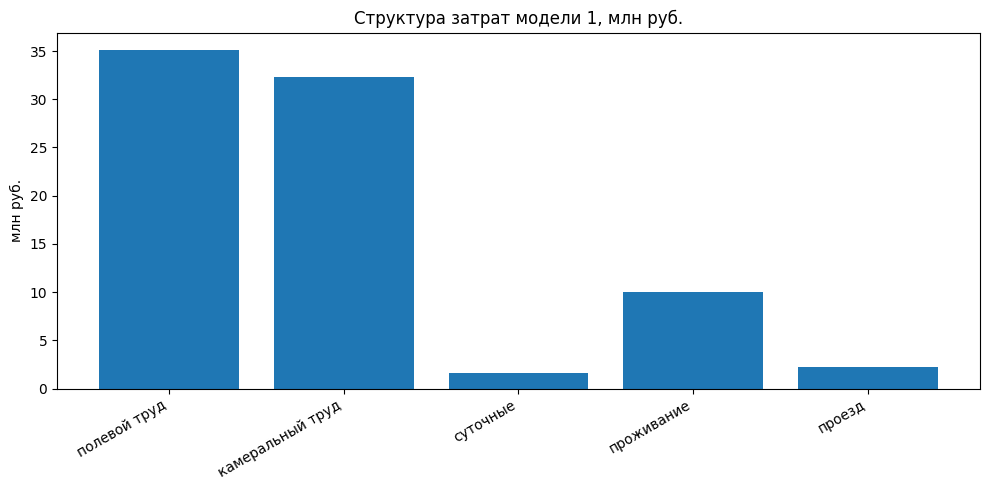

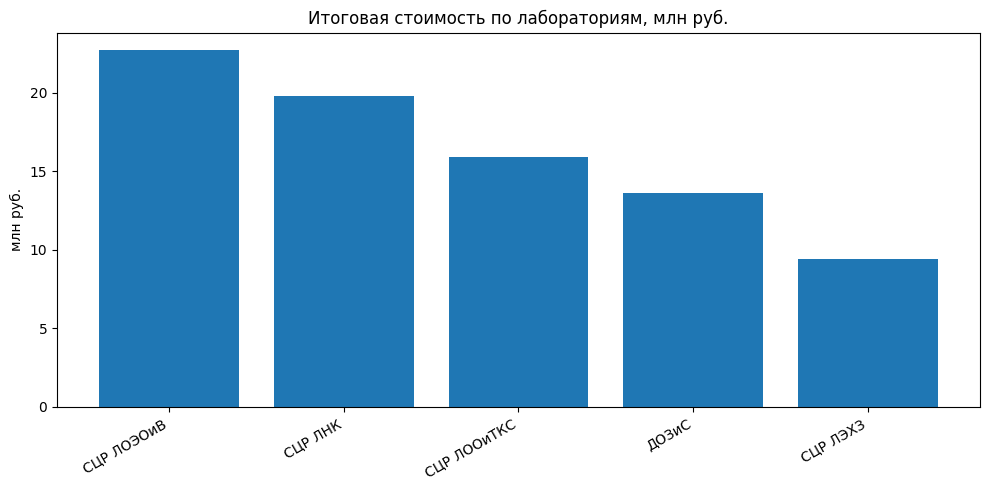

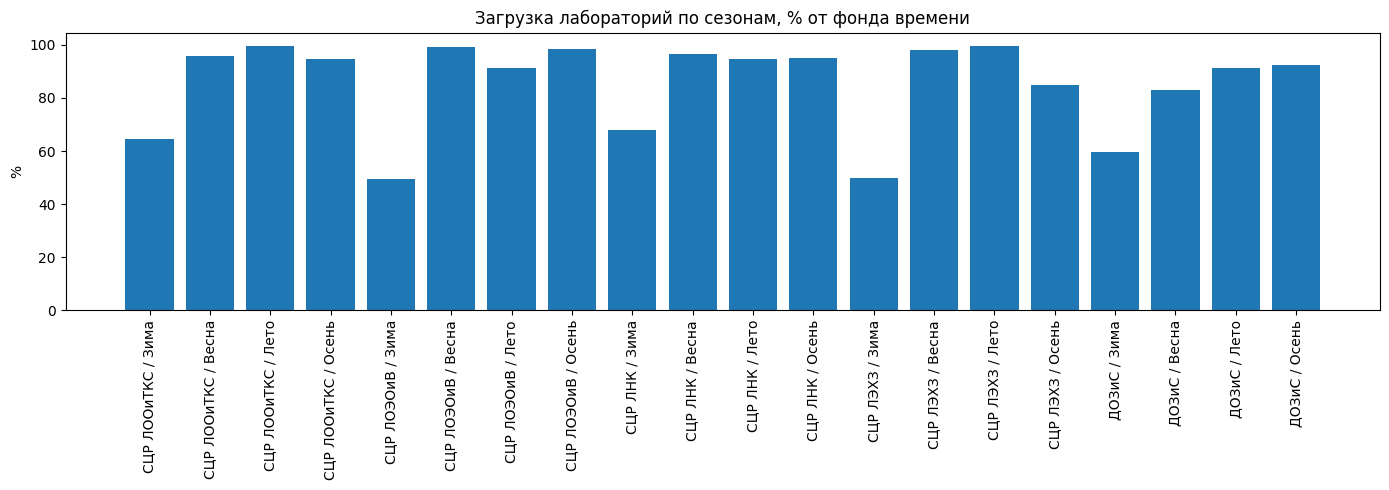

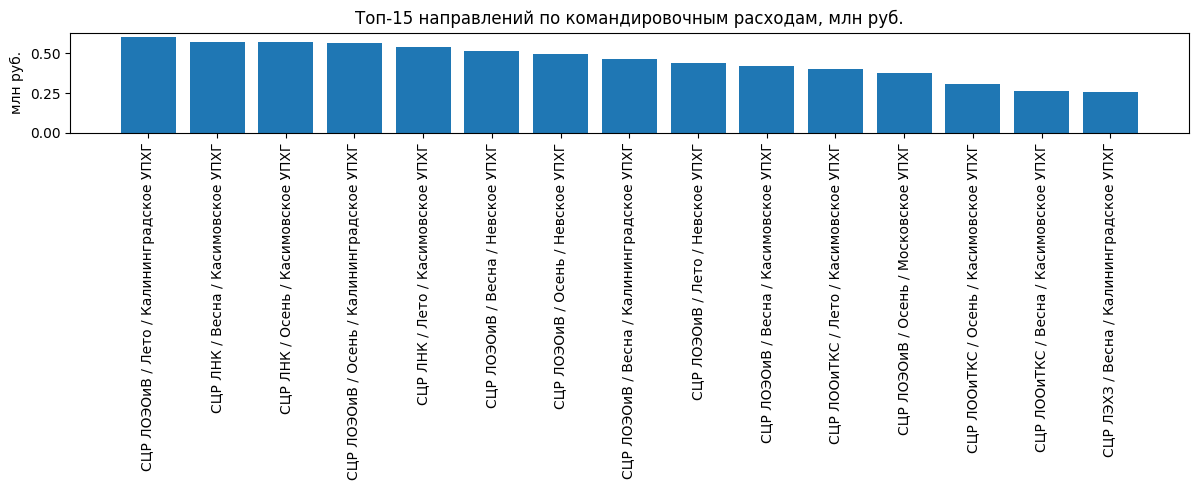

In [124]:
plot_components = model1_components[
    model1_components["компонент"].isin([
        "полевой труд",
        "камеральный труд",
        "суточные",
        "проживание",
        "проезд"
    ])
].copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_components["компонент"], plot_components["млн_руб"])
plt.title("Структура затрат модели 1, млн руб.")
plt.ylabel("млн руб.")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plot_lab_cost = model1_summary_lab.sort_values("стоимость_итого_руб", ascending=False).copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_lab_cost["лаборатория"], plot_lab_cost["стоимость_итого_руб"] / 1_000_000)
plt.title("Итоговая стоимость по лабораториям, млн руб.")
plt.ylabel("млн руб.")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plot_load = model1_summary_lab_season.copy()
plot_load["лаборатория_сезон"] = plot_load["лаборатория"] + " / " + plot_load["сезон"]

plt.figure(figsize=(14, 5))
plt.bar(plot_load["лаборатория_сезон"], plot_load["загрузка_%"])
plt.title("Загрузка лабораторий по сезонам, % от фонда времени")
plt.ylabel("%")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plot_trips = model1_trip_units.sort_values("командировочные_руб", ascending=False).head(15).copy()
plot_trips["связка"] = (
    plot_trips["лаборатория"]
    + " / "
    + plot_trips["сезон"]
    + " / "
    + plot_trips["филиал"]
)

plt.figure(figsize=(12, 5))
plt.bar(plot_trips["связка"], plot_trips["командировочные_руб"] / 1_000_000)
plt.title("Топ-15 направлений по командировочным расходам, млн руб.")
plt.ylabel("млн руб.")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [125]:
# print("objective:", value(model1.objective))
# print("field_labor_cost1:", value(field_labor_cost1))
# print("cam_labor_cost1:", value(cam_labor_cost1))
# print("trip_cost1:", value(trip_cost1))
# print("sum components:", value(field_labor_cost1) + value(cam_labor_cost1) + value(trip_cost1))

# display(model1_components)

In [126]:
model1_components_total = model1_components.loc[
    model1_components["компонент"] == "итого модель",
    "руб"
].iloc[0]

print("objective:", value(model1.objective))
print("components total:", model1_components_total)
print("difference:", value(model1.objective) - model1_components_total)

objective: 81407699.05428053
components total: 81407699.05428053
difference: 0.0


## ИТОГ ДЛЯ ТОГО ЧТОБ ПОКАЗАТЬ РЕЗУЛЬТАТ

In [127]:
# def normalize_work_ids(x):
#     if isinstance(x, (list, tuple, set)):
#         return [int(v) for v in x]
#     if pd.isna(x):
#         return []
#     if isinstance(x, str):
#         x = x.strip()
#         try:
#             parsed = ast.literal_eval(x)
#             if isinstance(parsed, (list, tuple, set)):
#                 return [int(v) for v in parsed]
#             return [int(parsed)]
#         except Exception:
#             return [int(v.strip()) for v in x.replace(";", ",").split(",") if v.strip()]
#     return [int(x)]


# # 1. Полевая часть: работы внутри выбранных полевых групп
# field_result = field_selected.copy()

# field_result["work_ids_norm"] = field_result["work_ids"].apply(normalize_work_ids)

# field_summary = (
#     field_result
#     .groupby(["лаборатория", "сезон"], as_index=False)
#     .agg(
#         полевые_группы=("trip_id", "count"),
#         полевые_работы=("work_ids_norm", lambda s: sorted(set(v for lst in s for v in lst))),
#         число_полевых_работ=("число_работ", "sum"),
#         полевые_часы=("полевые_часы", "sum"),
#         полевые_дни=("полевые_дни", "sum")
#     )
# )


# # 2. Камеральная часть: работы, назначенные лаборатории и сезону
# cam_result = cam_selected.copy()

# cam_summary = (
#     cam_result
#     .groupby(["лаборатория", "сезон"], as_index=False)
#     .agg(
#         камеральные_работы=("work_id", lambda s: sorted(set(int(v) for v in s))),
#         число_камеральных_работ=("work_id", "nunique"),
#         камеральные_часы=("камеральные_часы", "sum")
#     )
# )


# # 3. Объединяем поле и камералку в одну итоговую таблицу
# final_lab_season_plan = (
#     field_summary
#     .merge(cam_summary, on=["лаборатория", "сезон"], how="outer")
#     .fillna({
#         "полевые_группы": 0,
#         "число_полевых_работ": 0,
#         "полевые_часы": 0,
#         "полевые_дни": 0,
#         "число_камеральных_работ": 0,
#         "камеральные_часы": 0
#     })
# )

# final_lab_season_plan["полевые_работы"] = final_lab_season_plan["полевые_работы"].apply(
#     lambda x: x if isinstance(x, list) else []
# )
# final_lab_season_plan["камеральные_работы"] = final_lab_season_plan["камеральные_работы"].apply(
#     lambda x: x if isinstance(x, list) else []
# )

# final_lab_season_plan["всего_часов"] = (
#     final_lab_season_plan["полевые_часы"] + final_lab_season_plan["камеральные_часы"]
# )

# final_lab_season_plan = final_lab_season_plan.sort_values(["лаборатория", "сезон"]).reset_index(drop=True)

# display(final_lab_season_plan)

## HiGHS нашел оптимальное решение !!! 90,646 - 81,408 = 9,238 млн руб. экономии

<a id='6-календаризация-модели-1'></a>
<div style="background-color: pink; padding: 15px; border-radius: 5px;">
<h1 style="color: black;"> Календаризация решения модели 1</h1>
</div>

[Вернуться к содержанию](#задачи)


В этом блоке сезонное решение модели 1 переводится в календарный план. Сама оптимизационная модель уже выбрала лабораторию, сезон и укрупненные полевые группы. Здесь выполняется техническая календаризация: выбранные группы упаковываются в командировки, после чего для каждой командировки подбираются расчетные даты.

В этой версии нет автоматического добавления резервов, сотрудников, часов или дней. Единственный источник доступного фонда - таблица `production_calendar_2025`. 

### 6.1. Параметры и служебные функции календаризации


In [128]:
import math
import ast
from pathlib import Path

PLAN_YEAR = 2025
WORK_HOURS_PER_DAY = 8
MAX_FIELD_DAYS_PER_TRIP_CAL = 29
ROAD_DAYS_PER_TRIP_CAL = 1
CAM_AFTER_FIELD = True

# Дни и часы берутся из production_calendar_2025.
OUT_CALENDAR_MODEL1 = Path("model1_calendarization_manual_calendar.xlsx")


def safe_tuple(x):
    if isinstance(x, tuple):
        return tuple(int(v) for v in x)
    if isinstance(x, list):
        return tuple(int(v) for v in x)
    if pd.isna(x):
        return tuple()
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, (list, tuple)):
                return tuple(int(v) for v in parsed)
        except Exception:
            pass
        return tuple(int(v.strip()) for v in x.split(",") if v.strip())
    return tuple()


def month_to_season(m):
    if m in [12, 1, 2]:
        return "Зима"
    if m in [3, 4, 5]:
        return "Весна"
    if m in [6, 7, 8]:
        return "Лето"
    if m in [9, 10, 11]:
        return "Осень"
    return np.nan


def find_staff_column(df):
    for c in df.columns:
        cl = str(c).lower()
        if "числен" in cl or "штат" in cl or "кол" in cl:
            return c
    raise RuntimeError("В t2_model не найден столбец с численностью сотрудников.")

### 6.2. Проверка входных таблиц из решения модели 1


In [129]:
for name in ["model1_selected_groups", "model1_selected_cam", "t2_model"]:
    if name not in globals():
        raise RuntimeError(f"Нет объекта {name}. Сначала запусти базовую модель и блок извлечения решения.")

field_selected = model1_selected_groups.copy()
cam_selected = model1_selected_cam.copy()

if "trip_id" in field_selected.columns and "gr_id" not in field_selected.columns:
    field_selected = field_selected.rename(columns={"trip_id": "gr_id"})

if "id_работы" in cam_selected.columns and "work_id" not in cam_selected.columns:
    cam_selected = cam_selected.rename(columns={"id_работы": "work_id"})

needed_field_cols = ["лаборатория", "сезон", "филиал", "work_ids", "полевые_часы", "полевые_дни"]
needed_cam_cols = ["work_id", "лаборатория", "сезон", "камеральные_часы"]

missing_field = [c for c in needed_field_cols if c not in field_selected.columns]
missing_cam = [c for c in needed_cam_cols if c not in cam_selected.columns]

if missing_field:
    raise RuntimeError(f"В model1_selected_groups не хватает столбцов: {missing_field}")

if missing_cam:
    raise RuntimeError(f"В model1_selected_cam не хватает столбцов: {missing_cam}")

field_selected["work_ids"] = field_selected["work_ids"].apply(safe_tuple)
field_selected["полевые_часы"] = pd.to_numeric(field_selected["полевые_часы"], errors="coerce").fillna(0)
field_selected["полевые_дни"] = pd.to_numeric(field_selected["полевые_дни"], errors="coerce").fillna(0)
cam_selected["камеральные_часы"] = pd.to_numeric(cam_selected["камеральные_часы"], errors="coerce").fillna(0)

print("полевых групп:", len(field_selected))
print("работ в полевых группах:", int(field_selected["work_ids"].apply(len).sum()))
print("камеральных назначений:", len(cam_selected))

полевых групп: 1063
работ в полевых группах: 1290
камеральных назначений: 1290


### 6.3. Производственный календарь: только ручной фонд дней и часов

In [130]:
# Здесь календарь строится по production_calendar_2025.

manual_month_calendar = production_calendar_2025.copy()

manual_month_calendar["месяц"] = manual_month_calendar["месяц"].astype(int)
manual_month_calendar["рабочие_дни"] = manual_month_calendar["рабочие_дни"].astype(int)
manual_month_calendar["рабочие_часы_40ч"] = manual_month_calendar["рабочие_часы_40ч"].astype(float)
manual_month_calendar["сезон"] = manual_month_calendar["месяц"].map(month_to_season)

manual_month_calendar["часов_на_1_сотрудника_день"] = (
    manual_month_calendar["рабочие_часы_40ч"] / manual_month_calendar["рабочие_дни"]
)

if manual_month_calendar["месяц"].duplicated().any():
    raise RuntimeError("В production_calendar_2025 есть повторяющиеся месяцы.")

if set(manual_month_calendar["месяц"]) != set(range(1, 13)):
    raise RuntimeError("В production_calendar_2025 должны быть все месяцы от 1 до 12.")

if (manual_month_calendar["рабочие_дни"] <= 0).any():
    raise RuntimeError("В production_calendar_2025 рабочие_дни должны быть положительными.")

if (manual_month_calendar["рабочие_часы_40ч"] <= 0).any():
    raise RuntimeError("В production_calendar_2025 рабочие_часы_40ч должны быть положительными.")


def make_month_date_slots(year, month, target_days):
    month_start = pd.Timestamp(year=year, month=month, day=1)
    month_end = month_start + pd.offsets.MonthEnd(0)
    dates = pd.date_range(month_start, month_end, freq="D")

    # Сначала обычные будни, потом остальные даты месяца.
    # количество дат ровно такое, какое руками стоит в production_calendar_2025.
    weekdays = [d for d in dates if d.weekday() < 5]
    other_days = [d for d in dates if d.weekday() >= 5]
    ordered = weekdays + other_days

    if target_days > len(ordered):
        raise RuntimeError(
            f"В месяце {month} задано {target_days} рабочих дней, "
            f"но в месяце всего {len(ordered)} календарных дней."
        )

    return ordered[:target_days]


calendar_rows = []

for _, row in manual_month_calendar.sort_values("месяц").iterrows():
    month = int(row["месяц"])
    target_days = int(row["рабочие_дни"])
    target_hours = float(row["рабочие_часы_40ч"])
    hours_per_day = float(row["часов_на_1_сотрудника_день"])
    season = row["сезон"]

    for day_num, date in enumerate(make_month_date_slots(PLAN_YEAR, month, target_days), start=1):
        calendar_rows.append({
            "date": pd.Timestamp(date),
            "месяц": month,
            "месяц_название": row["месяц_название"],
            "сезон": season,
            "номер_рабочего_дня_в_месяце": day_num,
            "рабочие_дни_месяца_ручной_фонд": target_days,
            "рабочие_часы_месяца_ручной_фонд": target_hours,
            "часов_на_1_сотрудника_день": hours_per_day,
            "тип_дня": "расчетный рабочий день из production_calendar_2025"
        })

work_calendar = pd.DataFrame(calendar_rows).sort_values("date").reset_index(drop=True)

season_dates = {
    season: sorted(work_calendar.loc[work_calendar["сезон"] == season, "date"].tolist())
    for season in ["Зима", "Весна", "Лето", "Осень"]
}

season_hours_per_person = (
    work_calendar
    .groupby("сезон")["часов_на_1_сотрудника_день"]
    .sum()
    .to_dict()
)

print("\nручной фонд по месяцам:")
display(
    manual_month_calendar[[
        "месяц", "месяц_название", "сезон",
        "рабочие_дни", "рабочие_часы_40ч", "часов_на_1_сотрудника_день"
    ]]
)

print("\nрабочие дни и часы по сезонам из ручного календаря:")
manual_season_calendar = (
    work_calendar
    .groupby("сезон", as_index=False)
    .agg(
        рабочих_дней=("date", "count"),
        часов_на_1_сотрудника=("часов_на_1_сотрудника_день", "sum"),
        первая_дата=("date", "min"),
        последняя_дата=("date", "max")
    )
)
display(manual_season_calendar)

for season, dates in season_dates.items():
    print(season, len(dates), dates[0].date(), dates[-1].date())


ручной фонд по месяцам:


,месяц,месяц_название,сезон,рабочие_дни,рабочие_часы_40ч,часов_на_1_сотрудника_день
0,1,январь,Зима,17,136.0,8.000000
1,2,февраль,Зима,20,160.0,8.000000
2,3,март,Весна,22,176.0,8.000000
3,4,апрель,Весна,22,176.0,8.000000
4,5,май,Весна,22,176.0,8.000000
5,6,июнь,Лето,19,151.0,7.947368
6,7,июль,Лето,23,184.0,8.000000
7,8,август,Лето,21,168.0,8.000000
8,9,сентябрь,Осень,23,184.0,8.000000
9,10,октябрь,Осень,24,192.0,8.000000



рабочие дни и часы по сезонам из ручного календаря:


,сезон,рабочих_дней,часов_на_1_сотрудника,первая_дата,последняя_дата
0,Весна,66,528.0,2025-03-01,2025-05-30
1,Зима,59,472.0,2025-01-01,2025-12-30
2,Лето,63,503.0,2025-06-02,2025-08-29
3,Осень,70,560.0,2025-09-01,2025-11-28


Зима 59 2025-01-01 2025-12-30
Весна 66 2025-03-01 2025-05-30
Лето 63 2025-06-02 2025-08-29
Осень 70 2025-09-01 2025-11-28


### 6.4. Дневная емкость лабораторий


In [131]:
staff_col = find_staff_column(t2_model)

lab_staff = (
    t2_model
    .set_index("аббр")[staff_col]
    .apply(lambda x: max(1, int(math.floor(float(x)))))
    .to_dict()
)

labs = sorted(
    set(field_selected["лаборатория"].dropna().unique().tolist())
    | set(cam_selected["лаборатория"].dropna().unique().tolist())
)

print("используемая численность лабораторий:")
display(
    pd.DataFrame([
        {"лаборатория": lab, "численность_из_Т2": lab_staff.get(lab, 1)}
        for lab in labs
    ])
)

используемая численность лабораторий:


,лаборатория,численность_из_Т2
0,ДОЗиС,4
1,СЦР ЛНК,5
2,СЦР ЛООиТКС,5
3,СЦР ЛОЭОиВ,7
4,СЦР ЛЭХЗ,3


### 6.5. Упаковка полевых групп в командировки


### BIN PACKING (задача упаковки групп в командировочные выезды)

- есть группы с полевыми днями;
- одна командировка может вместить максимум 29 полевых дней;
- нужно разложить группы по командировкам так, чтобы командировки были максимально заполнены.
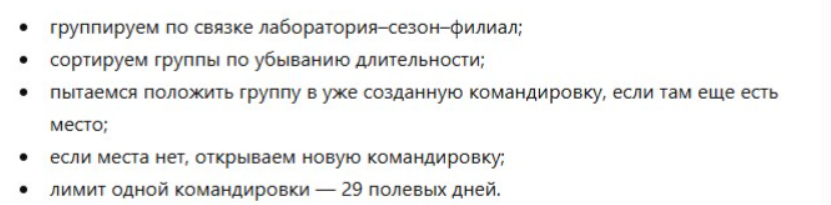

In [132]:
def pack_groups_to_trips(field_selected):
    rows = []
    calendar_trip_id = 1

    for (lab, season, filial), part in field_selected.groupby(
        ["лаборатория", "сезон", "филиал"], dropna=False
    ):
        part = part.copy()
        part["полевые_дни_ceil"] = part["полевые_дни"].apply(
            lambda x: max(1, int(math.ceil(float(x))))
        )

        part = part.sort_values(
            ["полевые_дни_ceil", "полевые_часы"],
            ascending=[False, False]
        ).reset_index(drop=True)

        bins = []

        for _, row in part.iterrows():
            row_days = int(row["полевые_дни_ceil"])
            placed = False

            for b in bins:
                if b["полевые_дни"] + row_days <= MAX_FIELD_DAYS_PER_TRIP_CAL:
                    b["rows"].append(row)
                    b["полевые_дни"] += row_days
                    placed = True
                    break

            if not placed:
                bins.append({
                    "rows": [row],
                    "полевые_дни": row_days
                })

        for b in bins:
            b_rows = pd.DataFrame(b["rows"])
            work_ids = []

            for x in b_rows["work_ids"]:
                work_ids.extend(list(x))

            rows.append({
                "calendar_trip_id": calendar_trip_id,
                "лаборатория": lab,
                "сезон": season,
                "филиал": filial,
                "work_ids": tuple(sorted(set(int(x) for x in work_ids))),
                "число_работ": len(set(work_ids)),
                "полевые_часы": float(b_rows["полевые_часы"].sum()),
                "полевые_дни": int(b["полевые_дни"]),
                "длительность_командировки_дней": int(b["полевые_дни"]) + ROAD_DAYS_PER_TRIP_CAL,
                "превышение_лимита": int(b["полевые_дни"]) > MAX_FIELD_DAYS_PER_TRIP_CAL
            })

            calendar_trip_id += 1

    return pd.DataFrame(rows)


trip_candidates = pack_groups_to_trips(field_selected)

print("\nупаковка командировок:")
print("командировок:", len(trip_candidates))
print("среднее число работ:", trip_candidates["число_работ"].mean())
print("командировок с одной работой:", int((trip_candidates["число_работ"] == 1).sum()))
print("превышений лимита:", int(trip_candidates["превышение_лимита"].sum()))

display(
    trip_candidates
    .groupby(["лаборатория", "сезон"], as_index=False)
    .agg(
        число_командировок=("calendar_trip_id", "count"),
        число_работ=("число_работ", "sum"),
        полевые_дни=("полевые_дни", "sum"),
        полевые_часы=("полевые_часы", "sum")
    )
)


упаковка командировок:
командировок: 150
среднее число работ: 8.6
командировок с одной работой: 13
превышений лимита: 0


,лаборатория,сезон,число_командировок,число_работ,полевые_дни,полевые_часы
0,ДОЗиС,Весна,6,18,83,577.579302
1,ДОЗиС,Зима,3,5,25,160.438695
2,ДОЗиС,Лето,6,26,110,834.281214
3,ДОЗиС,Осень,7,16,64,435.900936
4,СЦР ЛНК,Весна,9,112,207,1231.403443
5,СЦР ЛНК,Лето,8,109,178,966.438441
6,СЦР ЛНК,Осень,11,126,227,1316.016809
7,СЦР ЛООиТКС,Весна,7,77,142,806.060940
8,СЦР ЛООиТКС,Зима,1,9,13,77.963279
9,СЦР ЛООиТКС,Лето,9,105,181,1118.731301


### 6.6. Размещение полевых командировок по датам


функция: сколько рабочих дат минимум нужно для размещения одной командировки

In [133]:
def field_need_days(row):
    return int(max(
        1,
        math.ceil(float(row["полевые_дни"])),
        math.ceil(float(row["полевые_часы"]) / WORK_HOURS_PER_DAY)
    ))

диагностика перед размещением по датам - считаем по каждой связке 'лаборатория – сезон' сколько нужно:
- человеко-дней поля;
- полевых часов;
- камеральных часов;
- всего часов;
- сколько человеко-дней доступно;
- сколько часов доступно.

In [134]:
def calculate_lab_season_need(trip_candidates, cam_selected, season_dates):
    field_need = trip_candidates.copy()
    field_need["нужно_полевых_дней"] = field_need.apply(field_need_days, axis=1)

    person_days = (
        field_need
        .groupby(["лаборатория", "сезон"], as_index=False)
        .agg(
            требуется_человеко_дней_поля=("нужно_полевых_дней", "sum"),
            полевые_часы=("полевые_часы", "sum")
        )
    )

    cam_need = (
        cam_selected
        .groupby(["лаборатория", "сезон"], as_index=False)
        .agg(камеральные_часы=("камеральные_часы", "sum"))
    )

    need = (
        pd.DataFrame(
            [(lab, season) for lab in labs for season in ["Зима", "Весна", "Лето", "Осень"]],
            columns=["лаборатория", "сезон"]
        )
        .merge(person_days, on=["лаборатория", "сезон"], how="left")
        .merge(cam_need, on=["лаборатория", "сезон"], how="left")
        .fillna({
            "требуется_человеко_дней_поля": 0,
            "полевые_часы": 0,
            "камеральные_часы": 0
        })
    )

    need["численность"] = need["лаборатория"].map(lambda x: lab_staff.get(x, 1))
    need["доступные_дни_сезона"] = need["сезон"].map(lambda s: len(season_dates.get(s, [])))
    need["часов_на_1_сотрудника_в_сезоне"] = need["сезон"].map(lambda s: season_hours_per_person.get(s, 0))

    need["доступно_человеко_дней"] = need["численность"] * need["доступные_дни_сезона"]
    need["требуется_часов_всего"] = need["полевые_часы"] + need["камеральные_часы"]
    need["доступно_часов"] = need["численность"] * need["часов_на_1_сотрудника_в_сезоне"]

    need["нехватка_человеко_дней"] = (
        need["требуется_человеко_дней_поля"] - need["доступно_человеко_дней"]
    ).clip(lower=0)
    need["нехватка_часов"] = (
        need["требуется_часов_всего"] - need["доступно_часов"]
    ).clip(lower=0)

    need["сколько_дней_не_хватает_по_людям"] = np.ceil(
        need["нехватка_человеко_дней"] / need["численность"].replace(0, 1)
    ).astype(int)

    avg_hours = (
        need["часов_на_1_сотрудника_в_сезоне"] / need["доступные_дни_сезона"].replace(0, np.nan)
    ).fillna(WORK_HOURS_PER_DAY)

    need["сколько_дней_не_хватает_по_часам"] = np.ceil(
        need["нехватка_часов"] / (need["численность"].replace(0, 1) * avg_hours.replace(0, WORK_HOURS_PER_DAY))
    ).astype(int)

    need["сколько_дней_не_хватает"] = need[[
        "сколько_дней_не_хватает_по_людям",
        "сколько_дней_не_хватает_по_часам"
    ]].max(axis=1)

    return need.sort_values(["сезон", "лаборатория"])

In [135]:
need_before_schedule = calculate_lab_season_need(trip_candidates, cam_selected, season_dates)

print("\nпроверка сезонного фонда перед календаризацией:")
display(
    need_before_schedule[
        (need_before_schedule["требуется_человеко_дней_поля"] > 0)
        | (need_before_schedule["требуется_часов_всего"] > 0)
    ].sort_values(
        ["сколько_дней_не_хватает", "нехватка_человеко_дней", "нехватка_часов"],
        ascending=False
    )
)


проверка сезонного фонда перед календаризацией:


,лаборатория,сезон,требуется_человеко_дней_поля,полевые_часы,камеральные_часы,численность,доступные_дни_сезона,часов_на_1_сотрудника_в_сезоне,доступно_человеко_дней,требуется_часов_всего,доступно_часов,нехватка_человеко_дней,нехватка_часов,сколько_дней_не_хватает_по_людям,сколько_дней_не_хватает_по_часам,сколько_дней_не_хватает
1,ДОЗиС,Весна,83.0,577.579302,926.253310,4,66,528.0,264,1503.832612,2112.0,0.0,0.0,0,0,0
5,СЦР ЛНК,Весна,207.0,1231.403443,952.720260,5,66,528.0,330,2184.123703,2640.0,0.0,0.0,0,0,0
9,СЦР ЛООиТКС,Весна,142.0,806.060940,1359.802149,5,66,528.0,330,2165.863089,2640.0,0.0,0.0,0,0,0
13,СЦР ЛОЭОиВ,Весна,414.0,2767.073340,383.442499,7,66,528.0,462,3150.515839,3696.0,0.0,0.0,0,0,0
17,СЦР ЛЭХЗ,Весна,116.0,839.070898,495.784417,3,66,528.0,198,1334.855315,1584.0,0.0,0.0,0,0,0
0,ДОЗиС,Зима,25.0,160.438695,804.336854,4,59,472.0,236,964.775549,1888.0,0.0,0.0,0,0,0
4,СЦР ЛНК,Зима,0.0,0.000000,1373.339733,5,59,472.0,295,1373.339733,2360.0,0.0,0.0,0,0,0
8,СЦР ЛООиТКС,Зима,13.0,77.963279,1224.993015,5,59,472.0,295,1302.956294,2360.0,0.0,0.0,0,0,0
12,СЦР ЛОЭОиВ,Зима,135.0,906.791149,495.978572,7,59,472.0,413,1402.769721,3304.0,0.0,0.0,0,0,0
16,СЦР ЛЭХЗ,Зима,0.0,0.000000,605.257078,3,59,472.0,177,605.257078,1416.0,0.0,0.0,0,0,0


### Расчет дневной емкости лабораторий

In [136]:
daily_capacity_rows = []

for lab in labs:
    staff = lab_staff.get(lab, 1)

    for _, r in work_calendar.iterrows():
        daily_capacity_rows.append({
            "лаборатория": lab,
            "date": r["date"],
            "сезон": r["сезон"],
            "месяц": r["месяц"],
            "доступно_человек": staff,
            "часов_на_1_сотрудника_день": float(r["часов_на_1_сотрудника_день"]),
            "доступно_часов": staff * float(r["часов_на_1_сотрудника_день"]),
            "тип_дня": r["тип_дня"]
        })

daily_capacity = pd.DataFrame(daily_capacity_rows)
daily_capacity.head(3)

,лаборатория,date,сезон,месяц,доступно_человек,часов_на_1_сотрудника_день,доступно_часов,тип_дня
0,ДОЗиС,2025-01-01,Зима,1,4,8.0,32.0,расчетный рабочий день из production_calendar_...
1,ДОЗиС,2025-01-02,Зима,1,4,8.0,32.0,расчетный рабочий день из production_calendar_...
2,ДОЗиС,2025-01-03,Зима,1,4,8.0,32.0,расчетный рабочий день из production_calendar_...


In [137]:
# остатки ресурсов
staff_left = {
    (r["лаборатория"], r["date"]): int(r["доступно_человек"])
    for _, r in daily_capacity.iterrows()
}

hours_left = {
    (r["лаборатория"], r["date"]): float(r["доступно_часов"])
    for _, r in daily_capacity.iterrows()
}

### Функция: Распределение полевых часов внутри выбранных дат

Она получает:
- dates — выбранные даты командировки;
- caps — сколько часов доступно в эти даты;
- field_hours — сколько полевых часов надо разместить.

И распределяет полевые часы по выбранным датам так, чтобы: не превысить емкость дня; все часы были распределены; если где-то осталось мало места, часы перераспределились по другим датам.

In [138]:
def distribute_trip_hours(dates, caps, field_hours):
    remaining = float(field_hours)
    result = []

    for idx, (d, cap) in enumerate(zip(dates, caps)):
        days_left = len(dates) - idx
        if days_left == 1:
            used = remaining
        else:
            reserve_for_later = sum(caps[idx + 1:])
            used = min(cap, max(0.0, remaining - reserve_for_later))
            if used <= 1e-9:
                used = min(cap, remaining / days_left)
        used = min(float(cap), max(0.0, used))
        remaining -= used
        result.append((d, used))

    if abs(remaining) > 1e-5:
        for k in range(len(result)):
            if remaining <= 1e-5:
                break
            d, used = result[k]
            add = min(caps[k] - used, remaining)
            if add > 0:
                result[k] = (d, used + add)
                remaining -= add

    if remaining > 1e-5:
        raise RuntimeError("Не удалось распределить часы полевой командировки по выбранным датам.")

    return result

### 2 способа /подхода разместить полевые командировки по датам:
1) Точное разбиение по условным сотрудникам
2) гибкое размещение по свободным датам

### 1. Функция строгого размещ 

Можно ли распределить длительности командировок между сотрудниками так, чтобы у каждого сотрудника суммарно не было больше рабочих дней, чем есть в сезоне?

поиск с возвратом (backtracking через dfs)

In [139]:
def exact_pack_to_staff(durations, staff_count, horizon_days):
    order = sorted(range(len(durations)), key=lambda i: (-durations[i], i))
    loads = [0] * staff_count
    bins = [[] for _ in range(staff_count)]

    def dfs(pos):
        if pos == len(order):
            return True

        job = order[pos]
        p = durations[job]
        tried_loads = set()
        staff_order = sorted(range(staff_count), key=lambda b: loads[b])

        for b in staff_order:
            if loads[b] in tried_loads:
                continue
            if loads[b] + p <= horizon_days:
                tried_loads.add(loads[b])
                loads[b] += p
                bins[b].append(job)

                if dfs(pos + 1):
                    return True

                bins[b].pop()
                loads[b] -= p

            if loads[b] == 0:
                break

        return False

    if dfs(0):
        return bins, loads

    return None, loads

try_contiguous_staff_schedule пытается поставить в календарь командировки после распределения exact_pack_to_staff

In [140]:
def try_contiguous_staff_schedule(part, lab, season):
    dates = season_dates.get(season, [])
    staff_count = lab_staff.get(lab, 1)

    if len(dates) == 0 or part.empty:
        return [], []

    jobs = part.copy().reset_index(drop=True)
    durations = jobs["нужно_дней"].astype(int).tolist()
    bins, loads = exact_pack_to_staff(durations, staff_count, len(dates))

    if bins is None:
        return None, [{
            "лаборатория": lab,
            "сезон": season,
            "причина": "не найдено разбиение командировок по сотрудникам без пересечений",
            "командировок": len(jobs),
            "требуется_человеко_дней": sum(durations),
            "доступно_человеко_дней": staff_count * len(dates),
            "численность": staff_count,
            "рабочих_дней_сезона": len(dates)
        }]

    planned = []

    for worker_idx, job_indices in enumerate(bins, start=1):
        current_pos = 0
        job_indices = sorted(
            job_indices,
            key=lambda k: (-int(jobs.loc[k, "нужно_дней"]), -float(jobs.loc[k, "плотность_часов"]), int(jobs.loc[k, "calendar_trip_id"]))
        )

        for job_idx in job_indices:
            trip = jobs.loc[job_idx].copy()
            need_days = int(trip["нужно_дней"])
            block = dates[current_pos:current_pos + need_days]
            caps = [min(float(hours_left.get((lab, d), 0)), WORK_HOURS_PER_DAY) for d in block]

            if len(block) < need_days or sum(caps) + 1e-9 < float(trip["полевые_часы"]):
                return None, [{
                    "лаборатория": lab,
                    "сезон": season,
                    "calendar_trip_id": int(trip["calendar_trip_id"]),
                    "причина": "разбиение по сотрудникам найдено, но не хватило часовой емкости выбранного блока"
                }]

            planned.append((trip, block, caps, worker_idx, "цельный блок по сотруднику"))
            current_pos += need_days

    return planned, []

### 2. Гибкое размещение командировок по свободным рабочим датам (Это жадная эвристика: "жадное" размещение по свободным датам)

включается, если первый способ не смог разложить командировки цельными блоками

- берет командировки по лаборатории и сезону;
- сортирует самые тяжелые вперед: ["нужно_дней", "полевые_часы", "число_работ"]
- для каждой командировки ищет свободные даты в сезоне;
- выбирает даты, где больше свободных часов и людей;
- уменьшает остаток людей и часов на этих датах.

In [141]:
def flexible_dates_schedule(part, lab, season):
    dates = season_dates.get(season, [])
    jobs = part.copy().sort_values(
        ["нужно_дней", "плотность_часов", "число_работ"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    local_staff = {d: int(staff_left.get((lab, d), 0)) for d in dates}
    local_hours = {d: float(hours_left.get((lab, d), 0)) for d in dates}
    planned = []
    not_planned = []

    for _, trip in jobs.iterrows():
        need_days = int(trip["нужно_дней"])
        field_hours = float(trip["полевые_часы"])

        feasible = []
        for d in dates:
            if local_staff.get(d, 0) <= 0:
                continue
            cap = min(local_hours.get(d, 0), WORK_HOURS_PER_DAY)
            if cap > 1e-9:
                feasible.append((d, cap, local_staff[d]))

        if len(feasible) < need_days:
            row = trip.to_dict()
            row["причина"] = "не хватает свободных рабочих дат сезона"
            not_planned.append(row)
            continue

        selected = sorted(feasible, key=lambda x: (x[1], x[2], -x[0].toordinal()), reverse=True)[:need_days]
        selected = sorted(selected, key=lambda x: x[0])
        block = [x[0] for x in selected]
        caps = [x[1] for x in selected]

        if sum(caps) + 1e-9 < field_hours:
            row = trip.to_dict()
            row["причина"] = "не хватает свободного часового фонда в выбранных рабочих датах"
            not_planned.append(row)
            continue

        for d in block:
            local_staff[d] -= 1
        allocated = distribute_trip_hours(block, caps, field_hours)
        for d, used in allocated:
            local_hours[d] -= used

        planned.append((trip, block, caps, None, "по свободным рабочим датам сезона"))

    if not_planned:
        return planned, not_planned

    return planned, []

### фиксация
функция фиксирует уже размещенную командировку (командировка окончательно записывается в результат scheduled_trip_rows)

In [142]:
def commit_planned_trip(trip, block, caps, worker_idx, slot_type, scheduled_trip_rows, field_daily_rows):
    lab = trip["лаборатория"]
    season = trip["сезон"]
    field_hours = float(trip["полевые_часы"])
    allocated = distribute_trip_hours(block, caps, field_hours)

    for d, used_hours in allocated:
        # Уменьшает остатки ресурсов
        staff_left[(lab, d)] -= 1
        hours_left[(lab, d)] -= used_hours

        field_daily_rows.append({
            "calendar_trip_id": int(trip["calendar_trip_id"]),
            "date": d,
            "лаборатория": lab,
            "сезон": season,
            "филиал": trip["филиал"],
            "полевые_часы_день": used_hours
        })

    row = trip.to_dict()
    row["дата_выезда"] = block[0] - pd.Timedelta(days=1)
    row["дата_начала_поля"] = block[0]
    row["дата_окончания_поля"] = block[-1]
    row["дата_возвращения"] = block[-1] + pd.Timedelta(days=1)
    row["полевые_даты"] = ", ".join(pd.Timestamp(d).strftime("%Y-%m-%d") for d in block)
    row["номер_условного_сотрудника"] = worker_idx
    row["тип_размещения"] = slot_type
    row["запланировано"] = True
    scheduled_trip_rows.append(row)

In [143]:
scheduled_trip_rows = []
field_daily_rows = []
not_scheduled_trip_rows = []
calendar_packing_diagnostics = []

In [144]:
trip_candidates_for_calendar = (
    trip_candidates
    .assign(
        нужно_дней=lambda df: df.apply(field_need_days, axis=1),
        полевые_часы_calc=lambda df: df["полевые_часы"].astype(float),
        плотность_часов=lambda df: df["полевые_часы"].astype(float) / df.apply(field_need_days, axis=1)
    )
    .sort_values(
        ["лаборатория", "сезон", "нужно_дней", "плотность_часов", "число_работ"],
        ascending=[True, True, False, False, False]
    )
    .reset_index(drop=True)
)

### Основной цикл размещения командировок

сначала 1 строгий, если неполуч - нестрогий , запоминаем и успешные фиксируем

In [145]:
for (lab, season), part in trip_candidates_for_calendar.groupby(["лаборатория", "сезон"], sort=True):
    part = part.copy().reset_index(drop=True)

    planned, diagnostics = try_contiguous_staff_schedule(part, lab, season)

    if planned is None:
        calendar_packing_diagnostics.extend(diagnostics)
        planned, not_planned = flexible_dates_schedule(part, lab, season)
        placement_mode = "по свободным рабочим датам сезона"
    else:
        not_planned = []
        placement_mode = "цельный блок по сотруднику"

    calendar_packing_diagnostics.append({
        "лаборатория": lab,
        "сезон": season,
        "режим_размещения": placement_mode,
        "командировок": len(part),
        "запланировано": len(planned),
        "не_запланировано": len(not_planned),
        "требуется_человеко_дней": int(part["нужно_дней"].sum()),
        "доступно_человеко_дней": int(lab_staff.get(lab, 1) * len(season_dates.get(season, []))),
        "численность": int(lab_staff.get(lab, 1)),
        "рабочих_дней_сезона": int(len(season_dates.get(season, [])))
    })

    for trip, block, caps, worker_idx, slot_type in planned:
        commit_planned_trip(trip, block, caps, worker_idx, slot_type, scheduled_trip_rows, field_daily_rows)

    for row in not_planned:
        row = dict(row)
        row["нужно_дней"] = int(row.get("нужно_дней", field_need_days(row)))
        row["доступно_дней_сезона"] = len(season_dates.get(season, []))
        row["численность_лаборатории"] = lab_staff.get(lab, 1)
        not_scheduled_trip_rows.append(row)

In [146]:
calendar_trips = pd.DataFrame(scheduled_trip_rows)
not_scheduled_trips = pd.DataFrame(not_scheduled_trip_rows)
field_daily = pd.DataFrame(field_daily_rows)
calendar_packing_diagnostics = pd.DataFrame(calendar_packing_diagnostics)

print("\nкалендаризация поля:")
print("запланировано командировок:", len(calendar_trips))
print("не запланировано командировок:", len(not_scheduled_trips))

print("\nдиагностика режимов размещения:")
display(calendar_packing_diagnostics.sort_values(["не_запланировано", "режим_размещения"], ascending=[False, True]))


календаризация поля:
запланировано командировок: 150
не запланировано командировок: 0

диагностика режимов размещения:


,лаборатория,сезон,режим_размещения,командировок,запланировано,не_запланировано,требуется_человеко_дней,доступно_человеко_дней,численность,рабочих_дней_сезона,причина
12,СЦР ЛОЭОиВ,Весна,по свободным рабочим датам сезона,16,16.0,0.0,414,462,7,66,NaN
16,СЦР ЛОЭОиВ,Осень,по свободным рабочим датам сезона,20,20.0,0.0,487,490,7,70,NaN
0,ДОЗиС,Весна,цельный блок по сотруднику,6,6.0,0.0,83,264,4,66,NaN
1,ДОЗиС,Зима,цельный блок по сотруднику,3,3.0,0.0,25,236,4,59,NaN
2,ДОЗиС,Лето,цельный блок по сотруднику,6,6.0,0.0,110,252,4,63,NaN
3,ДОЗиС,Осень,цельный блок по сотруднику,7,7.0,0.0,64,280,4,70,NaN
4,СЦР ЛНК,Весна,цельный блок по сотруднику,9,9.0,0.0,207,330,5,66,NaN
5,СЦР ЛНК,Лето,цельный блок по сотруднику,8,8.0,0.0,178,315,5,63,NaN
6,СЦР ЛНК,Осень,цельный блок по сотруднику,11,11.0,0.0,227,350,5,70,NaN
7,СЦР ЛООиТКС,Весна,цельный блок по сотруднику,7,7.0,0.0,142,330,5,66,NaN


In [147]:
if len(not_scheduled_trips) > 0:
    cols = [
        "calendar_trip_id", "лаборатория", "сезон", "филиал",
        "число_работ", "полевые_дни", "полевые_часы",
        "нужно_дней", "доступно_дней_сезона",
        "численность_лаборатории", "причина"
    ]
    cols = [c for c in cols if c in not_scheduled_trips.columns]
    display(not_scheduled_trips[cols].head(50))

if not calendar_trips.empty:
    display(
        calendar_trips
        .sort_values(["лаборатория", "сезон", "дата_начала_поля"])
        .head(50)
    )

,calendar_trip_id,лаборатория,сезон,филиал,work_ids,число_работ,полевые_часы,полевые_дни,длительность_командировки_дней,превышение_лимита,...,полевые_часы_calc,плотность_часов,дата_выезда,дата_начала_поля,дата_окончания_поля,дата_возвращения,полевые_даты,номер_условного_сотрудника,тип_размещения,запланировано
0,5,ДОЗиС,Весна,Похвистневское УПХГ,"(13, 16, 17, 19, 20)",5,160.438695,25,26,False,...,160.438695,6.417548,2025-02-28,2025-03-01,2025-04-03,2025-04-04,"2025-03-01, 2025-03-03, 2025-03-04, 2025-03-05...",1.0,цельный блок по сотруднику,True
1,2,ДОЗиС,Весна,Краснодарское УПХГ,"(41, 42, 43, 44)",4,128.350956,17,18,False,...,128.350956,7.550056,2025-02-28,2025-03-01,2025-03-24,2025-03-25,"2025-03-01, 2025-03-03, 2025-03-04, 2025-03-05...",2.0,цельный блок по сотруднику,True
3,4,ДОЗиС,Весна,Песчано-Уметское УПХГ,"(37, 38, 39, 40)",4,128.350956,17,18,False,...,128.350956,7.550056,2025-02-28,2025-03-01,2025-03-24,2025-03-25,"2025-03-01, 2025-03-03, 2025-03-04, 2025-03-05...",3.0,цельный блок по сотруднику,True
4,1,ДОЗиС,Весна,Волгоградское УПХГ,"(26, 30)",2,64.175478,10,11,False,...,64.175478,6.417548,2025-02-28,2025-03-01,2025-03-13,2025-03-14,"2025-03-01, 2025-03-03, 2025-03-04, 2025-03-05...",4.0,цельный блок по сотруднику,True
5,3,ДОЗиС,Весна,Ленинградское УПХГ,"(8, 9)",2,64.175478,9,10,False,...,64.175478,7.130609,2025-03-13,2025-03-14,2025-03-26,2025-03-27,"2025-03-14, 2025-03-17, 2025-03-18, 2025-03-19...",4.0,цельный блок по сотруднику,True
2,6,ДОЗиС,Весна,Саратовское УАВР и КРС,"(36,)",1,32.087739,5,6,False,...,32.087739,6.417548,2025-03-24,2025-03-25,2025-03-31,2025-04-01,"2025-03-25, 2025-03-26, 2025-03-27, 2025-03-28...",2.0,цельный блок по сотруднику,True
6,8,ДОЗиС,Зима,Ленинградское УПХГ,"(7, 10)",2,64.175478,10,11,False,...,64.175478,6.417548,2024-12-31,2025-01-01,2025-01-14,2025-01-15,"2025-01-01, 2025-01-02, 2025-01-03, 2025-01-06...",1.0,цельный блок по сотруднику,True
7,9,ДОЗиС,Зима,Похвистневское УПХГ,"(14, 15)",2,64.175478,10,11,False,...,64.175478,6.417548,2024-12-31,2025-01-01,2025-01-14,2025-01-15,"2025-01-01, 2025-01-02, 2025-01-03, 2025-01-06...",2.0,цельный блок по сотруднику,True
8,7,ДОЗиС,Зима,Волгоградское УПХГ,"(23,)",1,32.087739,5,6,False,...,32.087739,6.417548,2024-12-31,2025-01-01,2025-01-07,2025-01-08,"2025-01-01, 2025-01-02, 2025-01-03, 2025-01-06...",3.0,цельный блок по сотруднику,True
9,10,ДОЗиС,Лето,Волгоградское УПХГ,"(21, 22, 24, 25, 27, 28, 34)",7,224.614173,29,30,False,...,224.614173,7.745316,2025-06-01,2025-06-02,2025-07-14,2025-07-15,"2025-06-02, 2025-06-03, 2025-06-04, 2025-06-05...",1.0,цельный блок по сотруднику,True


### 6.7. Размещение камеральных работ и проверка загрузки


In [148]:
work_to_field_end = {}

if not calendar_trips.empty:
    for _, row in calendar_trips.iterrows():
        for w in row["work_ids"]:
            work_to_field_end[int(w)] = row["дата_окончания_поля"]

In [149]:
cam_daily_rows = []
not_scheduled_cam_rows = []

cam_selected = cam_selected.sort_values("камеральные_часы", ascending=False).reset_index(drop=True)

for _, row in cam_selected.iterrows():
    work_id = int(row["work_id"])
    lab = row["лаборатория"]
    season = row["сезон"]
    hours_need = float(row["камеральные_часы"])
    hours_remain = hours_need

    dates = season_dates.get(season, [])

    if CAM_AFTER_FIELD and work_id in work_to_field_end:
        dates = [d for d in dates if d > pd.Timestamp(work_to_field_end[work_id])]

    for d in dates:
        if hours_remain <= 1e-9:
            break

        free_h = hours_left.get((lab, d), 0)

        if free_h <= 1e-9:
            continue

        used = min(hours_remain, free_h)
        hours_left[(lab, d)] -= used
        hours_remain -= used

        cam_daily_rows.append({
            "work_id": work_id,
            "date": d,
            "лаборатория": lab,
            "сезон": season,
            "камеральные_часы_день": used
        })

    if hours_remain > 1e-6:
        not_scheduled_cam_rows.append({
            "work_id": work_id,
            "лаборатория": lab,
            "сезон": season,
            "камеральные_часы": hours_need,
            "не_размещено_часов": hours_remain
        })

cam_daily = pd.DataFrame(cam_daily_rows)
not_scheduled_cam = pd.DataFrame(not_scheduled_cam_rows)

In [150]:
print("календаризация камералки:")
print("камеральных работ всего:", len(cam_selected))
print("камеральных работ не полностью размещено:", len(not_scheduled_cam))

календаризация камералки:
камеральных работ всего: 1290
камеральных работ не полностью размещено: 423


In [151]:
if len(not_scheduled_cam) > 0:
    display(not_scheduled_cam.head(50))

if not field_daily.empty:
    field_daily_load = (
        field_daily
        .groupby(["лаборатория", "date"], as_index=False)
        .agg(полевые_часы=("полевые_часы_день", "sum"))
    )
else:
    field_daily_load = pd.DataFrame(columns=["лаборатория", "date", "полевые_часы"])

if not cam_daily.empty:
    cam_daily_load = (
        cam_daily
        .groupby(["лаборатория", "date"], as_index=False)
        .agg(камеральные_часы=("камеральные_часы_день", "sum"))
    )
else:
    cam_daily_load = pd.DataFrame(columns=["лаборатория", "date", "камеральные_часы"])

,work_id,лаборатория,сезон,камеральные_часы,не_размещено_часов
0,18,ДОЗиС,Лето,60.958228,60.958228
1,1,ДОЗиС,Весна,60.958228,60.958228
2,6,ДОЗиС,Весна,60.958228,60.958228
3,49,ДОЗиС,Весна,60.958228,60.958228
4,48,ДОЗиС,Весна,60.958228,60.958228
5,28,ДОЗиС,Весна,60.958228,60.958228
6,24,ДОЗиС,Весна,60.958228,60.958228
7,22,ДОЗиС,Зима,60.958228,27.498736
8,25,ДОЗиС,Весна,60.958228,60.958228
9,65,ДОЗиС,Весна,60.958228,60.958228


In [152]:
daily_load = (
    daily_capacity
    .merge(field_daily_load, on=["лаборатория", "date"], how="left")
    .merge(cam_daily_load, on=["лаборатория", "date"], how="left")
    .fillna({
        "полевые_часы": 0,
        "камеральные_часы": 0
    })
)

In [153]:
daily_load["итого_часы"] = daily_load["полевые_часы"] + daily_load["камеральные_часы"]
daily_load["перегрузка_часов"] = (daily_load["итого_часы"] - daily_load["доступно_часов"]).clip(lower=0)
daily_load["загрузка_%"] = daily_load["итого_часы"] / daily_load["доступно_часов"] * 100

In [154]:
lab_season_load = (
    daily_load
    .groupby(["лаборатория", "сезон"], as_index=False)
    .agg(
        фонд_часов=("доступно_часов", "sum"),
        полевые_часы=("полевые_часы", "sum"),
        камеральные_часы=("камеральные_часы", "sum"),
        итого_часы=("итого_часы", "sum"),
        перегрузка_часов=("перегрузка_часов", "sum"),
        максимум_загрузки_день_proc=("загрузка_%", "max")
    )
)

In [155]:
lab_season_load["средняя_загрузка_%"] = (
    lab_season_load["итого_часы"] / lab_season_load["фонд_часов"] * 100
)

In [156]:
calendar_summary = pd.DataFrame([{
    "командировок_после_упаковки": len(trip_candidates),
    "командировок_запланировано": len(calendar_trips),
    "командировок_не_запланировано": len(not_scheduled_trips),
    "работ_в_полевой_части": int(field_selected["work_ids"].apply(len).sum()),
    "камеральных_работ": len(cam_selected),
    "камеральных_работ_не_полностью_размещено": len(not_scheduled_cam),
    "дней_с_перегрузкой": int((daily_load["перегрузка_часов"] > 1e-6).sum()),
    "максимальная_перегрузка_часов": float(daily_load["перегрузка_часов"].max()),
    "максимальная_загрузка_%": float(daily_load["загрузка_%"].max()),
    "средняя_загрузка_по_занятым_дням_%": float(daily_load.loc[daily_load["итого_часы"] > 0, "загрузка_%"].mean()),
    "среднее_число_работ_в_командировке": float(trip_candidates["число_работ"].mean()),
    "доля_командировок_с_1_работой_%": float((trip_candidates["число_работ"] == 1).mean() * 100)
}])

print("итог календаризации:")
display(calendar_summary)

print("\nзагрузка лабораторий по сезонам:")
display(lab_season_load.sort_values(["лаборатория", "сезон"]))

итог календаризации:


,командировок_после_упаковки,командировок_запланировано,командировок_не_запланировано,работ_в_полевой_части,камеральных_работ,камеральных_работ_не_полностью_размещено,дней_с_перегрузкой,максимальная_перегрузка_часов,максимальная_загрузка_%,средняя_загрузка_по_занятым_дням_%,среднее_число_работ_в_командировке,доля_командировок_с_1_работой_%
0,150,150,0,1290,1290,423,17,0.210526,100.662252,88.807503,8.6,8.666667



загрузка лабораторий по сезонам:


,лаборатория,сезон,фонд_часов,полевые_часы,камеральные_часы,итого_часы,перегрузка_часов,максимум_загрузки_день_proc,средняя_загрузка_%
0,ДОЗиС,Весна,2112.0,577.579302,426.707596,1004.286898,0.000000e+00,100.000000,47.551463
1,ДОЗиС,Зима,1888.0,160.438695,704.000000,864.438695,0.000000e+00,100.000000,45.785948
2,ДОЗиС,Лето,2012.0,834.281214,670.540508,1504.821722,3.578947e+00,100.662252,74.792332
3,ДОЗиС,Осень,2240.0,435.900936,1341.081016,1776.981952,0.000000e+00,100.000000,79.329551
4,СЦР ЛНК,Весна,2640.0,1231.403443,251.033337,1482.436780,0.000000e+00,100.000000,56.152908
5,СЦР ЛНК,Зима,2360.0,0.000000,880.000000,880.000000,0.000000e+00,100.000000,37.288136
6,СЦР ЛНК,Лето,2515.0,966.438441,754.248801,1720.687242,2.131628e-14,100.000000,68.416988
7,СЦР ЛНК,Осень,2800.0,1316.016809,966.995157,2283.011966,1.421085e-14,100.000000,81.536142
8,СЦР ЛООиТКС,Весна,2640.0,806.060940,428.354072,1234.415012,0.000000e+00,100.000000,46.758144
9,СЦР ЛООиТКС,Зима,2360.0,77.963279,938.160075,1016.123354,0.000000e+00,100.000000,43.056074


### 6.8. Экспорт календаризации модели 1


In [157]:
with pd.ExcelWriter(OUT_CALENDAR_MODEL1, engine="openpyxl") as writer:
    calendar_summary.to_excel(writer, sheet_name="итог", index=False)
    calendar_trips.to_excel(writer, sheet_name="командировки", index=False)
    not_scheduled_trips.to_excel(writer, sheet_name="не_размещены_командировки", index=False)
    field_daily.to_excel(writer, sheet_name="полевые_по_дням", index=False)
    cam_daily.to_excel(writer, sheet_name="камеральные_по_дням", index=False)
    not_scheduled_cam.to_excel(writer, sheet_name="не_размещена_камералка", index=False)
    daily_load.to_excel(writer, sheet_name="дневная_загрузка", index=False)
    lab_season_load.to_excel(writer, sheet_name="загрузка_лаб_сезон", index=False)
    trip_candidates.to_excel(writer, sheet_name="командировки_упаковка", index=False)
    manual_month_calendar.to_excel(writer, sheet_name="ручной_календарь_месяцы", index=False)
    manual_season_calendar.to_excel(writer, sheet_name="ручной_календарь_сезоны", index=False)
    work_calendar.to_excel(writer, sheet_name="расчетные_рабочие_даты", index=False)
    field_selected.to_excel(writer, sheet_name="исходные_полевые_группы", index=False)
    cam_selected.to_excel(writer, sheet_name="исходная_камералка", index=False)

print("готово:", OUT_CALENDAR_MODEL1.resolve())

готово: /root/diplom/model1_calendarization_manual_calendar.xlsx


In [158]:
import matplotlib.dates as mdates

calendar_plot = calendar_trips.copy()

rename_map = {
    "calendar_trip_id": "trip_id",
    "лаборатория": "lab",
    "филиал": "branch",
    "сезон": "season",
    "дата_начала_поля": "start",
    "дата_окончания_поля": "end",
    "дата_выезда": "departure",
    "дата_возвращения": "return",
    "число_работ": "works_count",
    "полевые_дни": "field_days",
    "полевые_часы": "field_hours",
    "тип_размещения": "placement_type"
}

calendar_plot = calendar_plot.rename(columns={k: v for k, v in rename_map.items() if k in calendar_plot.columns})

for col in ["start", "end", "departure", "return"]:
    if col in calendar_plot.columns:
        calendar_plot[col] = pd.to_datetime(calendar_plot[col])

required_cols = ["trip_id", "lab", "branch", "season", "start", "end"]

missing_cols = [c for c in required_cols if c not in calendar_plot.columns]
if missing_cols:
    print("Не хватает колонок:", missing_cols)
    print("Фактические колонки calendar_trips:")
    print(calendar_trips.columns.tolist())
else:
    view_cols = [
        "trip_id", "lab", "branch", "season",
        "start", "end", "works_count", "field_days",
        "field_hours", "placement_type"
    ]
    view_cols = [c for c in view_cols if c in calendar_plot.columns]

    print("Размер календаря командировок:", calendar_plot.shape)
    display(
        calendar_plot[view_cols]
        .sort_values(["start", "lab", "trip_id"])
        .reset_index(drop=True)
        .head(40)
    )

Размер календаря командировок: (150, 21)


,trip_id,lab,branch,season,start,end,works_count,field_days,field_hours,placement_type
0,7,ДОЗиС,Волгоградское УПХГ,Зима,2025-01-01,2025-01-07,1,5,32.087739,цельный блок по сотруднику
1,8,ДОЗиС,Ленинградское УПХГ,Зима,2025-01-01,2025-01-14,2,10,64.175478,цельный блок по сотруднику
2,9,ДОЗиС,Похвистневское УПХГ,Зима,2025-01-01,2025-01-14,2,10,64.175478,цельный блок по сотруднику
3,58,СЦР ЛООиТКС,Касимовское УПХГ,Зима,2025-01-01,2025-01-17,9,13,77.963279,цельный блок по сотруднику
4,92,СЦР ЛОЭОиВ,Калининградское УПХГ,Зима,2025-01-01,2025-02-13,16,26,146.677340,цельный блок по сотруднику
5,93,СЦР ЛОЭОиВ,Касимовское УПХГ,Зима,2025-01-01,2025-02-12,3,25,191.016214,цельный блок по сотруднику
6,94,СЦР ЛОЭОиВ,Касимовское УПХГ,Зима,2025-01-01,2025-01-16,2,12,87.697442,цельный блок по сотруднику
7,95,СЦР ЛОЭОиВ,Московское УПХГ,Зима,2025-01-01,2025-02-11,9,24,155.206464,цельный блок по сотруднику
8,96,СЦР ЛОЭОиВ,Невское УПХГ,Зима,2025-01-01,2025-02-18,5,29,219.045867,цельный блок по сотруднику
9,97,СЦР ЛОЭОиВ,Невское УПХГ,Зима,2025-01-01,2025-02-04,12,19,107.147822,цельный блок по сотруднику


Чтобы посмотреть детализацию, какие работы есть в каждом выезде:

In [159]:
import ast

def normalize_work_ids(x):
    if isinstance(x, (list, tuple, set)):
        return [int(v) for v in x]
    if pd.isna(x):
        return []
    if isinstance(x, str):
        x = x.strip()
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, (list, tuple, set)):
                return [int(v) for v in parsed]
            return [int(parsed)]
        except Exception:
            return [int(v.strip()) for v in x.replace(";", ",").split(",") if v.strip()]
    return [int(x)]

trip_work_base = calendar_trips.copy()

trip_work_base["work_id"] = trip_work_base["work_ids"].apply(normalize_work_ids)
trip_work_details = trip_work_base.explode("work_id").copy()
trip_work_details["work_id"] = trip_work_details["work_id"].astype(int)

work_info_cols = [
    "id_работы",
    "код_работы",
    "название",
    "филиал",
    "трудоемкость_норматив_ч",
    "полевые_часы",
    "камеральные_часы",
    "поле_зимой_разрешено",
    "лаборатории_список"
]

work_info_cols = [c for c in work_info_cols if c in t5_work.columns]

work_info = (
    t5_work[work_info_cols]
    .drop_duplicates("id_работы")
    .rename(columns={
        "id_работы": "work_id",
        "филиал": "филиал_работы",
        "полевые_часы": "полевые_часы_работы",
        "камеральные_часы": "камеральные_часы_работы"
    })
)

trip_work_details = trip_work_details.merge(work_info, on="work_id", how="left")

trip_work_details = trip_work_details.rename(columns={
    "calendar_trip_id": "trip_id",
    "лаборатория": "lab",
    "сезон": "season",
    "филиал": "branch",
    "дата_начала_поля": "start",
    "дата_окончания_поля": "end",
    "число_работ": "works_count",
    "полевые_дни": "field_days",
    "полевые_часы": "field_hours"
})

for col in ["start", "end"]:
    if col in trip_work_details.columns:
        trip_work_details[col] = pd.to_datetime(trip_work_details[col])

show_cols = [
    "trip_id",
    "lab",
    "branch",
    "season",
    "start",
    "end",
    "work_id",
    "код_работы",
    "название",
    "трудоемкость_норматив_ч",
    "полевые_часы_работы",
    "камеральные_часы_работы"
]

show_cols = [c for c in show_cols if c in trip_work_details.columns]

print("Всего строк работа-командировка:", len(trip_work_details))
display(
    trip_work_details[show_cols]
    .sort_values(["trip_id", "work_id"])
    .reset_index(drop=True)
    .head(80) # ПЕРВЫЕ 80!
)

Всего строк работа-командировка: 1290


,trip_id,lab,branch,season,start,end,work_id,код_работы,название,трудоемкость_норматив_ч,полевые_часы_работы,камеральные_часы_работы
0,1,ДОЗиС,Волгоградское УПХГ,Весна,2025-03-01,2025-03-13,26,501,Обследование зданий и сооружений 1,93.045968,32.087739,60.958228
1,1,ДОЗиС,Волгоградское УПХГ,Весна,2025-03-01,2025-03-13,30,501,Обследование зданий и сооружений 1,93.045968,32.087739,60.958228
2,2,ДОЗиС,Краснодарское УПХГ,Весна,2025-03-01,2025-03-24,41,501,Обследование зданий и сооружений 1,93.045968,32.087739,60.958228
3,2,ДОЗиС,Краснодарское УПХГ,Весна,2025-03-01,2025-03-24,42,501,Обследование зданий и сооружений 1,93.045968,32.087739,60.958228
4,2,ДОЗиС,Краснодарское УПХГ,Весна,2025-03-01,2025-03-24,43,501,Обследование зданий и сооружений 1,93.045968,32.087739,60.958228
...,...,...,...,...,...,...,...,...,...,...,...,...
75,24,СЦР ЛНК,Калужское УПХГ,Весна,2025-04-10,2025-04-29,575,314,Операции по техническому диагностированию СППК...,31.060000,13.840212,17.219788
76,24,СЦР ЛНК,Калужское УПХГ,Весна,2025-04-10,2025-04-29,576,314,Операции по техническому диагностированию СППК...,31.060000,13.840212,17.219788
77,24,СЦР ЛНК,Калужское УПХГ,Весна,2025-04-10,2025-04-29,620,308,Операции по диагностическому обследованию шлей...,6.452632,2.875267,3.577365
78,25,СЦР ЛНК,Касимовское УПХГ,Весна,2025-03-01,2025-04-09,327,302,Операции по инструментальному входному контрол...,21.293750,9.488410,11.805340


пример: работы 26, 30 попали в командировку с айди 1

### Календарь за 1 месяц как диаграмма Ганта (октябрь)

Выбран месяц: 3
Командировок в месяце: 32


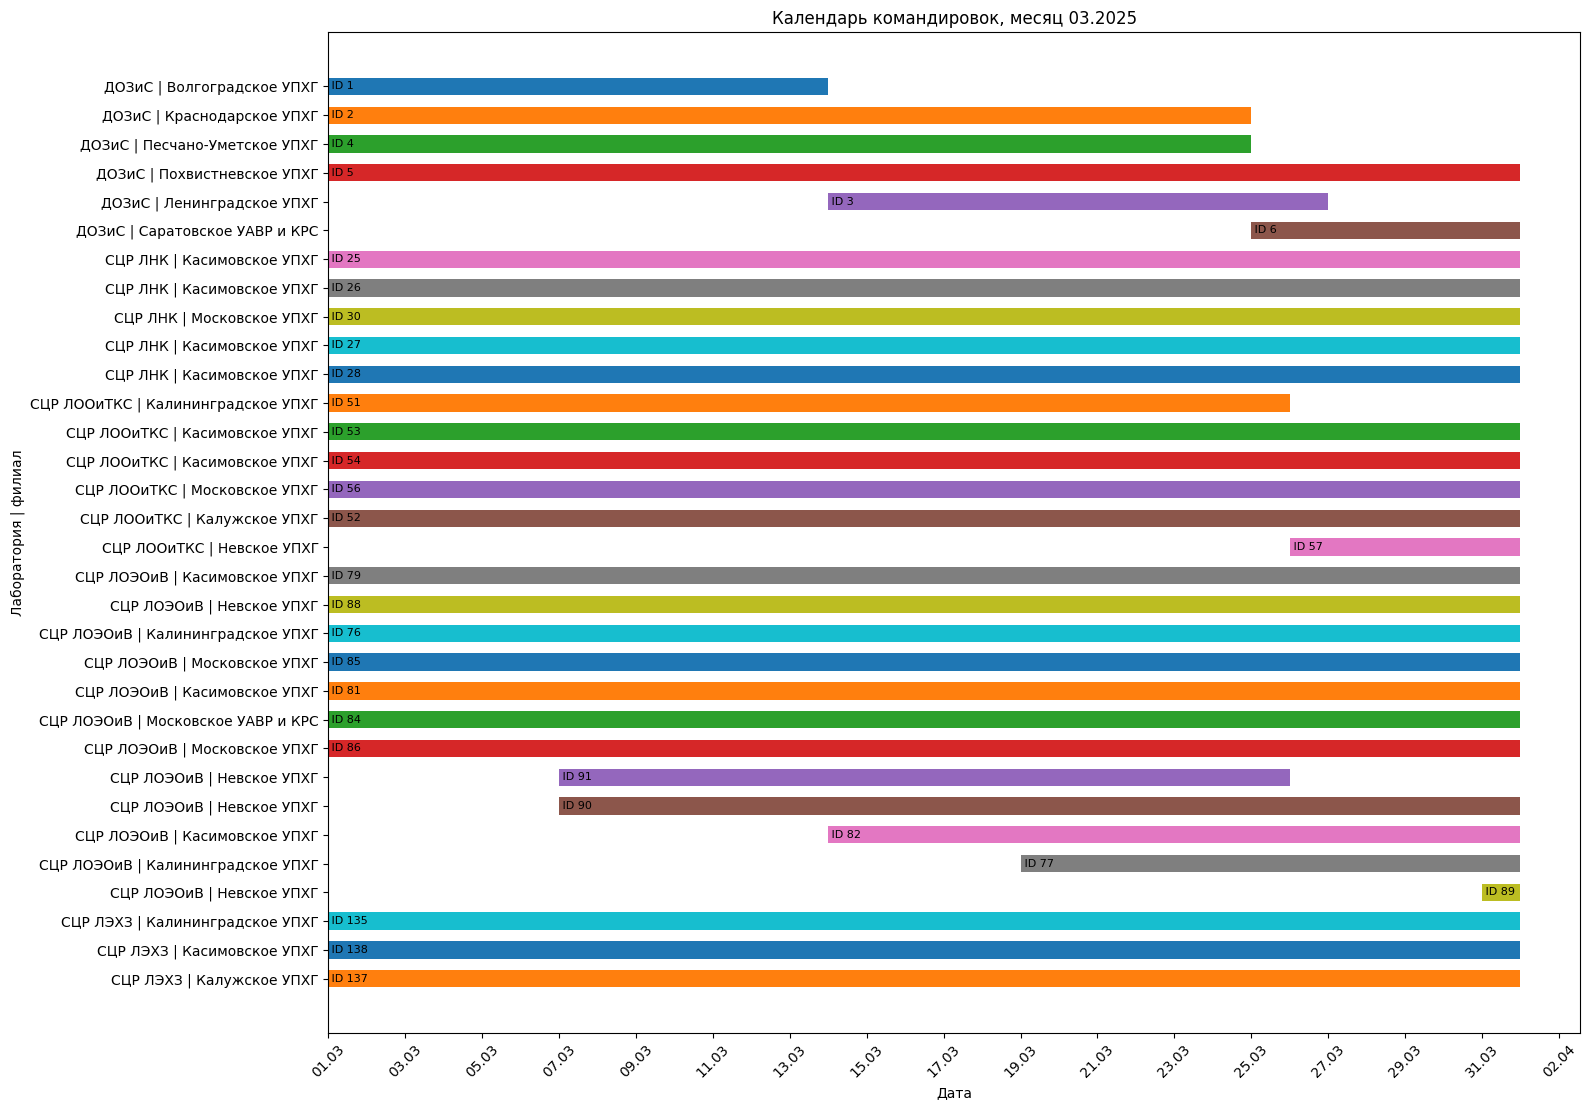

In [160]:
active_days = []

for _, row in calendar_plot.iterrows():
    for d in pd.date_range(row["start"], row["end"], freq="D"):
        active_days.append({
            "date": d,
            "month": d.month,
            "lab": row["lab"],
            "trip_id": row["trip_id"]
        })

active_days = pd.DataFrame(active_days)

if len(active_days) == 0:
    print("В календаре нет активных командировок.")
else:
    month_num = int(active_days["month"].value_counts().sort_values(ascending=False).index[0])
    year_num = 2025

    period_start = pd.Timestamp(year=year_num, month=month_num, day=1)
    period_end = period_start + pd.offsets.MonthEnd(1)

    gantt_df = calendar_plot[
        (calendar_plot["end"] >= period_start) &
        (calendar_plot["start"] <= period_end)
    ].copy()

    gantt_df["plot_start"] = gantt_df["start"].apply(lambda x: max(x, period_start))
    gantt_df["plot_end"] = gantt_df["end"].apply(lambda x: min(x, period_end))
    gantt_df["duration"] = (gantt_df["plot_end"] - gantt_df["plot_start"]).dt.days + 1

    gantt_df = gantt_df.sort_values(["lab", "plot_start", "plot_end"]).reset_index(drop=True)
    gantt_df["label"] = gantt_df["lab"].astype(str) + " | " + gantt_df["branch"].astype(str)

    print("Выбран месяц:", month_num)
    print("Командировок в месяце:", len(gantt_df))

    fig_height = max(6, 0.35 * len(gantt_df))
    fig, ax = plt.subplots(figsize=(16, fig_height))

    for i, row in gantt_df.iterrows():
        ax.barh(
            y=i,
            width=row["duration"],
            left=row["plot_start"],
            height=0.6
        )
        ax.text(
            row["plot_start"],
            i,
            f" ID {row['trip_id']}",
            va="center",
            fontsize=8
        )

    ax.set_yticks(range(len(gantt_df)))
    ax.set_yticklabels(gantt_df["label"])
    ax.invert_yaxis()

    ax.set_title(f"Календарь командировок, месяц {month_num:02d}.{year_num}")
    ax.set_xlabel("Дата")
    ax.set_ylabel("Лаборатория | филиал")

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

по лабе

Выбранная лаборатория: СЦР ЛОЭОиВ
Командировок лаборатории в месяце: 12


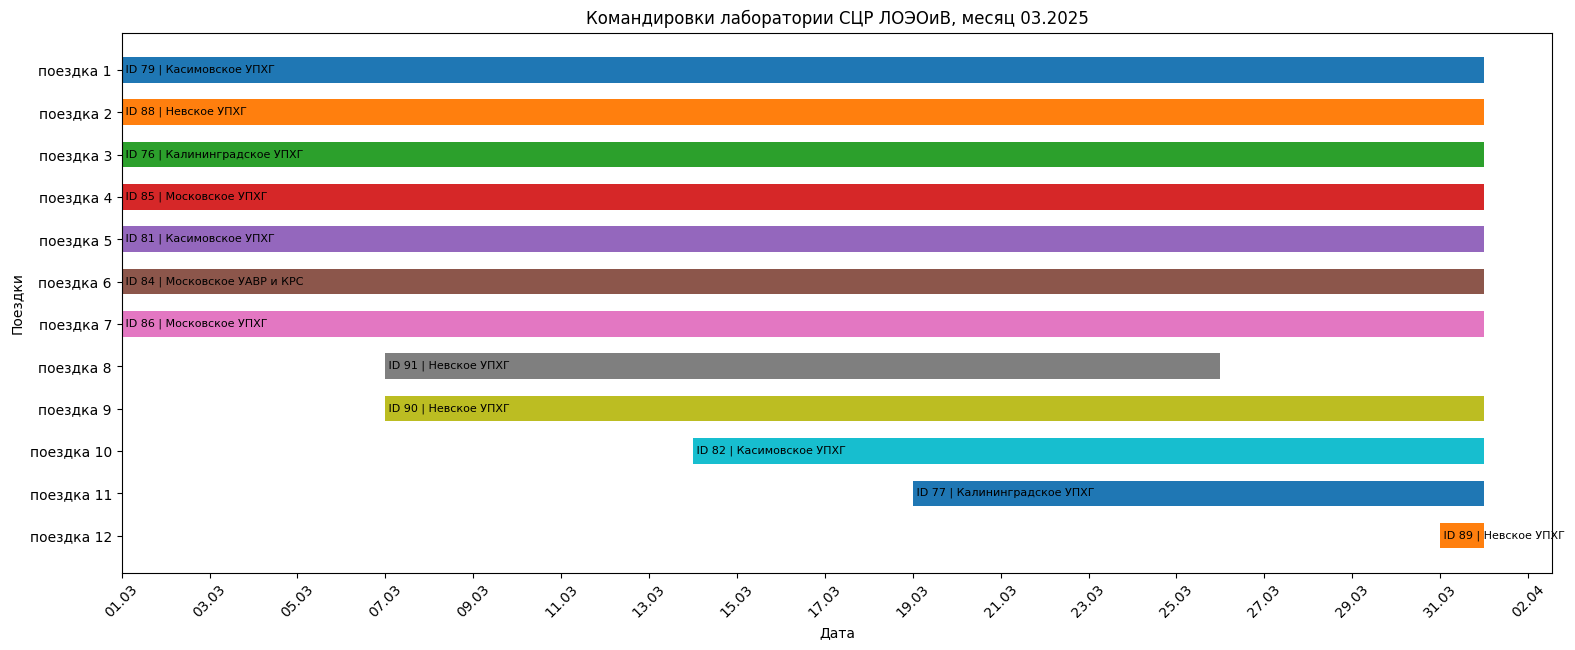

In [161]:
if len(gantt_df) == 0:
    print("В выбранном месяце нет командировок.")
else:
    selected_lab = gantt_df["lab"].value_counts().index[0]

    gantt_lab = gantt_df[gantt_df["lab"] == selected_lab].copy().reset_index(drop=True)

    print("Выбранная лаборатория:", selected_lab)
    print("Командировок лаборатории в месяце:", len(gantt_lab))

    fig_height = max(4, 0.55 * len(gantt_lab))
    fig, ax = plt.subplots(figsize=(16, fig_height))

    for i, row in gantt_lab.iterrows():
        ax.barh(
            y=i,
            width=row["duration"],
            left=row["plot_start"],
            height=0.6
        )
        ax.text(
            row["plot_start"],
            i,
            f" ID {row['trip_id']} | {row['branch']}",
            va="center",
            fontsize=8
        )

    ax.set_yticks(range(len(gantt_lab)))
    ax.set_yticklabels([f"поездка {i + 1}" for i in range(len(gantt_lab))])
    ax.invert_yaxis()

    ax.set_title(f"Командировки лаборатории {selected_lab}, месяц {month_num:02d}.{year_num}")
    ax.set_xlabel("Дата")
    ax.set_ylabel("Поездки")

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

### сколько командировок идет одновременно по дням

In [162]:
# active_rows = []

# for _, row in calendar_plot.iterrows():
#     local_start = max(row["start"], period_start)
#     local_end = min(row["end"], period_end)

#     if local_start <= local_end:
#         for d in pd.date_range(local_start, local_end, freq="D"):
#             active_rows.append({
#                 "date": d,
#                 "lab": row["lab"]
#             })

# active_df = pd.DataFrame(active_rows)

# if len(active_df) == 0:
#     print("В выбранном месяце нет активных командировок.")
# else:
#     active_daily = (
#         active_df
#         .groupby(["date", "lab"])
#         .size()
#         .reset_index(name="active_trips")
#         .sort_values(["lab", "date"])
#     )

#     fig, ax = plt.subplots(figsize=(16, 7))

#     for lab_name, grp in active_daily.groupby("lab"):
#         ax.plot(grp["date"], grp["active_trips"], marker="o", label=lab_name)

#     ax.set_title(f"Одновременные командировки по дням, месяц {month_num:02d}.{year_num}")
#     ax.set_xlabel("Дата")
#     ax.set_ylabel("Число активных командировок")

#     ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
#     ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
#     plt.xticks(rotation=45)

#     plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
#     plt.tight_layout()
#     plt.show()

### Табличный календарь по выбранной лаборатории

In [163]:
lab_calendar_rows = []

for _, row in calendar_plot[calendar_plot["lab"] == selected_lab].iterrows():
    local_start = max(row["start"], period_start)
    local_end = min(row["end"], period_end)

    if local_start <= local_end:
        for d in pd.date_range(local_start, local_end, freq="D"):
            lab_calendar_rows.append({
                "date": d,
                "trip_id": row["trip_id"],
                "lab": row["lab"],
                "branch": row["branch"],
                "season": row["season"]
            })

if len(lab_calendar_rows) == 0:
    print("У выбранной лаборатории нет командировок в этом месяце.")
else:
    lab_calendar = (
        pd.DataFrame(lab_calendar_rows)
        .sort_values(["date", "trip_id"])
        .reset_index(drop=True)
    )

    display(lab_calendar.head(80))

,date,trip_id,lab,branch,season
0,2025-03-01,76,СЦР ЛОЭОиВ,Калининградское УПХГ,Весна
1,2025-03-01,79,СЦР ЛОЭОиВ,Касимовское УПХГ,Весна
2,2025-03-01,81,СЦР ЛОЭОиВ,Касимовское УПХГ,Весна
3,2025-03-01,84,СЦР ЛОЭОиВ,Московское УАВР и КРС,Весна
4,2025-03-01,85,СЦР ЛОЭОиВ,Московское УПХГ,Весна
...,...,...,...,...,...
75,2025-03-10,88,СЦР ЛОЭОиВ,Невское УПХГ,Весна
76,2025-03-10,90,СЦР ЛОЭОиВ,Невское УПХГ,Весна
77,2025-03-10,91,СЦР ЛОЭОиВ,Невское УПХГ,Весна
78,2025-03-11,76,СЦР ЛОЭОиВ,Калининградское УПХГ,Весна


<a id='7-настоящая-календарная-модель'></a>
<div style="background-color: pink; padding: 15px; border-radius: 5px;">
<h1 style="color: black;">2. Календарное CP-SAT-расширение базовой модели на множестве seed- и альтернативных календарных опций</h1>
</div>

[Вернуться к содержанию](#задачи)


Модель 2 получила чуть более широкий набор вариантов, чем финальное решение модели 1, и CP-SAT выбрал две более дешевые альтернативы

сначала генерируем разумные варианты командировок, а потом модель выбирает: какую командировку взять и в какой день начать.

Этот блок оставлен отдельно от модели 1. Логика более близка к промышленным задачам crew scheduling / crew pairing: сначала формируются допустимые кандидатные командировки, затем CP-SAT выбирает набор кандидатов и одновременно назначает им даты. Ограничения покрытия требуют, чтобы каждая работа была выбрана ровно один раз, а ресурсные ограничения не позволяют превысить дневную численность и фонд часов лабораторий.

Блок можно запускать после подготовки данных и формирования `trip_df`, `valid_trip`, `trip_info`, `cam_hours`, `branch_rates`, `F`!!!


У нас есть кандидат o, где: o = выбранная командировка + лаборатория + сезон + дата начала

Для каждого кандидата заранее известно:

- список работ внутри командировки
- лаборатория
- филиал
- сезон
- дата начала
- дата окончания
- полевые дни
- полевые часы
- стоимость труда
- стоимость командировки
- стоимость камералки

Переменная:

- y_o = 1, если календарный вариант командировки o выбран
- y_o = 0, иначе

Целевая функция:

- min сумма стоимости выбранных календарных вариантов

Ограничения:

1. Каждая работа покрыта ровно один раз.
2. В каждый день лаборатория не может отправить в командировки больше людей, чем есть в штате.
3. Командировка может начинаться только в допустимый сезон.
4. Работа может входить только в командировки допустимой лаборатории.
5. Камеральные часы лаборатории не превышают доступный фонд.
6. Полевые + камеральные часы по лаборатории/сезону не превышают фонд.

### 7.1. Подключение CP-SAT и параметры календарной модели


In [164]:
RUN_TRUE_CALENDAR_MODEL = True

TRUE_CALENDAR_TIME_LIMIT = 900
TRUE_CALENDAR_WORKERS = 16
TRUE_OBJECTIVE_SCALE = 1
TRUE_HOURS_SCALE = 1000

TRUE_USE_MODEL1_CALENDAR_SEED = True
TRUE_ADD_ALTERNATIVE_CANDIDATES = True
TRUE_ALT_MULTI_PER_WORK = 4
TRUE_ALT_MAX_BASE_CANDIDATES = 900
TRUE_ALT_MAX_STARTS_PER_ASSIGNMENT = 6
TRUE_MAX_TOTAL_OPTIONS = 20000

import sys
import subprocess

In [165]:
try:
    from ortools.sat.python import cp_model
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "ortools"])
    from ortools.sat.python import cp_model

required_objects = [
    "I", "J", "Q", "trip_df", "trip_info", "valid_trip", "valid_cam",
    "t5_work", "branch_rates", "s", "cam_hours", "F",
    "work_calendar", "season_dates", "lab_staff", "calendar_trips", "field_daily"
]

missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(f"Не хватает объектов для запуска модели 2: {missing_objects}")

print("OR-Tools CP-SAT готов.")
print("Модель 2 будет строиться как set-partitioning по календарным опциям командировок.")

OR-Tools CP-SAT готов.
Модель 2 будет строиться как set-partitioning по календарным опциям командировок.


### 7.2. Служебные функции


In [166]:
def normalize_work_ids_model2(x):
    if isinstance(x, (list, tuple, set)):
        return tuple(sorted(int(v) for v in x))
    if pd.isna(x):
        return tuple()
    if isinstance(x, str):
        x = x.strip()
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, (list, tuple, set)):
                return tuple(sorted(int(v) for v in parsed))
            return (int(parsed),)
        except Exception:
            return tuple(sorted(int(v.strip()) for v in x.replace(";", ",").split(",") if v.strip()))
    return (int(x),)


def sample_start_positions(n_dates, need_days, max_starts):
    last = int(n_dates) - int(need_days)
    if last < 0:
        return []
    if last == 0:
        return [0]
    if last + 1 <= max_starts:
        return list(range(last + 1))
    positions = np.linspace(0, last, max_starts)
    return sorted(set(int(round(x)) for x in positions))


def calc_trip_cost_model2(filial, field_days):
    daily_rate = float(branch_rates.loc[filial, "ставка_суточных_в_день"])
    hotel_rate = float(branch_rates.loc[filial, "ставка_проживания_за_ночь"])
    road_rate = float(branch_rates.loc[filial, "проезд"])
    return (
        daily_rate * (int(field_days) + ROAD_DAYS_PER_TRIP_CAL)
        + hotel_rate * int(field_days)
        + road_rate
    )


def make_uniform_field_day_hours(dates, field_hours):
    dates = [pd.Timestamp(d) for d in dates]
    if len(dates) == 0:
        return tuple()
    per_day = float(field_hours) / len(dates)
    return tuple((d, per_day) for d in dates)


def field_day_hours_from_field_daily(calendar_trip_id, fallback_start, fallback_end, fallback_hours):
    part = field_daily[field_daily["calendar_trip_id"].astype(int) == int(calendar_trip_id)].copy()

    if not part.empty:
        part["date"] = pd.to_datetime(part["date"])
        part = part.sort_values("date")
        return tuple(
            (pd.Timestamp(r["date"]), float(r["полевые_часы_день"]))
            for _, r in part.iterrows()
        )

    fallback_dates = pd.date_range(pd.Timestamp(fallback_start), pd.Timestamp(fallback_end), freq="D")
    return make_uniform_field_day_hours(fallback_dates, fallback_hours)


def option_key(row):
    work_key = ",".join(map(str, row["work_ids"]))
    date_key = ",".join(pd.Timestamp(d).strftime("%Y-%m-%d") for d, _ in row["field_day_hours"])
    return f"{row['лаборатория']}|{row['сезон']}|{row['филиал']}|{work_key}|{date_key}"

### 7.3. Формирование опций из уже готовой календаризации модели 1


In [167]:
true_options = []
option_id = 0

if TRUE_USE_MODEL1_CALENDAR_SEED:
    for _, row in calendar_trips.iterrows():
        lab = row["лаборатория"]
        season = row["сезон"]
        filial = row["филиал"]
        works = normalize_work_ids_model2(row["work_ids"])
        field_hours = float(row["полевые_часы"])
        calendar_trip_id = int(row["calendar_trip_id"])

        field_day_hours = field_day_hours_from_field_daily(
            calendar_trip_id=calendar_trip_id,
            fallback_start=row["дата_начала_поля"],
            fallback_end=row["дата_окончания_поля"],
            fallback_hours=field_hours
        )

        field_days = len(field_day_hours)
        if field_days == 0:
            continue

        trip_rub = calc_trip_cost_model2(filial, field_days)
        field_labor_rub = float(s[lab]) * field_hours

        option_id += 1
        true_options.append({
            "option_id": option_id,
            "source": "seed_model1_calendar",
            "base_trip_id": calendar_trip_id,
            "лаборатория": lab,
            "сезон": season,
            "филиал": filial,
            "work_ids": works,
            "число_работ": len(works),
            "полевые_часы": field_hours,
            "полевые_дни": field_days,
            "дата_начала_поля": min(d for d, _ in field_day_hours),
            "дата_окончания_поля": max(d for d, _ in field_day_hours),
            "field_day_hours": field_day_hours,
            "труд_полевой_руб": field_labor_rub,
            "командировочные_руб": trip_rub,
            "стоимость_поля_и_командировки_руб": field_labor_rub + trip_rub
        })

print("seed-опций из календаризации модели 1:", len(true_options))


seed-опций из календаризации модели 1: 150


### 7.4. Добавление альтернативных календарных опций из кандидатных групп модели 1


In [168]:
if TRUE_ADD_ALTERNATIVE_CANDIDATES:
    trip_df_alt = trip_df.copy()
    trip_df_alt["work_ids"] = trip_df_alt["work_ids"].apply(normalize_work_ids_model2)

    true_multi = trip_df_alt[trip_df_alt["group_size"] > 1].copy()

    if not true_multi.empty:
        expanded = (
            true_multi[["trip_id", "work_ids", "экономия_на_группировке"]]
            .explode("work_ids")
            .rename(columns={"work_ids": "id_работы"})
        )
        expanded["rank_for_work"] = (
            expanded
            .groupby("id_работы")["экономия_на_группировке"]
            .rank(method="first", ascending=False)
        )

        keep_ids = set(
            expanded.loc[
                expanded["rank_for_work"] <= TRUE_ALT_MULTI_PER_WORK,
                "trip_id"
            ].astype(int)
        )

        alt_base = (
            true_multi[true_multi["trip_id"].astype(int).isin(keep_ids)]
            .sort_values("экономия_на_группировке", ascending=False)
            .head(TRUE_ALT_MAX_BASE_CANDIDATES)
            .copy()
        )
    else:
        alt_base = pd.DataFrame(columns=trip_df_alt.columns)

    alt_ids = set(alt_base["trip_id"].astype(int).tolist())
    valid_trip_alt = pd.DataFrame(valid_trip, columns=["trip_id", "лаборатория", "сезон"])
    valid_trip_alt = valid_trip_alt[valid_trip_alt["trip_id"].astype(int).isin(alt_ids)].copy()

    alt_info = alt_base.set_index("trip_id").to_dict(orient="index")
    added_alt = 0

    for _, assign in valid_trip_alt.iterrows():
        if len(true_options) >= TRUE_MAX_TOTAL_OPTIONS:
            break

        g = int(assign["trip_id"])
        lab = assign["лаборатория"]
        season = assign["сезон"]

        if lab not in s:
            continue

        info = alt_info.get(g)
        if info is None:
            continue

        works = normalize_work_ids_model2(info["work_ids"])
        filial = info["филиал"]
        field_hours = float(info["полевые_часы_группы"])
        field_days = int(max(1, math.ceil(float(info["полевые_дни_группы"]))))

        dates = season_dates.get(season, [])
        start_positions = sample_start_positions(len(dates), field_days, TRUE_ALT_MAX_STARTS_PER_ASSIGNMENT)
        if not start_positions:
            continue

        trip_rub = calc_trip_cost_model2(filial, field_days)
        field_labor_rub = float(s[lab]) * field_hours

        for start_pos in start_positions:
            if len(true_options) >= TRUE_MAX_TOTAL_OPTIONS:
                break

            block = dates[start_pos:start_pos + field_days]
            field_day_hours = make_uniform_field_day_hours(block, field_hours)

            option_id += 1
            true_options.append({
                "option_id": option_id,
                "source": "alternative_trip_candidate",
                "base_trip_id": g,
                "лаборатория": lab,
                "сезон": season,
                "филиал": filial,
                "work_ids": works,
                "число_работ": len(works),
                "полевые_часы": field_hours,
                "полевые_дни": field_days,
                "дата_начала_поля": block[0],
                "дата_окончания_поля": block[-1],
                "field_day_hours": field_day_hours,
                "труд_полевой_руб": field_labor_rub,
                "командировочные_руб": trip_rub,
                "стоимость_поля_и_командировки_руб": field_labor_rub + trip_rub
            })
            added_alt += 1

    print("альтернативных базовых групп:", len(alt_base))
    print("альтернативных календарных опций добавлено:", added_alt)

альтернативных базовых групп: 900
альтернативных календарных опций добавлено: 16464


In [169]:
true_options_df = pd.DataFrame(true_options)

if true_options_df.empty:
    raise RuntimeError("Не сформировано ни одной календарной опции.")

In [170]:
true_options_df["option_key"] = true_options_df.apply(option_key, axis=1)
true_options_df = (
    true_options_df
    .sort_values(["source", "стоимость_поля_и_командировки_руб"], ascending=[False, True])
    .drop_duplicates("option_key", keep="first")
    .reset_index(drop=True)
)
true_options_df["option_id"] = np.arange(1, len(true_options_df) + 1)

print("итого календарных опций:", len(true_options_df))
display(true_options_df.groupby("source").size().reset_index(name="число_опций"))

итого календарных опций: 16612


,source,число_опций
0,alternative_trip_candidate,16462
1,seed_model1_calendar,150


In [171]:
coverage_rows = []
for i in I:
    cnt = int(true_options_df["work_ids"].apply(lambda ws: int(i) in ws).sum())
    coverage_rows.append({"work_id": int(i), "число_опций": cnt})

true_coverage = pd.DataFrame(coverage_rows)
missing_works_model2 = true_coverage[true_coverage["число_опций"] == 0].copy()

print("работ всего:", len(I))
print("работ без календарных опций:", len(missing_works_model2))

if len(missing_works_model2) > 0:
    display(missing_works_model2.head(30))
    raise RuntimeError("Есть работы без календарных опций. CP-SAT будет infeasible.")

работ всего: 1290
работ без календарных опций: 0


### 7.5. Построение и решение CP-SAT модели

In [172]:
model_cal = cp_model.CpModel()

x_true = {
    int(row["option_id"]): model_cal.NewBoolVar(f"x_true_{int(row['option_id'])}")
    for _, row in true_options_df.iterrows()
}

z_true = {
    (int(i), str(j), str(q)): model_cal.NewBoolVar(f"z_true_{int(i)}_{str(j)}_{str(q)}")
    for i, j, q in valid_cam
    if str(j) in s
}

In [173]:
option_ids_by_work = {int(i): [] for i in I}
option_ids_by_work_lab = defaultdict(list)

for _, row in true_options_df.iterrows():
    oid = int(row["option_id"])
    lab = str(row["лаборатория"])
    for w in row["work_ids"]:
        w = int(w)
        option_ids_by_work[w].append(oid)
        option_ids_by_work_lab[(w, lab)].append(oid)

for work_id in I:
    option_ids = option_ids_by_work[int(work_id)]
    model_cal.Add(sum(x_true[oid] for oid in option_ids) == 1)

cam_ids_by_work = defaultdict(list)
cam_ids_by_work_lab = defaultdict(list)

for key in z_true:
    i, j, q = key
    cam_ids_by_work[int(i)].append(key)
    cam_ids_by_work_lab[(int(i), str(j))].append(key)

In [174]:
for work_id in I:
    keys = cam_ids_by_work[int(work_id)]
    if not keys:
        raise RuntimeError(f"Для работы {work_id} нет камеральных назначений.")
    model_cal.Add(sum(z_true[k] for k in keys) == 1)

In [175]:
for work_id in I:
    for lab in J:
        lab = str(lab)
        field_oids = option_ids_by_work_lab.get((int(work_id), lab), [])
        cam_keys = cam_ids_by_work_lab.get((int(work_id), lab), [])
        if field_oids or cam_keys:
            model_cal.Add(
                sum(x_true[oid] for oid in field_oids)
                ==
                sum(z_true[k] for k in cam_keys)
            )

In [176]:
field_day_rows = []
for _, row in true_options_df.iterrows():
    oid = int(row["option_id"])
    lab = str(row["лаборатория"])
    for d, h in row["field_day_hours"]:
        field_day_rows.append({
            "option_id": oid,
            "лаборатория": lab,
            "date": pd.Timestamp(d),
            "полевые_часы_день": float(h)
        })

field_day_options = pd.DataFrame(field_day_rows)

In [177]:
true_daily_capacity_rows = []
for lab in J:
    lab = str(lab)
    staff = int(lab_staff.get(lab, 1))
    for _, r in work_calendar.iterrows():
        true_daily_capacity_rows.append({
            "лаборатория": lab,
            "date": pd.Timestamp(r["date"]),
            "доступно_человек": staff,
            "доступно_часов": staff * float(r["часов_на_1_сотрудника_день"])
        })

true_daily_capacity = pd.DataFrame(true_daily_capacity_rows)
cap_by_lab_date = true_daily_capacity.set_index(["лаборатория", "date"]).to_dict(orient="index")

In [178]:
for (lab, d), part in field_day_options.groupby(["лаборатория", "date"]):
    cap = cap_by_lab_date.get((lab, pd.Timestamp(d)))
    if cap is None:
        continue
    model_cal.Add(
        sum(x_true[int(oid)] for oid in part["option_id"])
        <= int(cap["доступно_человек"])
    )
    model_cal.Add(
        sum(
            int(round(float(h) * TRUE_HOURS_SCALE)) * x_true[int(oid)]
            for oid, h in zip(part["option_id"], part["полевые_часы_день"])
        )
        <= int(round(float(cap["доступно_часов"]) * TRUE_HOURS_SCALE))
    )

In [179]:
for lab in J:
    lab = str(lab)
    for season in Q:
        season = str(season)
        field_part = true_options_df[
            (true_options_df["лаборатория"].astype(str) == lab)
            & (true_options_df["сезон"].astype(str) == season)
        ]
        cam_keys = [k for k in z_true if k[1] == lab and k[2] == season]

        if field_part.empty and not cam_keys:
            continue

        field_terms = [
            int(round(float(r["полевые_часы"]) * TRUE_HOURS_SCALE)) * x_true[int(r["option_id"])]
            for _, r in field_part.iterrows()
        ]
        cam_terms = [
            int(round(float(cam_hours[int(k[0])]) * TRUE_HOURS_SCALE)) * z_true[k]
            for k in cam_keys
        ]

        model_cal.Add(
            sum(field_terms) + sum(cam_terms)
            <= int(round(float(F[(lab, season)]) * TRUE_HOURS_SCALE))
        )

In [180]:
objective_terms = []
for _, row in true_options_df.iterrows():
    oid = int(row["option_id"])
    cost_int = int(round(float(row["стоимость_поля_и_командировки_руб"]) * TRUE_OBJECTIVE_SCALE))
    objective_terms.append(cost_int * x_true[oid])

for key, var in z_true.items():
    i, lab, season = key
    cost_int = int(round(float(s[lab]) * float(cam_hours[int(i)]) * TRUE_OBJECTIVE_SCALE))
    objective_terms.append(cost_int * var)

model_cal.Minimize(sum(objective_terms))

In [181]:
# Дополнительное ограничение: камеральная часть не может быть назначена
# в сезон, где нет рабочих дат после окончания соответствующей полевой части

if "CAM_AFTER_FIELD" not in globals():
    CAM_AFTER_FIELD = True

if CAM_AFTER_FIELD:
    incompatible_cam_after_field = 0

    for _, opt in true_options_df.iterrows():
        oid = int(opt["option_id"])
        lab = str(opt["лаборатория"])
        field_end = pd.Timestamp(opt["дата_окончания_поля"])

        for work_id in opt["work_ids"]:
            work_id = int(work_id)

            cam_keys = cam_ids_by_work_lab.get((work_id, lab), [])

            for cam_key in cam_keys:
                _, cam_lab, cam_season = cam_key

                dates = season_dates.get(str(cam_season), [])
                allowed_dates_after_field = [
                    pd.Timestamp(d) for d in dates
                    if pd.Timestamp(d) > field_end
                ]

                if len(allowed_dates_after_field) == 0:
                    model_cal.Add(x_true[oid] + z_true[cam_key] <= 1)
                    incompatible_cam_after_field += 1

    print(
        "Добавлено ограничений несовместимости поле/камералка по порядку:",
        incompatible_cam_after_field
    )

Добавлено ограничений несовместимости поле/камералка по порядку: 154927


In [182]:
solver_cal = cp_model.CpSolver()
solver_cal.parameters.max_time_in_seconds = TRUE_CALENDAR_TIME_LIMIT
solver_cal.parameters.num_search_workers = TRUE_CALENDAR_WORKERS
solver_cal.parameters.relative_gap_limit = 0.01
solver_cal.parameters.log_search_progress = True

status_cal = solver_cal.Solve(model_cal)


Starting CP-SAT solver v9.15.6755
Parameters: max_time_in_seconds: 900 log_search_progress: true num_search_workers: 16 relative_gap_limit: 0.01

Initial optimization model '': (model_fingerprint: 0xd19fd9def52f0bf2)
#Variables: 21'840 (#bools: 21'840 in objective) (20'179 primary variables)
  - 21'840 Booleans in [0,1]
#kLinear1: 1'012
#kLinear2: 154'929
#kLinear3: 2
#kLinearN: 5'079 (#terms: 958'590)

Starting presolve at 0.11s
  7.74e-02s  0.00e+00d  [DetectDominanceRelations] 
  6.19e-02s  0.00e+00d  [DetectDominanceRelations] 
  8.35e-01s  0.00e+00d  [PresolveToFixPoint] #num_loops=5 #num_dual_strengthening=3 
  2.93e-03s  0.00e+00d  [ExtractEncodingFromLinear] #potential_supersets=1'454 
  1.80e-02s  0.00e+00d  [DetectDuplicateColumns] 
  1.68e-02s  0.00e+00d  [DetectDuplicateConstraints] #duplicates=1'618 
[Symmetry] Graph for symmetry has 58'374 nodes and 514'019 arcs.
[Symmetry] Symmetry computation done. time: 0.0610465 dtime: 0.12154
[Symmetry] #generators: 630, average sup

In [183]:
print("status:", solver_cal.StatusName(status_cal))
if status_cal in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
    print("objective, руб.:", solver_cal.ObjectiveValue())
    print("objective, млн руб.:", solver_cal.ObjectiveValue() / 1_000_000)
else:
    print("Решение не найдено. Проверь диагностику покрытия и ограничения дневной/сезонной емкости.")

status: OPTIMAL
objective, руб.: 81226704.0
objective, млн руб.: 81.226704


In [184]:
model2_size = pd.DataFrame({
    "показатель": [
        "календарных опций",
        "камеральных назначений",
        "переменных x_true",
        "переменных z_true",
        "переменных всего",
        "ограничений всего"
    ],
    "значение": [
        len(true_options_df),
        len(z_true),
        len(x_true),
        len(z_true),
        len(model_cal.Proto().variables),
        len(model_cal.Proto().constraints)
    ]
})

display(model2_size)

,показатель,значение
0,календарных опций,16612
1,камеральных назначений,5228
2,переменных x_true,16612
3,переменных z_true,5228
4,переменных всего,21840
5,ограничений всего,161022


### 7.6. Извлечение результата модели 2

In [185]:
if status_cal in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
    selected_option_ids = [
        oid for oid, var in x_true.items()
        if solver_cal.Value(var) > 0.5
    ]

    model2_calendar_trips = (
        true_options_df[true_options_df["option_id"].isin(selected_option_ids)]
        .copy()
        .sort_values(["лаборатория", "сезон", "дата_начала_поля", "option_id"])
        .reset_index(drop=True)
    )

    selected_cam_rows = []
    for key, var in z_true.items():
        if solver_cal.Value(var) > 0.5:
            i, lab, season = key
            selected_cam_rows.append({
                "work_id": int(i),
                "лаборатория": lab,
                "сезон": season,
                "камеральные_часы": float(cam_hours[int(i)]),
                "камеральный_труд_руб": float(s[lab]) * float(cam_hours[int(i)])
            })

    model2_selected_cam = pd.DataFrame(selected_cam_rows)

    model2_field_daily_rows = []
    for _, row in model2_calendar_trips.iterrows():
        for d, h in row["field_day_hours"]:
            model2_field_daily_rows.append({
                "option_id": int(row["option_id"]),
                "base_trip_id": int(row["base_trip_id"]),
                "source": row["source"],
                "date": pd.Timestamp(d),
                "лаборатория": row["лаборатория"],
                "сезон": row["сезон"],
                "филиал": row["филиал"],
                "полевые_часы_день": float(h)
            })

    model2_field_daily = pd.DataFrame(model2_field_daily_rows)

    model2_components = pd.DataFrame([
        {
            "компонент": "полевой труд",
            "руб": model2_calendar_trips["труд_полевой_руб"].sum()
        },
        {
            "компонент": "камеральный труд",
            "руб": model2_selected_cam["камеральный_труд_руб"].sum()
        },
        {
            "компонент": "командировочные",
            "руб": model2_calendar_trips["командировочные_руб"].sum()
        }
    ])
    model2_components.loc[len(model2_components)] = {
        "компонент": "итого модель 2",
        "руб": model2_components["руб"].sum()
    }
    model2_components["млн_руб"] = model2_components["руб"] / 1_000_000
    model2_components["доля_%"] = model2_components["руб"] / model2_components.loc[
        model2_components["компонент"] == "итого модель 2", "руб"
    ].iloc[0] * 100

    model2_daily_load = (
        model2_field_daily
        .groupby(["лаборатория", "date"], as_index=False)
        .agg(
            активных_командировок=("option_id", "nunique"),
            полевые_часы=("полевые_часы_день", "sum")
        )
        .merge(true_daily_capacity, on=["лаборатория", "date"], how="left")
    )
    model2_daily_load["перегрузка_по_людям"] = (
        model2_daily_load["активных_командировок"] - model2_daily_load["доступно_человек"]
    ).clip(lower=0)
    model2_daily_load["перегрузка_по_часам"] = (
        model2_daily_load["полевые_часы"] - model2_daily_load["доступно_часов"]
    ).clip(lower=0)

    model2_summary = pd.DataFrame([{
        "status": solver_cal.StatusName(status_cal),
        "objective_руб": solver_cal.ObjectiveValue(),
        "objective_млн_руб": solver_cal.ObjectiveValue() / 1_000_000,
        "выбрано_командировок": len(model2_calendar_trips),
        "работ_в_полевой_части": int(model2_calendar_trips["work_ids"].apply(len).sum()),
        "камеральных_работ": len(model2_selected_cam),
        "дней_с_перегрузкой_людей": int((model2_daily_load["перегрузка_по_людям"] > 0).sum()),
        "дней_с_перегрузкой_часов": int((model2_daily_load["перегрузка_по_часам"] > 1e-9).sum())
    }])

    print("\nИтог модели 2:")
    display(model2_summary)
    display(model2_components)
    display(model2_calendar_trips.head(50))


Итог модели 2:


,status,objective_руб,objective_млн_руб,выбрано_командировок,работ_в_полевой_части,камеральных_работ,дней_с_перегрузкой_людей,дней_с_перегрузкой_часов
0,OPTIMAL,81226704.0,81.226704,149,1290,1290,0,0


,компонент,руб,млн_руб,доля_%
0,полевой труд,3.515944e+07,35.159443,43.285594
1,камеральный труд,3.233139e+07,32.331388,39.803911
2,командировочные,1.373583e+07,13.735831,16.910495
3,итого модель 2,8.122666e+07,81.226663,100.000000


,option_id,source,base_trip_id,лаборатория,сезон,филиал,work_ids,число_работ,полевые_часы,полевые_дни,дата_начала_поля,дата_окончания_поля,field_day_hours,труд_полевой_руб,командировочные_руб,стоимость_поля_и_командировки_руб,option_key
0,35,seed_model1_calendar,1,ДОЗиС,Весна,Волгоградское УПХГ,"(26, 30)",2,64.175478,10,2025-03-01,2025-03-13,"((2025-03-01 00:00:00, 6.4175477999999995), (2...",132788.161309,65531.220519,198319.381829,"ДОЗиС|Весна|Волгоградское УПХГ|26,30|2025-03-0..."
1,71,seed_model1_calendar,2,ДОЗиС,Весна,Краснодарское УПХГ,"(41, 42, 43, 44)",4,128.350956,17,2025-03-01,2025-03-24,"((2025-03-01 00:00:00, 0.3509559999999965), (2...",265576.322618,83557.000000,349133.322618,"ДОЗиС|Весна|Краснодарское УПХГ|41,42,43,44|202..."
2,74,seed_model1_calendar,4,ДОЗиС,Весна,Песчано-Уметское УПХГ,"(37, 38, 39, 40)",4,128.350956,17,2025-03-01,2025-03-24,"((2025-03-01 00:00:00, 0.3509559999999965), (2...",265576.322618,92209.805000,357786.127618,"ДОЗиС|Весна|Песчано-Уметское УПХГ|37,38,39,40|..."
3,24,seed_model1_calendar,3,ДОЗиС,Весна,Ленинградское УПХГ,"(8, 9)",2,64.175478,9,2025-03-14,2025-03-26,"((2025-03-14 00:00:00, 0.17547799999999825), (...",132788.161309,0.000000,132788.161309,"ДОЗиС|Весна|Ленинградское УПХГ|8,9|2025-03-14,..."
4,20,seed_model1_calendar,6,ДОЗиС,Весна,Саратовское УАВР и КРС,"(36,)",1,32.087739,5,2025-03-25,2025-03-31,"((2025-03-25 00:00:00, 0.08773899999999912), (...",66394.080655,50016.810000,116410.890655,ДОЗиС|Весна|Саратовское УАВР и КРС|36|2025-03-...
5,17,seed_model1_calendar,7,ДОЗиС,Зима,Волгоградское УПХГ,"(23,)",1,32.087739,5,2025-01-01,2025-01-07,"((2025-01-01 00:00:00, 0.08773899999999912), (...",66394.080655,45985.765974,112379.846629,"ДОЗиС|Зима|Волгоградское УПХГ|23|2025-01-01,20..."
6,25,seed_model1_calendar,8,ДОЗиС,Зима,Ленинградское УПХГ,"(7, 10)",2,64.175478,10,2025-01-01,2025-01-14,"((2025-01-01 00:00:00, 6.4175477999999995), (2...",132788.161309,0.000000,132788.161309,"ДОЗиС|Зима|Ленинградское УПХГ|7,10|2025-01-01,..."
7,55,seed_model1_calendar,13,ДОЗиС,Лето,Кущевское УПХГ,"(51, 52, 53)",3,96.263217,13,2025-06-02,2025-06-18,"((2025-06-02 00:00:00, 0.26321699999999737), (...",199182.241964,82744.740000,281926.981964,"ДОЗиС|Лето|Кущевское УПХГ|51,52,53|2025-06-02,..."
8,139,seed_model1_calendar,12,ДОЗиС,Лето,Касимовское УПХГ,"(1, 2, 3, 4, 5, 6)",6,192.526434,25,2025-06-02,2025-07-08,"((2025-06-02 00:00:00, 0.5264339999999947), (2...",398364.483928,102120.473289,500484.957217,"ДОЗиС|Лето|Касимовское УПХГ|1,2,3,4,5,6|2025-0..."
9,150,seed_model1_calendar,10,ДОЗиС,Лето,Волгоградское УПХГ,"(21, 22, 24, 25, 27, 28, 34)",7,224.614173,29,2025-06-02,2025-07-14,"((2025-06-02 00:00:00, 0.6141729999999939), (2...",464758.564582,139803.947792,604562.512374,"ДОЗиС|Лето|Волгоградское УПХГ|21,22,24,25,27,2..."


-07d  [TransformClausesToExactlyOne] #num_amos=286 #num_clauses=7 #num_checked=7 
  2.24e-03s  0.00e+00d  [DetectEncodedComplexDomains] 
  2.71e-03s  0.00e+00d  [FindAlmostIdenticalLinearConstraints] 
  2.40e-03s  5.35e-03d  [FindBigAtMostOneAndLinearOverlap] 
  6.49e-04s  2.62e-03d  [FindBigVerticalLinearOverlap] 
  2.66e-03s  1.08e-04d  [FindBigHorizontalLinearOverlap] #blocks=1 #saved_nz=123 #linears=20 
  2.52e-03s  1.70e-07d  [MergeClauses] 
  1.44e-02s  0.00e+00d  [DetectDominanceRelations] 
  1.44e-02s  0.00e+00d  [DetectDominanceRelations] 
  5.20e-02s  0.00e+00d  [PresolveToFixPoint] #num_loops=4 #num_dual_strengthening=3 
  1.45e-02s  0.00e+00d  [DetectDominanceRelations] 
  2.61e-02s  0.00e+00d  [PresolveToFixPoint] #num_loops=1 #num_dual_strengthening=1 
  2.43e-03s  0.00e+00d  [DetectDuplicateColumns] 
  2.22e-03s  0.00e+00d  [DetectDuplicateConstraints] 
[Symmetry] Graph for symmetry has 25'071 nodes and 7'233 arcs.
[Symmetry] Symmetry computation done. time: 0.00547528 d

In [216]:
# 7.7. Экспорт результата модели 2

if status_cal in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
    OUT_TRUE_CALENDAR = Path("model2_true_calendar_cp_sat.xlsx")

    export_options = true_options_df.drop(columns=["field_day_hours"], errors="ignore").copy()
    export_selected = model2_calendar_trips.drop(columns=["field_day_hours"], errors="ignore").copy()

    for df in [export_options, export_selected]:
        if "work_ids" in df.columns:
            df["work_ids"] = df["work_ids"].astype(str)

    with pd.ExcelWriter(OUT_TRUE_CALENDAR, engine="openpyxl") as writer:
        model2_summary.to_excel(writer, sheet_name="итог", index=False)
        model2_components.to_excel(writer, sheet_name="компоненты", index=False)
        export_selected.to_excel(writer, sheet_name="выбранные_командировки", index=False)
        model2_selected_cam.to_excel(writer, sheet_name="камеральные_назначения", index=False)
        model2_field_daily.to_excel(writer, sheet_name="полевые_по_дням", index=False)
        model2_daily_load.to_excel(writer, sheet_name="дневная_загрузка", index=False)
        true_coverage.to_excel(writer, sheet_name="покрытие_работ", index=False)
        export_options.to_excel(writer, sheet_name="все_кандидатные_опции", index=False)

    print("Сохранено:", OUT_TRUE_CALENDAR.resolve())

Exception ignored in: <function ZipFile.__del__ at 0x7f925c5c2680>
Traceback (most recent call last):
  File "/usr/lib/python3.10/zipfile.py", line 1847, in __del__
    self.close()
  File "/usr/lib/python3.10/zipfile.py", line 1864, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file


Сохранено: /root/diplom/model2_true_calendar_cp_sat.xlsx


In [217]:
# Финальная проверка и экспорт результатов модели 2

if status_cal in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
    print("Модель 2 решена.")
    print("Статус:", solver_cal.StatusName(status_cal))
    print("Стоимость модели 2, млн руб.:", round(solver_cal.ObjectiveValue() / 1_000_000, 3))
    
    display(model2_summary)
    display(model2_components)

    print("Проверка покрытия:")
    print("работ в плане:", len(I))
    print("работ в полевой части модели 2:", int(model2_calendar_trips["work_ids"].apply(len).sum()))
    print("камеральных работ модели 2:", len(model2_selected_cam))
    print("дней с перегрузкой людей:", int((model2_daily_load["перегрузка_по_людям"] > 0).sum()))
    print("дней с перегрузкой часов:", int((model2_daily_load["перегрузка_по_часам"] > 1e-9).sum()))

Модель 2 решена.
Статус: OPTIMAL
Стоимость модели 2, млн руб.: 81.227


,status,objective_руб,objective_млн_руб,выбрано_командировок,работ_в_полевой_части,камеральных_работ,дней_с_перегрузкой_людей,дней_с_перегрузкой_часов
0,OPTIMAL,81226704.0,81.226704,149,1290,1290,0,0


,компонент,руб,млн_руб,доля_%
0,полевой труд,3.515944e+07,35.159443,43.285594
1,камеральный труд,3.233139e+07,32.331388,39.803911
2,командировочные,1.373583e+07,13.735831,16.910495
3,итого модель 2,8.122666e+07,81.226663,100.000000


Проверка покрытия:
работ в плане: 1290
работ в полевой части модели 2: 1290
камеральных работ модели 2: 1290
дней с перегрузкой людей: 0
дней с перегрузкой часов: 0


In [229]:
# ПРОВЕРКА

In [230]:
print("Статус:", solver_cal.StatusName(status_cal))
print("Objective solver, руб.:", solver_cal.ObjectiveValue())
print("Objective solver, млн руб.:", solver_cal.ObjectiveValue() / 1_000_000)

print("\nmodel2_summary:")
display(model2_summary)

print("\nmodel2_components:")
display(model2_components)

print("\nСумма компонент, руб.:", model2_components.loc[
    model2_components["компонент"] != "итого модель 2", "руб"
].sum())

print("\nИтого из components, руб.:", model2_components.loc[
    model2_components["компонент"] == "итого модель 2", "руб"
].iloc[0])

print("\nКомандировок:", len(model2_calendar_trips))
print("Работ в поле:", int(model2_calendar_trips["work_ids"].apply(len).sum()))
print("Камеральных работ:", len(model2_selected_cam))
print("Дней с перегрузкой людей:", int((model2_daily_load["перегрузка_по_людям"] > 0).sum()))
print("Дней с перегрузкой часов:", int((model2_daily_load["перегрузка_по_часам"] > 1e-9).sum()))

Статус: OPTIMAL
Objective solver, руб.: 81226704.0
Objective solver, млн руб.: 81.226704

model2_summary:


,status,objective_руб,objective_млн_руб,выбрано_командировок,работ_в_полевой_части,камеральных_работ,дней_с_перегрузкой_людей,дней_с_перегрузкой_часов
0,OPTIMAL,81226704.0,81.226704,149,1290,1290,0,0



model2_components:


,компонент,руб,млн_руб,доля_%
0,полевой труд,3.515944e+07,35.159443,43.285594
1,камеральный труд,3.233139e+07,32.331388,39.803911
2,командировочные,1.373583e+07,13.735831,16.910495
3,итого модель 2,8.122666e+07,81.226663,100.000000



Сумма компонент, руб.: 81226662.53603533

Итого из components, руб.: 81226662.53603533

Командировок: 149
Работ в поле: 1290
Камеральных работ: 1290
Дней с перегрузкой людей: 0
Дней с перегрузкой часов: 0


In [218]:
# Диагностика: почему модель 2 дешевле модели 1

model1_total = float(model1_components.loc[
    model1_components["компонент"].eq("итого модель"),
    "руб"
].iloc[0])

model2_total = float(model2_components.loc[
    model2_components["компонент"].eq("итого модель 2"),
    "руб"
].iloc[0])

print("Модель 1, руб.:", model1_total)
print("Модель 2, руб.:", model2_total)
print("Разница М1 - М2, руб.:", model1_total - model2_total)
print("Разница М1 - М2, млн руб.:", (model1_total - model2_total) / 1_000_000)

print("\nИсточники выбранных календарных опций модели 2:")
display(
    model2_calendar_trips
    .groupby("source", as_index=False)
    .agg(
        командировок=("option_id", "count"),
        работ=("work_ids", lambda x: sum(len(v) for v in x)),
        командировочные_руб=("командировочные_руб", "sum"),
        полевой_труд_руб=("труд_полевой_руб", "sum")
    )
)

compare_components = pd.concat([
    model1_components[["компонент", "руб"]].assign(модель="Модель 1"),
    model2_components[["компонент", "руб"]].assign(модель="Модель 2")
], ignore_index=True)

compare_components["компонент_норм"] = compare_components["компонент"].replace({
    "командировочные итого": "командировочные",
    "итого модель": "итого",
    "итого модель 2": "итого"
})

display(
    compare_components
    .pivot_table(
        index="компонент_норм",
        columns="модель",
        values="руб",
        aggfunc="sum"
    )
    .assign(
        разница_М1_минус_М2=lambda x: x.get("Модель 1", 0) - x.get("Модель 2", 0)
    )
)

Модель 1, руб.: 81407699.05428053
Модель 2, руб.: 81226662.53603533
Разница М1 - М2, руб.: 181036.51824520528
Разница М1 - М2, млн руб.: 0.18103651824520528

Источники выбранных календарных опций модели 2:


,source,командировок,работ,командировочные_руб,полевой_труд_руб
0,alternative_trip_candidate,3,19,3.392296e+05,1.101123e+06
1,seed_model1_calendar,146,1271,1.339660e+07,3.405832e+07


модель,Модель 1,Модель 2,разница_М1_минус_М2
компонент_норм,,,
итого,8.140770e+07,8.122666e+07,1.810365e+05
камеральный труд,3.233139e+07,3.233139e+07,3.464520e-07
командировочные,1.391687e+07,1.373583e+07,1.810365e+05
полевой труд,3.515944e+07,3.515944e+07,0.000000e+00
проезд,2.217905e+06,NaN,NaN
проживание,1.005826e+07,NaN,NaN
суточные,1.640700e+06,NaN,NaN


In [219]:
display(model2_summary)
display(model2_components)

,status,objective_руб,objective_млн_руб,выбрано_командировок,работ_в_полевой_части,камеральных_работ,дней_с_перегрузкой_людей,дней_с_перегрузкой_часов
0,OPTIMAL,81226704.0,81.226704,149,1290,1290,0,0


,компонент,руб,млн_руб,доля_%
0,полевой труд,3.515944e+07,35.159443,43.285594
1,камеральный труд,3.233139e+07,32.331388,39.803911
2,командировочные,1.373583e+07,13.735831,16.910495
3,итого модель 2,8.122666e+07,81.226663,100.000000


модель,Модель 1,Модель 2
компонент,,
Полевой труд,35.159443,35.159443
Камеральный труд,32.331388,32.331388
Командировочные,13.916868,13.735831
Итого,81.407699,81.226663


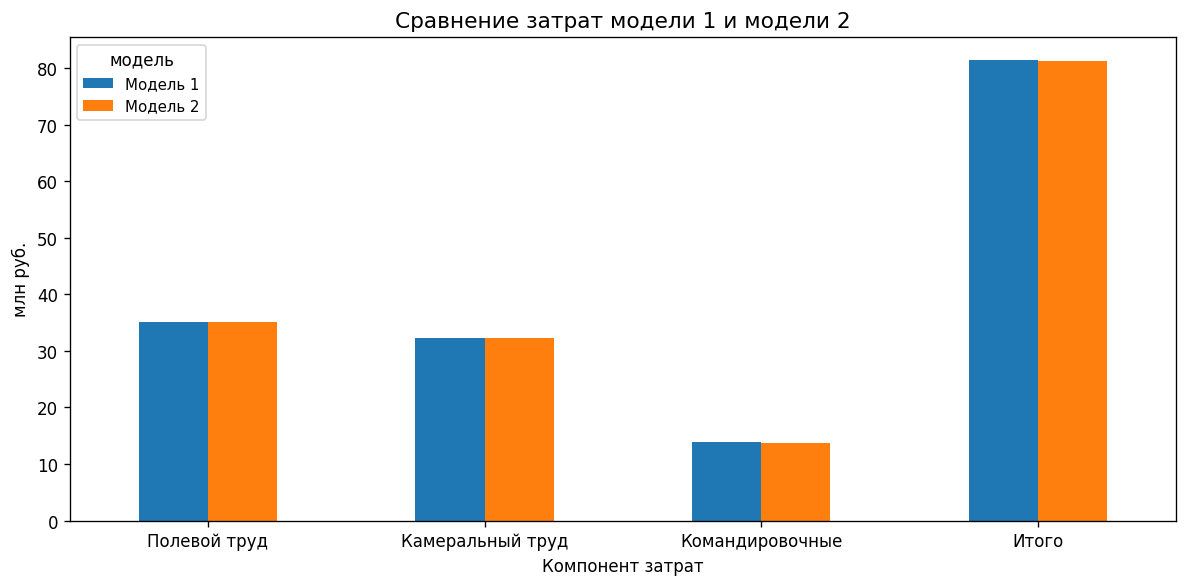

In [220]:
def normalize_component_name(x):
    if x in ["полевой труд"]:
        return "Полевой труд"
    if x in ["камеральный труд"]:
        return "Камеральный труд"
    if x in ["командировочные", "командировочные итого"]:
        return "Командировочные"
    if x in ["итого модель", "итого модель 2"]:
        return "Итого"
    return x

m1_plot = model1_components[["компонент", "млн_руб"]].copy()
m1_plot["модель"] = "Модель 1"
m1_plot["компонент"] = m1_plot["компонент"].apply(normalize_component_name)

m2_plot = model2_components[["компонент", "млн_руб"]].copy()
m2_plot["модель"] = "Модель 2"
m2_plot["компонент"] = m2_plot["компонент"].apply(normalize_component_name)

cost_compare = pd.concat([m1_plot, m2_plot], ignore_index=True)

cost_compare_pivot = (
    cost_compare
    .pivot_table(index="компонент", columns="модель", values="млн_руб", aggfunc="sum")
    .loc[["Полевой труд", "Камеральный труд", "Командировочные", "Итого"]]
)

display(cost_compare_pivot)

ax = cost_compare_pivot.plot(kind="bar", figsize=(10, 5))
ax.set_title("Сравнение затрат модели 1 и модели 2")
ax.set_xlabel("Компонент затрат")
ax.set_ylabel("млн руб.")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Структура затрат модели 2

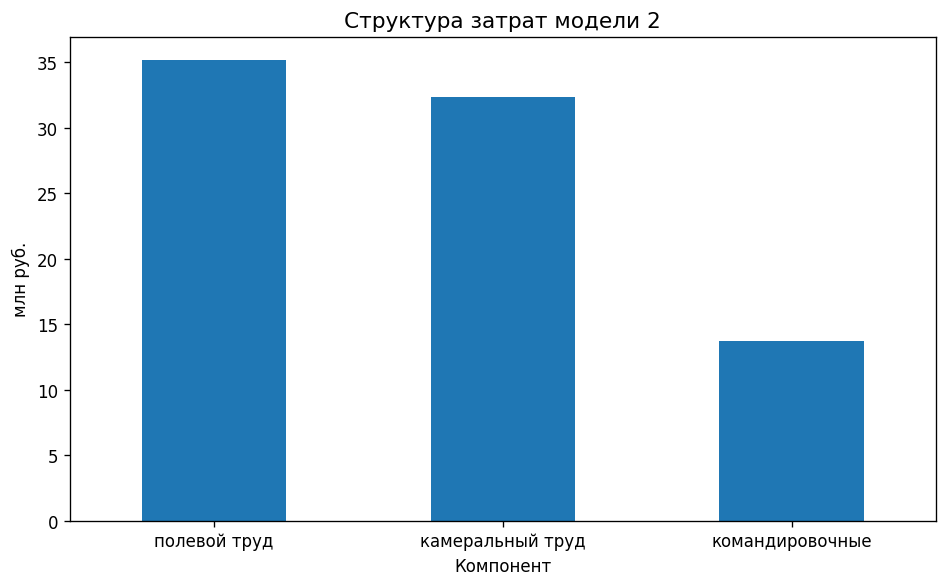

,компонент,руб,млн_руб,доля_%
0,полевой труд,3.515944e+07,35.159443,43.285594
1,камеральный труд,3.233139e+07,32.331388,39.803911
2,командировочные,1.373583e+07,13.735831,16.910495


In [221]:
cost_structure = model2_components[
    model2_components["компонент"] != "итого модель 2"
].copy()

ax = cost_structure.plot(
    x="компонент",
    y="млн_руб",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)

ax.set_title("Структура затрат модели 2")
ax.set_xlabel("Компонент")
ax.set_ylabel("млн руб.")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(cost_structure)

### Расходы модели 2 по лабораториям

,лаборатория,командировок,работ,полевой_труд_руб,командировочные_руб,полевые_часы,камеральные_работы,камеральные_часы,камеральный_труд_руб,итого_руб,итого_млн_руб
3,СЦР ЛОЭОиВ,59,539,1.462693e+07,6.014008e+06,9343.750305,539,1280.449779,2.004446e+06,2.264538e+07,22.645380
1,СЦР ЛНК,28,347,7.610000e+06,2.677379e+06,3513.858693,347,4371.891298,9.468249e+06,1.975563e+07,19.755628
2,СЦР ЛООиТКС,25,260,4.803131e+06,2.174390e+06,2760.386096,260,5128.313946,8.923376e+06,1.590090e+07,15.900896
0,ДОЗиС,21,65,4.155251e+06,1.476320e+06,2008.200147,65,3815.049806,7.893879e+06,1.352545e+07,13.525450
4,СЦР ЛЭХЗ,16,79,3.964136e+06,1.393735e+06,2203.426270,79,2246.393711,4.041438e+06,9.399309e+06,9.399309


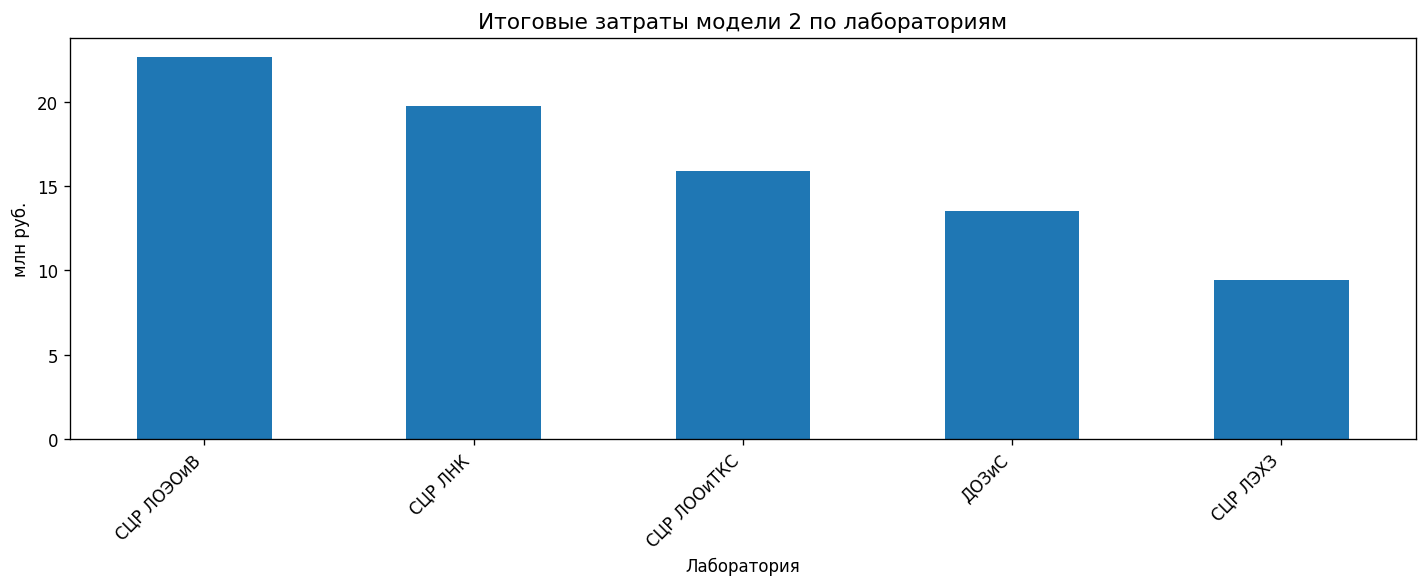

In [222]:
field_cost_by_lab = (
    model2_calendar_trips
    .groupby("лаборатория", as_index=False)
    .agg(
        командировок=("option_id", "count"),
        работ=("work_ids", lambda x: sum(len(v) for v in x)),
        полевой_труд_руб=("труд_полевой_руб", "sum"),
        командировочные_руб=("командировочные_руб", "sum"),
        полевые_часы=("полевые_часы", "sum")
    )
)

cam_cost_by_lab = (
    model2_selected_cam
    .groupby("лаборатория", as_index=False)
    .agg(
        камеральные_работы=("work_id", "count"),
        камеральные_часы=("камеральные_часы", "sum"),
        камеральный_труд_руб=("камеральный_труд_руб", "sum")
    )
)

cost_by_lab = field_cost_by_lab.merge(cam_cost_by_lab, on="лаборатория", how="outer").fillna(0)

cost_by_lab["итого_руб"] = (
    cost_by_lab["полевой_труд_руб"]
    + cost_by_lab["командировочные_руб"]
    + cost_by_lab["камеральный_труд_руб"]
)

cost_by_lab["итого_млн_руб"] = cost_by_lab["итого_руб"] / 1_000_000

display(cost_by_lab.sort_values("итого_руб", ascending=False))

ax = (
    cost_by_lab
    .sort_values("итого_руб", ascending=False)
    .plot(
        x="лаборатория",
        y="итого_млн_руб",
        kind="bar",
        legend=False,
        figsize=(12, 5)
    )
)

ax.set_title("Итоговые затраты модели 2 по лабораториям")
ax.set_xlabel("Лаборатория")
ax.set_ylabel("млн руб.")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Расходы модели 2 по лабораториям

,лаборатория,командировок,работ,полевой_труд_руб,командировочные_руб,полевые_часы,камеральные_работы,камеральные_часы,камеральный_труд_руб,итого_руб,итого_млн_руб
3,СЦР ЛОЭОиВ,59,539,1.462693e+07,6.014008e+06,9343.750305,539,1280.449779,2.004446e+06,2.264538e+07,22.645380
1,СЦР ЛНК,28,347,7.610000e+06,2.677379e+06,3513.858693,347,4371.891298,9.468249e+06,1.975563e+07,19.755628
2,СЦР ЛООиТКС,25,260,4.803131e+06,2.174390e+06,2760.386096,260,5128.313946,8.923376e+06,1.590090e+07,15.900896
0,ДОЗиС,21,65,4.155251e+06,1.476320e+06,2008.200147,65,3815.049806,7.893879e+06,1.352545e+07,13.525450
4,СЦР ЛЭХЗ,16,79,3.964136e+06,1.393735e+06,2203.426270,79,2246.393711,4.041438e+06,9.399309e+06,9.399309


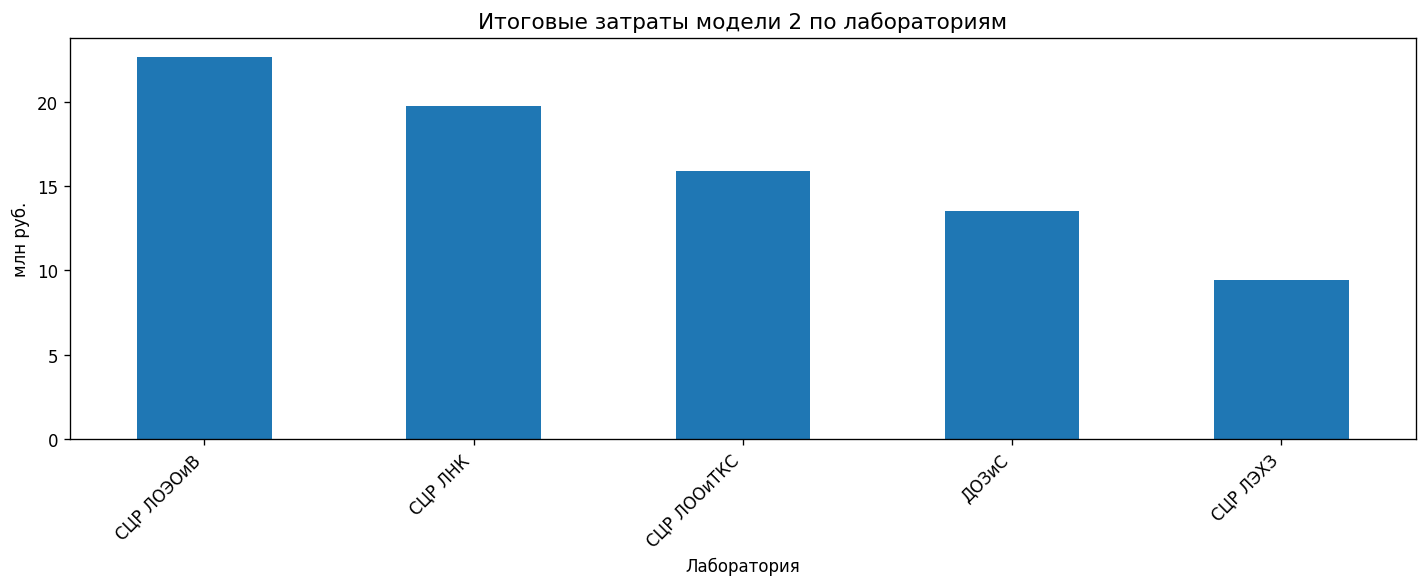

In [223]:
field_cost_by_lab = (
    model2_calendar_trips
    .groupby("лаборатория", as_index=False)
    .agg(
        командировок=("option_id", "count"),
        работ=("work_ids", lambda x: sum(len(v) for v in x)),
        полевой_труд_руб=("труд_полевой_руб", "sum"),
        командировочные_руб=("командировочные_руб", "sum"),
        полевые_часы=("полевые_часы", "sum")
    )
)

cam_cost_by_lab = (
    model2_selected_cam
    .groupby("лаборатория", as_index=False)
    .agg(
        камеральные_работы=("work_id", "count"),
        камеральные_часы=("камеральные_часы", "sum"),
        камеральный_труд_руб=("камеральный_труд_руб", "sum")
    )
)

cost_by_lab = field_cost_by_lab.merge(cam_cost_by_lab, on="лаборатория", how="outer").fillna(0)

cost_by_lab["итого_руб"] = (
    cost_by_lab["полевой_труд_руб"]
    + cost_by_lab["командировочные_руб"]
    + cost_by_lab["камеральный_труд_руб"]
)

cost_by_lab["итого_млн_руб"] = cost_by_lab["итого_руб"] / 1_000_000

display(cost_by_lab.sort_values("итого_руб", ascending=False))

ax = (
    cost_by_lab
    .sort_values("итого_руб", ascending=False)
    .plot(
        x="лаборатория",
        y="итого_млн_руб",
        kind="bar",
        legend=False,
        figsize=(12, 5)
    )
)

ax.set_title("Итоговые затраты модели 2 по лабораториям")
ax.set_xlabel("Лаборатория")
ax.set_ylabel("млн руб.")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Часы по лабораториям: полевая и камеральная нагрузка

,лаборатория,полевые_часы,камеральные_часы,итого_часы
3,СЦР ЛОЭОиВ,9343.750305,1280.449779,10624.200084
2,СЦР ЛООиТКС,2760.386096,5128.313946,7888.700042
1,СЦР ЛНК,3513.858693,4371.891298,7885.749991
0,ДОЗиС,2008.200147,3815.049806,5823.249953
4,СЦР ЛЭХЗ,2203.426270,2246.393711,4449.819981


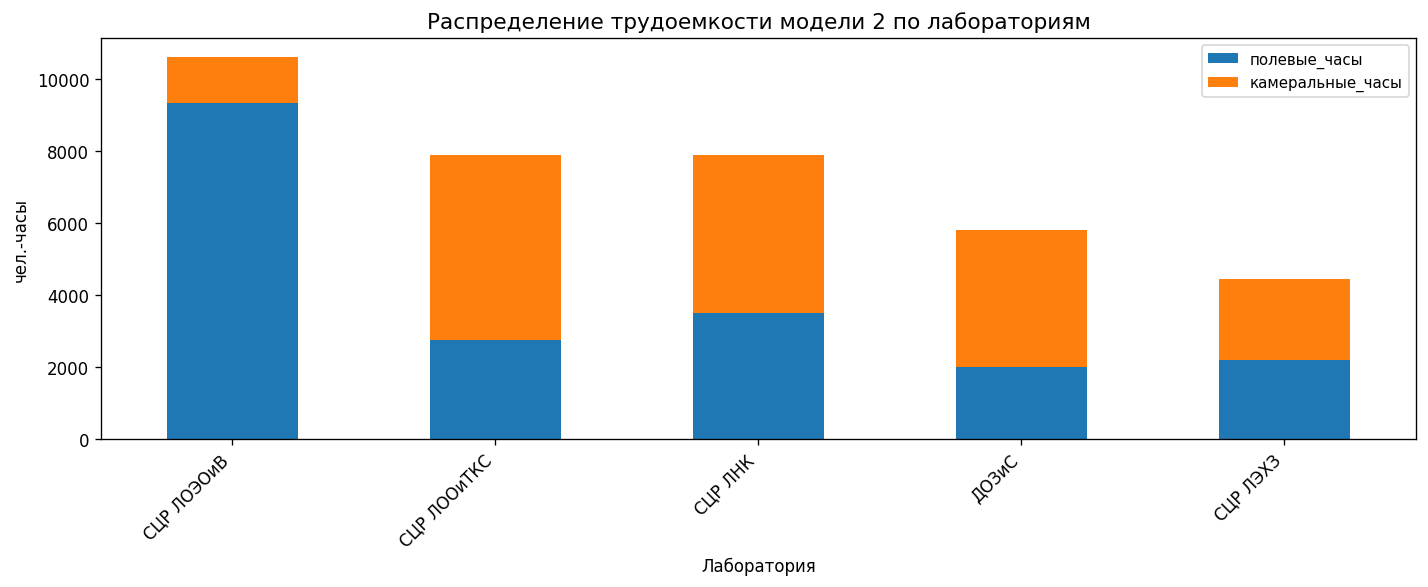

In [224]:
hours_by_lab = cost_by_lab[[
    "лаборатория",
    "полевые_часы",
    "камеральные_часы"
]].copy()

hours_by_lab["итого_часы"] = hours_by_lab["полевые_часы"] + hours_by_lab["камеральные_часы"]

display(hours_by_lab.sort_values("итого_часы", ascending=False))

hours_plot = hours_by_lab.sort_values("итого_часы", ascending=False).set_index("лаборатория")

ax = hours_plot[["полевые_часы", "камеральные_часы"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5)
)

ax.set_title("Распределение трудоемкости модели 2 по лабораториям")
ax.set_xlabel("Лаборатория")
ax.set_ylabel("чел.-часы")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Загрузка по лабораториям и сезонам 

In [225]:
field_hours_lab_season = (
    model2_calendar_trips
    .groupby(["лаборатория", "сезон"], as_index=False)
    .agg(
        командировок=("option_id", "count"),
        работ=("work_ids", lambda x: sum(len(v) for v in x)),
        полевые_часы=("полевые_часы", "sum"),
        командировочные_руб=("командировочные_руб", "sum")
    )
)

cam_hours_lab_season = (
    model2_selected_cam
    .groupby(["лаборатория", "сезон"], as_index=False)
    .agg(
        камеральные_работы=("work_id", "count"),
        камеральные_часы=("камеральные_часы", "sum")
    )
)

load_lab_season = (
    field_hours_lab_season
    .merge(cam_hours_lab_season, on=["лаборатория", "сезон"], how="outer")
    .fillna(0)
)

load_lab_season["итого_часы"] = load_lab_season["полевые_часы"] + load_lab_season["камеральные_часы"]

load_lab_season["фонд_часов"] = load_lab_season.apply(
    lambda r: F.get((r["лаборатория"], r["сезон"]), np.nan),
    axis=1
)

load_lab_season["загрузка_%"] = (
    load_lab_season["итого_часы"] / load_lab_season["фонд_часов"] * 100
)

display(load_lab_season.sort_values(["лаборатория", "сезон"]))

,лаборатория,сезон,командировок,работ,полевые_часы,командировочные_руб,камеральные_работы,камеральные_часы,итого_часы,фонд_часов,загрузка_%
0,ДОЗиС,Весна,5.0,13.0,417.140607,2.913148e+05,4.0,243.832912,660.973519,1812.0,36.477567
1,ДОЗиС,Зима,2.0,3.0,96.263217,4.598577e+04,25.0,1474.877362,1571.140579,1620.0,96.983986
2,ДОЗиС,Лето,5.0,20.0,641.754780,4.552619e+05,17.0,1036.289876,1678.044656,1726.0,97.221591
3,ДОЗиС,Осень,9.0,29.0,853.041543,6.837575e+05,19.0,1060.049656,1913.091199,1922.0,99.536483
4,СЦР ЛНК,Весна,9.0,112.0,1231.403443,9.138373e+05,30.0,436.882377,1668.285820,2264.0,73.687536
5,СЦР ЛНК,Зима,0.0,0.0,0.000000,0.000000e+00,124.0,1665.861103,1665.861103,2023.0,82.346075
6,СЦР ЛНК,Лето,8.0,109.0,966.438441,7.825150e+05,86.0,1187.619463,2154.057904,2156.0,99.909921
7,СЦР ЛНК,Осень,11.0,126.0,1316.016809,9.810263e+05,107.0,1081.528355,2397.545164,2401.0,99.856108
8,СЦР ЛООиТКС,Весна,7.0,77.0,806.060940,6.522065e+05,40.0,720.563894,1526.624834,2264.0,67.430426
9,СЦР ЛООиТКС,Зима,1.0,9.0,77.963279,5.985205e+04,89.0,1736.592938,1814.556217,2023.0,89.696303


/tmp/ipykernel_3376/2193775085.py:17: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  plot_df


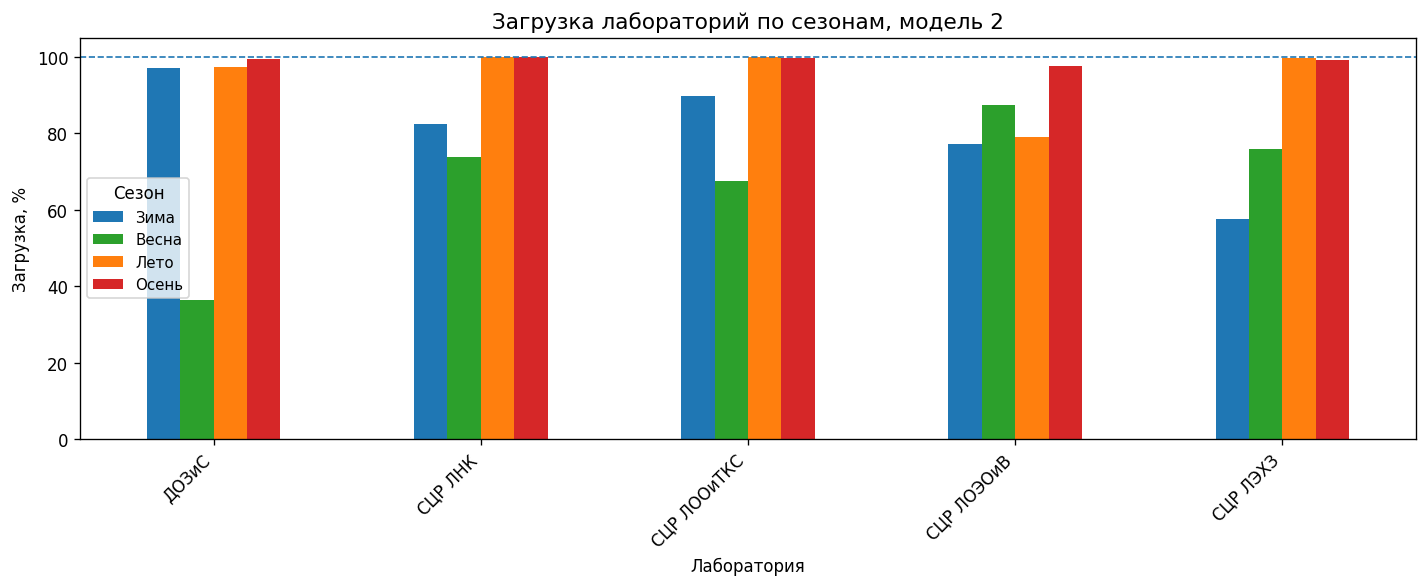

In [226]:
season_order = ["Зима", "Весна", "Лето", "Осень"]
season_colors = {
    "Зима": "tab:blue",
    "Весна": "tab:green",
    "Лето": "tab:orange",
    "Осень": "tab:red"
}

plot_df = load_lab_season.copy()
plot_df["сезон"] = pd.Categorical(
    plot_df["сезон"],
    categories=season_order,
    ordered=True
)

load_pivot = (
    plot_df
    .pivot_table(
        index="лаборатория",
        columns="сезон",
        values="загрузка_%",
        aggfunc="sum"
    )
    .reindex(columns=season_order)
)

ax = load_pivot.plot(
    kind="bar",
    figsize=(12, 5),
    color=[season_colors[s] for s in season_order]
)

ax.set_title("Загрузка лабораторий по сезонам, модель 2")
ax.set_xlabel("Лаборатория")
ax.set_ylabel("Загрузка, %")
ax.axhline(100, linestyle="--", linewidth=1)

plt.xticks(rotation=45, ha="right")
plt.legend(title="Сезон")
plt.tight_layout()
plt.savefig("risunok_13_model2_zagruzka_po_sezonam.png", dpi=300, bbox_inches="tight")
plt.show()

### Дневная загрузка по модели 2

,date,активных_командировок,полевые_часы,доступно_часов,использование_дневного_фонда_%
211,2025-11-13,7,52.327925,56.0,93.442723
123,2025-07-14,22,169.897474,192.0,88.488268
212,2025-11-14,7,49.279106,56.0,87.998404
213,2025-11-17,7,49.279106,56.0,87.998404
214,2025-11-18,7,49.279106,56.0,87.998404
215,2025-11-19,7,49.279106,56.0,87.998404
209,2025-11-11,7,48.388847,56.0,86.408656
222,2025-11-28,6,48.000000,56.0,85.714286
94,2025-05-30,6,48.000000,56.0,85.714286
93,2025-05-29,6,48.000000,56.0,85.714286


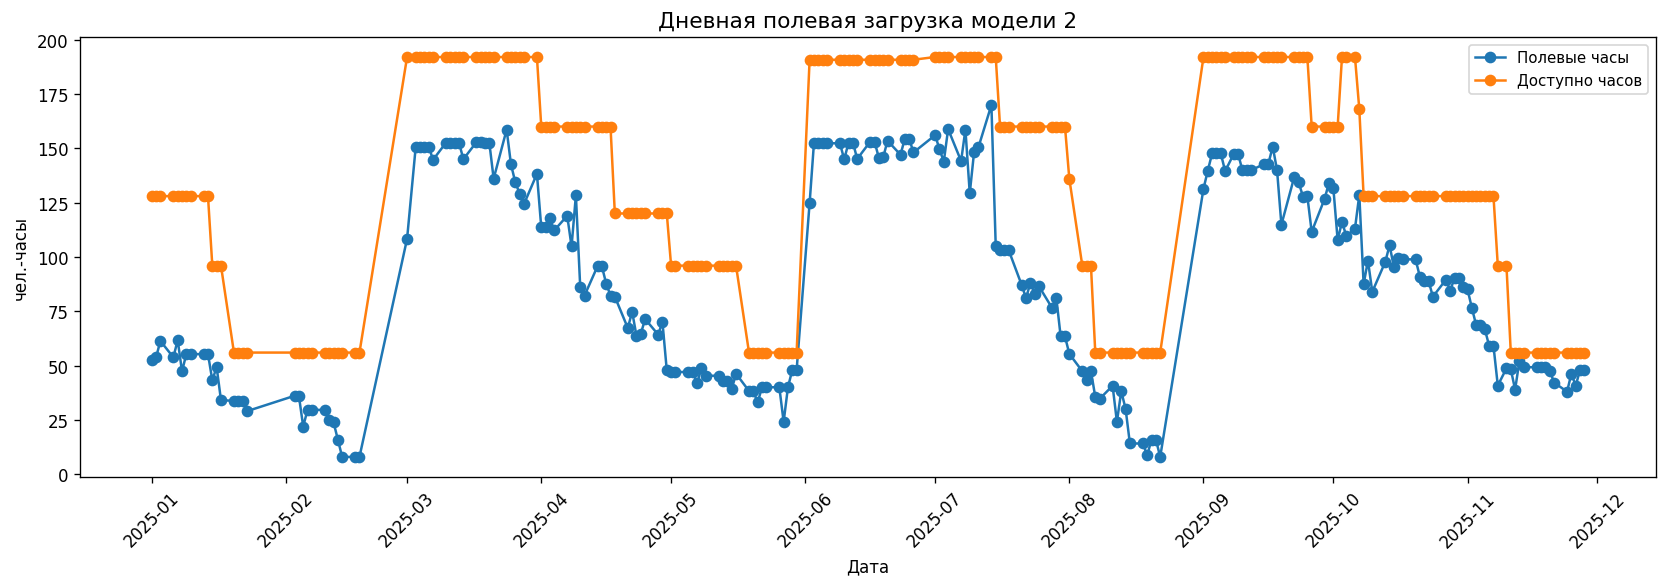

In [227]:
daily_total = (
    model2_daily_load
    .groupby("date", as_index=False)
    .agg(
        активных_командировок=("активных_командировок", "sum"),
        полевые_часы=("полевые_часы", "sum"),
        доступно_часов=("доступно_часов", "sum")
    )
)

daily_total["использование_дневного_фонда_%"] = (
    daily_total["полевые_часы"] / daily_total["доступно_часов"] * 100
)

display(daily_total.sort_values("использование_дневного_фонда_%", ascending=False).head(20))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_total["date"], daily_total["полевые_часы"], marker="o", label="Полевые часы")
ax.plot(daily_total["date"], daily_total["доступно_часов"], marker="o", label="Доступно часов")

ax.set_title("Дневная полевая загрузка модели 2")
ax.set_xlabel("Дата")
ax.set_ylabel("чел.-часы")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Модель 2 использует кандидатные командировки, включая решение модели 1 как стартовый набор, но оптимизация выбора календарных вариантов проводится заново.

# Для ПРИЛОЖЕНИЙ

In [228]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = Path("appendix_outputs")
OUT_DIR.mkdir(exist_ok=True)

BASE_FILE = Path("итог_распределения_работ_по_лабораториям_и_сезонам.xlsx")
MODEL1_FILE = Path("model1_calendarization_manual_calendar.xlsx")
MODEL2_FILE = Path("model2_true_calendar_cp_sat.xlsx")

season_order = ["Зима", "Весна", "Лето", "Осень"]
season_colors = {
    "Зима": "tab:blue",
    "Весна": "tab:green",
    "Лето": "tab:orange",
    "Осень": "tab:red"
}

# Таблицы
base_full = pd.read_excel(BASE_FILE, sheet_name="Полная версия")
m1_summary = pd.read_excel(MODEL1_FILE, sheet_name="итог")
m1_trips = pd.read_excel(MODEL1_FILE, sheet_name="командировки")
m1_daily = pd.read_excel(MODEL1_FILE, sheet_name="дневная_загрузка")
m1_lab_season = pd.read_excel(MODEL1_FILE, sheet_name="загрузка_лаб_сезон")

m2_summary = pd.read_excel(MODEL2_FILE, sheet_name="итог")
m2_components = pd.read_excel(MODEL2_FILE, sheet_name="компоненты")
m2_trips = pd.read_excel(MODEL2_FILE, sheet_name="выбранные_командировки")
m2_cam = pd.read_excel(MODEL2_FILE, sheet_name="камеральные_назначения")
m2_daily = pd.read_excel(MODEL2_FILE, sheet_name="дневная_загрузка")

# Приложение Б: компактная сводка базовой сезонной модели
base_compact_cols = [
    "лаборатория", "сезон", "полевые_группы",
    "число_полевых_работ", "полевые_часы", "полевые_дни",
    "число_камеральных_работ", "камеральные_часы", "всего_часов"
]
base_compact = base_full[base_compact_cols].copy()

# Приложение В: фрагмент календаризации модели 1
m1_trips_fragment_cols = [
    "calendar_trip_id", "лаборатория", "сезон", "филиал", "work_ids",
    "число_работ", "полевые_часы", "полевые_дни",
    "дата_выезда", "дата_начала_поля", "дата_окончания_поля", "дата_возвращения",
    "тип_размещения"
]
m1_trips_fragment = m1_trips[m1_trips_fragment_cols].head(25).copy()

m1_overload = m1_daily[m1_daily["загрузка_%"] > 100 + 1e-9].copy()
m1_overload = m1_overload[
    ["лаборатория", "date", "сезон", "полевые_часы", "камеральные_часы",
     "итого_часы", "доступно_часов", "перегрузка_часов", "загрузка_%"]
].copy()

# Приложение Г: фрагмент модели 2
m2_trips_fragment_cols = [
    "option_id", "source", "лаборатория", "сезон", "филиал", "work_ids",
    "число_работ", "полевые_часы", "полевые_дни",
    "дата_начала_поля", "дата_окончания_поля",
    "труд_полевой_руб", "командировочные_руб",
    "стоимость_поля_и_командировки_руб"
]
m2_trips_fragment = m2_trips[m2_trips_fragment_cols].head(25).copy()

# Загрузка модели 2 по сезонам
m2_field_lab_season = (
    m2_trips
    .groupby(["лаборатория", "сезон"], as_index=False)
    .agg(
        командировок=("option_id", "count"),
        работ=("work_ids", lambda x: sum(len(eval(v)) if isinstance(v, str) and v.startswith("(") else 1 for v in x)),
        полевые_часы=("полевые_часы", "sum"),
        командировочные_руб=("командировочные_руб", "sum")
    )
)

m2_cam_lab_season = (
    m2_cam
    .groupby(["лаборатория", "сезон"], as_index=False)
    .agg(
        камеральные_работы=("work_id", "count"),
        камеральные_часы=("камеральные_часы", "sum")
    )
)

funds = m1_lab_season[["лаборатория", "сезон", "фонд_часов"]].drop_duplicates()

m2_lab_season = (
    m2_field_lab_season
    .merge(m2_cam_lab_season, on=["лаборатория", "сезон"], how="outer")
    .merge(funds, on=["лаборатория", "сезон"], how="left")
    .fillna(0)
)

m2_lab_season["итого_часы"] = m2_lab_season["полевые_часы"] + m2_lab_season["камеральные_часы"]
m2_lab_season["загрузка_%"] = m2_lab_season["итого_часы"] / m2_lab_season["фонд_часов"] * 100

# Округление
for df in [base_compact, m1_trips_fragment, m1_overload, m2_trips_fragment, m2_lab_season, m2_components]:
    for col in df.select_dtypes(include="number").columns:
        df[col] = df[col].round(2)

FileNotFoundError: [Errno 2] No such file or directory: 'итог_распределения_работ_по_лабораториям_и_сезонам.xlsx'

In [211]:
# Excel для приложений
appendix_xlsx = OUT_DIR / "tables_for_appendices.xlsx"

with pd.ExcelWriter(appendix_xlsx, engine="openpyxl") as writer:
    base_compact.to_excel(writer, sheet_name="Б1_база_сводка", index=False)
    m1_trips_fragment.to_excel(writer, sheet_name="В1_календарь_м1_фрагмент", index=False)
    m1_overload.to_excel(writer, sheet_name="В2_перегрузки_м1", index=False)
    m2_trips_fragment.to_excel(writer, sheet_name="Г1_модель2_фрагмент", index=False)
    m2_lab_season.to_excel(writer, sheet_name="Г2_загрузка_модель2", index=False)
    m2_components.to_excel(writer, sheet_name="Г3_затраты_модель2", index=False)

IndexError: At least one sheet must be visible

In [210]:
# Рисунок Б.1: трудоемкость базовой модели по лабораториям
base_lab_hours = (
    base_full
    .groupby("лаборатория", as_index=True)
    .agg(
        полевые_часы=("полевые_часы", "sum"),
        камеральные_часы=("камеральные_часы", "sum")
    )
    .sort_values("полевые_часы", ascending=False)
)

ax = base_lab_hours.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 5),
    color=["tab:blue", "tab:orange"]
)
ax.set_title("Распределение трудоемкости базовой сезонной модели по лабораториям")
ax.set_xlabel("Лаборатория")
ax.set_ylabel("чел.-часы")
plt.xticks(rotation=35, ha="right")
plt.legend(["Полевые часы", "Камеральные часы"])
plt.tight_layout()
plt.savefig(OUT_DIR / "risunok_B1_trudoemkost_bazovaya_model.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'base_full' is not defined

In [209]:
# Рисунок В.1: перегрузка в модели 1
if len(m1_overload) > 0:
    target_lab = m1_overload["лаборатория"].iloc[0]
    min_d = pd.to_datetime(m1_overload["date"]).min() - pd.Timedelta(days=5)
    max_d = pd.to_datetime(m1_overload["date"]).max() + pd.Timedelta(days=5)

    plot_m1 = m1_daily.copy()
    plot_m1["date"] = pd.to_datetime(plot_m1["date"])
    plot_m1 = plot_m1[
        (plot_m1["лаборатория"] == target_lab)
        & (plot_m1["date"] >= min_d)
        & (plot_m1["date"] <= max_d)
    ].copy()

    overload_days = plot_m1[plot_m1["загрузка_%"] > 100 + 1e-9]

    plt.figure(figsize=(11, 4.8))
    plt.plot(plot_m1["date"], plot_m1["загрузка_%"], marker="o", linewidth=1.5)
    plt.axhline(100, linestyle="--", linewidth=1)
    plt.scatter(overload_days["date"], overload_days["загрузка_%"], s=55, zorder=3)
    plt.title(f"Дневная загрузка {target_lab} при календарной детализации базового решения")
    plt.xlabel("Дата")
    plt.ylabel("Загрузка, %")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "risunok_V1_peregruzka_model1.png", dpi=300, bbox_inches="tight")
    plt.show()

NameError: name 'm1_overload' is not defined

In [208]:
# Рисунок Г.1: загрузка по сезонам, модель 2
plot_df = m2_lab_season.copy()
plot_df["сезон"] = pd.Categorical(plot_df["сезон"], categories=season_order, ordered=True)

load_pivot = (
    plot_df
    .pivot_table(index="лаборатория", columns="сезон", values="загрузка_%", aggfunc="sum")
    .reindex(columns=season_order)
)

ax = load_pivot.plot(
    kind="bar",
    figsize=(12, 5),
    color=[season_colors[s] for s in season_order]
)
ax.set_title("Загрузка лабораторий по сезонам, модель 2")
ax.set_xlabel("Лаборатория")
ax.set_ylabel("Загрузка, %")
ax.axhline(100, linestyle="--", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Сезон")
plt.tight_layout()
plt.savefig(OUT_DIR / "risunok_G1_zagruzka_model2_po_sezonam.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'm2_lab_season' is not defined

In [205]:
# Рисунок Г.2: максимальная дневная полевая загрузка модели 2
m2_daily_plot = m2_daily.copy()
m2_daily_plot["загрузка_%"] = m2_daily_plot["полевые_часы"] / m2_daily_plot["доступно_часов"] * 100

m2_max_daily = (
    m2_daily_plot
    .groupby("лаборатория", as_index=True)
    .agg(максимальная_загрузка=("загрузка_%", "max"))
    .sort_values("максимальная_загрузка", ascending=False)
)

plt.figure(figsize=(10, 4.8))
plt.bar(m2_max_daily.index, m2_max_daily["максимальная_загрузка"])
plt.axhline(100, linestyle="--", linewidth=1)
plt.title("Максимальная дневная полевая загрузка лабораторий, модель 2")
plt.xlabel("Лаборатория")
plt.ylabel("Загрузка, %")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "risunok_G2_max_daily_load_model2.png", dpi=300, bbox_inches="tight")
plt.show()

print("Готово. Файлы сохранены в папку:", OUT_DIR.resolve())
print("Excel с таблицами:", appendix_xlsx)

NameError: name 'm2_daily' is not defined

In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

season_order = ['Зима', 'Весна', 'Лето', 'Осень']
season_colors = {
    'Зима': '#4F81BD',
    'Весна': '#9BBB59',
    'Лето': '#F79646',
    'Осень': '#C0504D'
}

def plot_season_load_horizontal(df, title, save_path=None):
    temp = df.copy()
    temp['сезон'] = pd.Categorical(temp['сезон'], categories=season_order, ordered=True)

    pivot = (
        temp.pivot_table(
            index='лаборатория',
            columns='сезон',
            values='загрузка_%',
            aggfunc='sum'
        )
        .reindex(columns=season_order)
        .fillna(0)
    )

    labs = pivot.index.tolist()
    y = np.arange(len(labs))
    h = 0.18
    offsets = [-1.5*h, -0.5*h, 0.5*h, 1.5*h]

    fig, ax = plt.subplots(figsize=(11, 6))

    for season, offset in zip(season_order, offsets):
        ax.barh(
            y + offset,
            pivot[season].values,
            height=h,
            color=season_colors[season],
            label=season
        )

    ax.axvline(100, color='gray', linestyle='--', linewidth=1.2)
    ax.set_yticks(y)
    ax.set_yticklabels(labs, fontsize=11)
    ax.set_xlabel('Загрузка, % от фонда времени', fontsize=12)
    ax.set_ylabel('Лаборатория', fontsize=12)
    ax.set_title(title, fontsize=15, pad=14)

    ax.grid(axis='x', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.legend(
        title='Сезон',
        ncol=4,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.12),
        frameon=False
    )

    max_val = np.nanmax(pivot.values)
    ax.set_xlim(0, max(110, np.ceil(max_val / 10) * 10))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

база

In [199]:
base_plot = base_full.copy()

if 'загрузка_%' not in base_plot.columns:
    fund_df = m1_lab_season[['лаборатория', 'сезон', 'фонд_часов']].drop_duplicates()
    base_plot = base_plot.merge(fund_df, on=['лаборатория', 'сезон'], how='left')
    base_plot['загрузка_%'] = base_plot['всего_часов'] / base_plot['фонд_часов'] * 100

plot_season_load_horizontal(
    base_plot[['лаборатория', 'сезон', 'загрузка_%']],
    'Загрузка лабораторий по сезонам в базовой сезонной модели',
    save_path='risunok_B1_base_season_load.png'
)

NameError: name 'base_full' is not defined

In [200]:
plot_season_load_horizontal(
    m2_lab_season[['лаборатория', 'сезон', 'загрузка_%']],
    'Загрузка лабораторий по сезонам, модель 2',
    save_path='risunok_G1_model2_season_load.png'
)

NameError: name 'm2_lab_season' is not defined

In [201]:
m1_overload = m1_daily.copy()
m1_overload = m1_overload[m1_overload['загрузка_%'] > 100].copy()

m1_overload['превышение_пп'] = m1_overload['загрузка_%'] - 100

overload_summary = (
    m1_overload
    .groupby('лаборатория', as_index=False)
    .agg(
        дней_с_перегрузкой=('date', 'nunique'),
        максимальная_загрузка=('загрузка_%', 'max'),
        максимальное_превышение_пп=('превышение_пп', 'max')
    )
    .sort_values('дней_с_перегрузкой', ascending=True)
)

overload_summary

NameError: name 'm1_daily' is not defined

In [202]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = Path("appendix_outputs")
OUT_DIR.mkdir(exist_ok=True)

season_order = ["Зима", "Весна", "Лето", "Осень"]
season_colors = {
    "Зима": "#4F81BD",
    "Весна": "#9BBB59",
    "Лето": "#F79646",
    "Осень": "#C0504D"
}

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 120
})

def plot_season_load_horizontal(df, title, save_path):
    temp = df[["лаборатория", "сезон", "загрузка_%"]].copy()
    temp["сезон"] = pd.Categorical(temp["сезон"], categories=season_order, ordered=True)

    pivot = (
        temp
        .pivot_table(
            index="лаборатория",
            columns="сезон",
            values="загрузка_%",
            aggfunc="sum"
        )
        .reindex(columns=season_order)
        .fillna(0)
    )

    pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]

    labs = pivot.index.tolist()
    y = np.arange(len(labs))
    bar_h = 0.16
    offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * bar_h

    fig, ax = plt.subplots(figsize=(10.8, 5.2))

    for season, offset in zip(season_order, offsets):
        ax.barh(
            y + offset,
            pivot[season].values,
            height=bar_h,
            color=season_colors[season],
            label=season
        )

    ax.axvline(100, color="#555555", linestyle="--", linewidth=1)
    ax.text(100.7, len(labs) - 0.35, "100%", fontsize=9, color="#555555")

    ax.set_yticks(y)
    ax.set_yticklabels(labs)
    ax.set_xlabel("Загрузка, % от фонда времени")
    ax.set_ylabel("Лаборатория")
    ax.set_title(title, pad=14)

    ax.set_xlim(0, 110)
    ax.grid(axis="x", alpha=0.22)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        title="Сезон",
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False
    )

    plt.tight_layout()
    plt.savefig(OUT_DIR / save_path, dpi=300, bbox_inches="tight")
    plt.show()

In [203]:
base_plot = base_full.copy()

if "загрузка_%" not in base_plot.columns:
    funds = m1_lab_season[["лаборатория", "сезон", "фонд_часов"]].drop_duplicates()
    base_plot = base_plot.merge(funds, on=["лаборатория", "сезон"], how="left")
    base_plot["загрузка_%"] = base_plot["всего_часов"] / base_plot["фонд_часов"] * 100

plot_season_load_horizontal(
    base_plot,
    "Загрузка лабораторий по сезонам в базовой сезонной модели",
    "risunok_B1_base_season_load_horizontal.png"
)

NameError: name 'base_full' is not defined

In [204]:
plot_season_load_horizontal(
    m2_lab_season,
    "Загрузка лабораторий по сезонам в модели 2",
    "risunok_G1_model2_season_load_horizontal.png"
)

NameError: name 'm2_lab_season' is not defined